# Composer Classification using Deep Learning

## University of San Diego – MS in Applied Artificial Intelligence
## Deep Learning Final Project

This notebook implements a complete deep learning pipeline to classify the composer of classical music pieces using MIDI files.

In [1]:
# Import necessary libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add the project root to Python path for proper imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import project modules
from src.utils.config import *
from src.utils.config import ensure_directories
from src.utils.helpers import set_random_seed, plot_class_distribution
from src.preprocessing import MIDILoader, load_midi_dataset, clean_dataset, split_dataset
from src.datasets import prepare_lstm_dataset, prepare_cnn_dataset
from src.models import create_lstm_model, create_cnn_model
from src.training import train_lstm_model, train_cnn_model
from src.evaluation import ModelEvaluator, ModelVisualizer

# Create output directories and set random seed
ensure_directories()
set_random_seed()

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load MIDI dataset and extract metadata
print("Loading MIDI dataset...")
metadata, stats = load_midi_dataset(RAW_DATA_DIR, COMPOSERS, save_metadata=True)

print("\nDataset Statistics:")
print(f"Total files: {stats['total_files']}")
print(f"Valid files: {stats['valid_files']}")
print(f"Invalid files: {stats['invalid_files']}")

print("\nFiles per composer:")
for composer, composer_stats in stats['composers'].items():
    print(f"  {composer}: {composer_stats['total']} files ({composer_stats['valid']} valid)")

Loading MIDI dataset...
Found 131 MIDI files for Bach


Loading Bach: 100%|██████████| 131/131 [00:03<00:00, 33.34it/s]


Found 134 MIDI files for Beethoven


Loading Beethoven: 100%|██████████| 134/134 [00:06<00:00, 19.69it/s]


Found 136 MIDI files for Chopin


Loading Chopin: 100%|██████████| 136/136 [00:04<00:00, 33.62it/s]


Found 90 MIDI files for Mozart


Loading Mozart: 100%|██████████| 90/90 [00:03<00:00, 28.85it/s]

Saved metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/metadata.csv

Dataset Statistics:
Total files: 490
Valid files: 490
Invalid files: 0

Files per composer:
  Bach: 131 files (131 valid)
  Beethoven: 133 files (133 valid)
  Chopin: 136 files (136 valid)
  Mozart: 90 files (90 valid)


In [3]:
# TODO: Delete this cell (duplicate of cell above)

In [4]:
# Load metadata from CSV
metadata_df = pd.read_csv(METADATA_FILE)
print(f"Loaded metadata with {len(metadata_df)} entries")
metadata_df.head()

Loaded metadata with 490 entries


,filename,filepath,composer,label,duration,num_notes,tempo,num_instruments,valid
0,Bwv0997 Partita for Lute 1mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,166.000000,977,80.000000,2,True
1,Bwv0535 Prelude and Fugue.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,412.770389,3157,80.000000,3,True
2,Bwv0806 English Suite n1 05mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,120.250096,1050,143.999885,2,True
3,Bwv0998 Prelude Fugue Allegro for Lute 3mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,93.000000,748,100.000000,3,True
4,Jesu Joy of Man Desiring.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,199.410065,2693,65.000065,11,True


Class Distribution:
Saved class distribution plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Overall_Class_Distribution.png


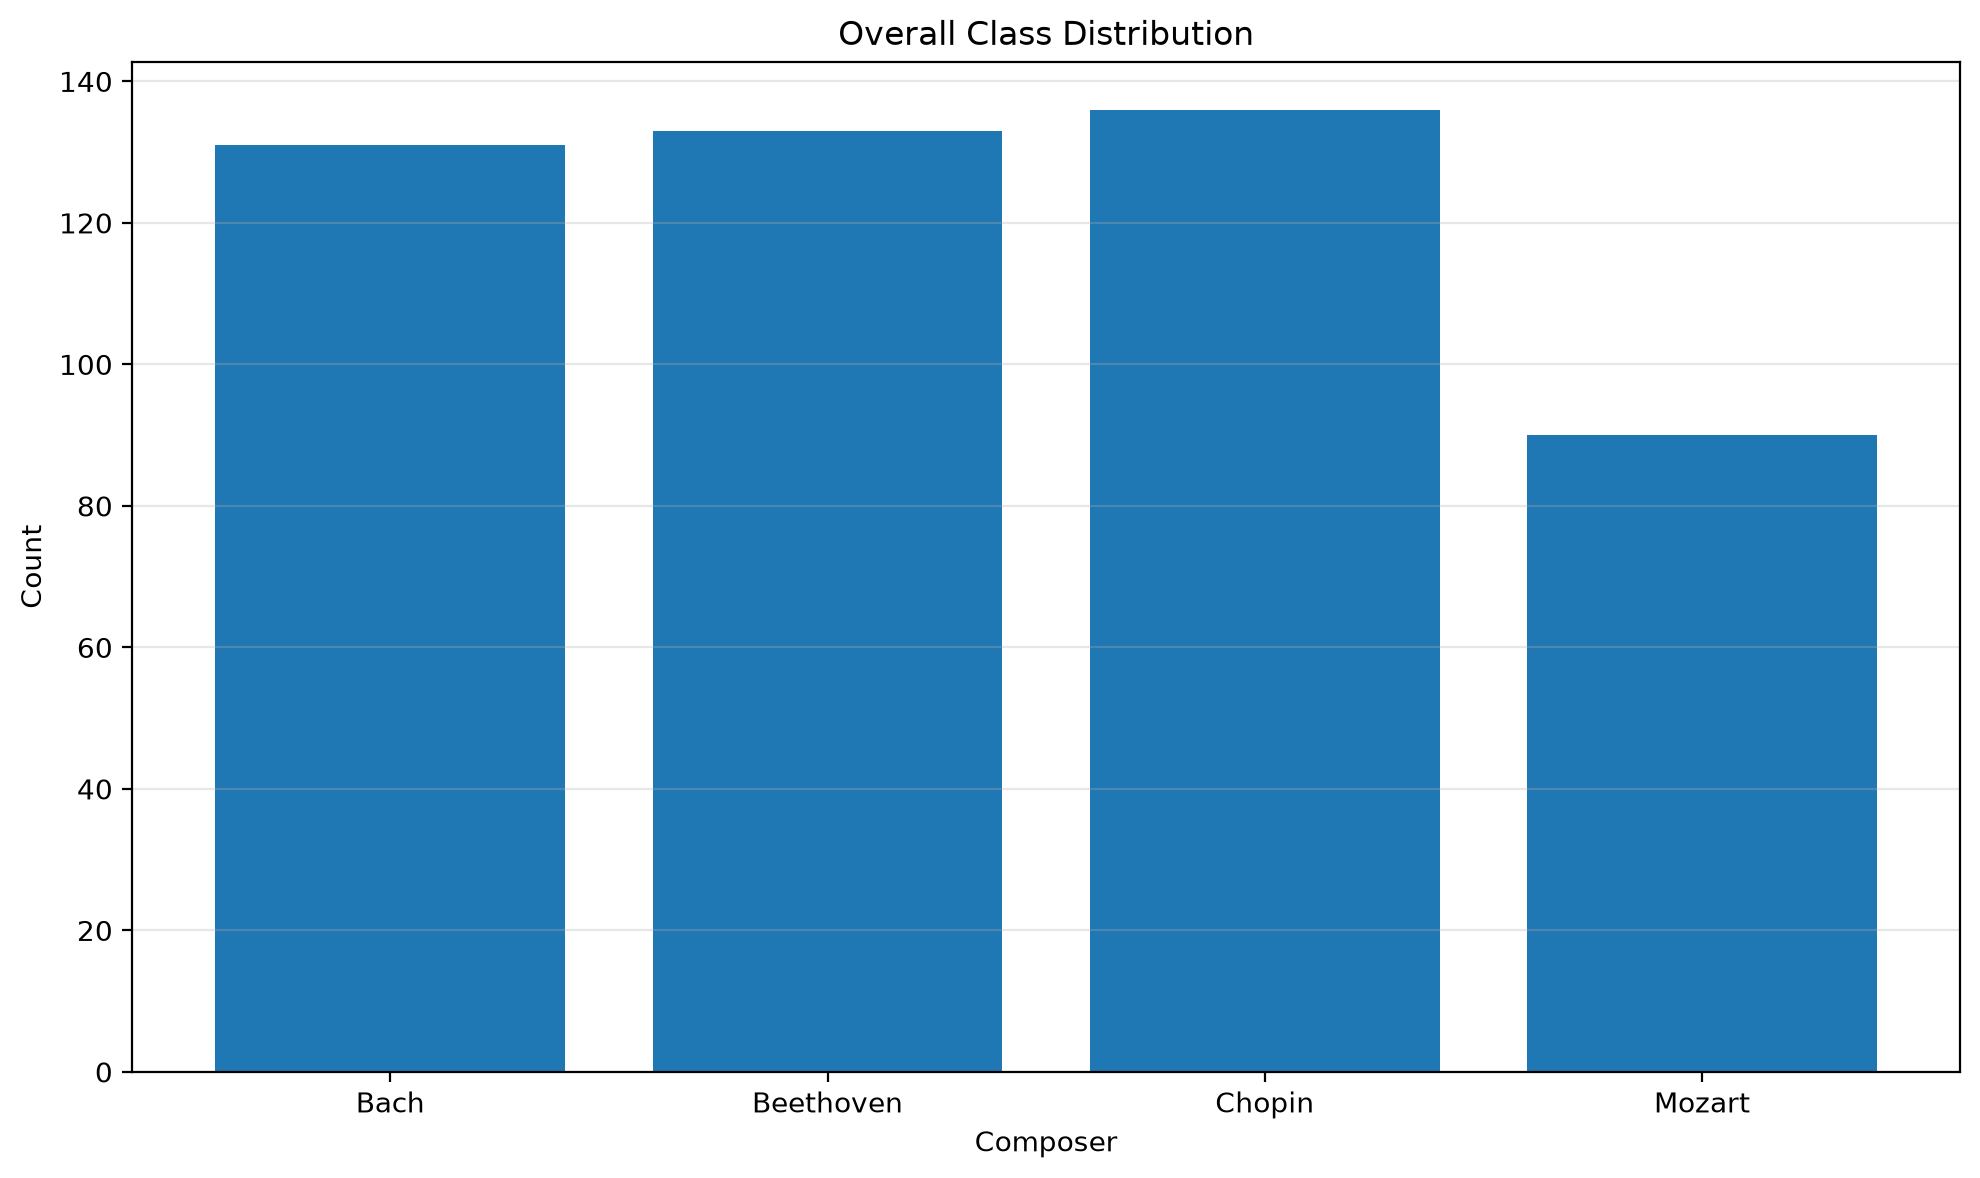

In [5]:
# Exploratory Data Analysis
print("Class Distribution:")
plot_class_distribution(metadata_df['label'].values, COMPOSERS, "Overall Class Distribution")

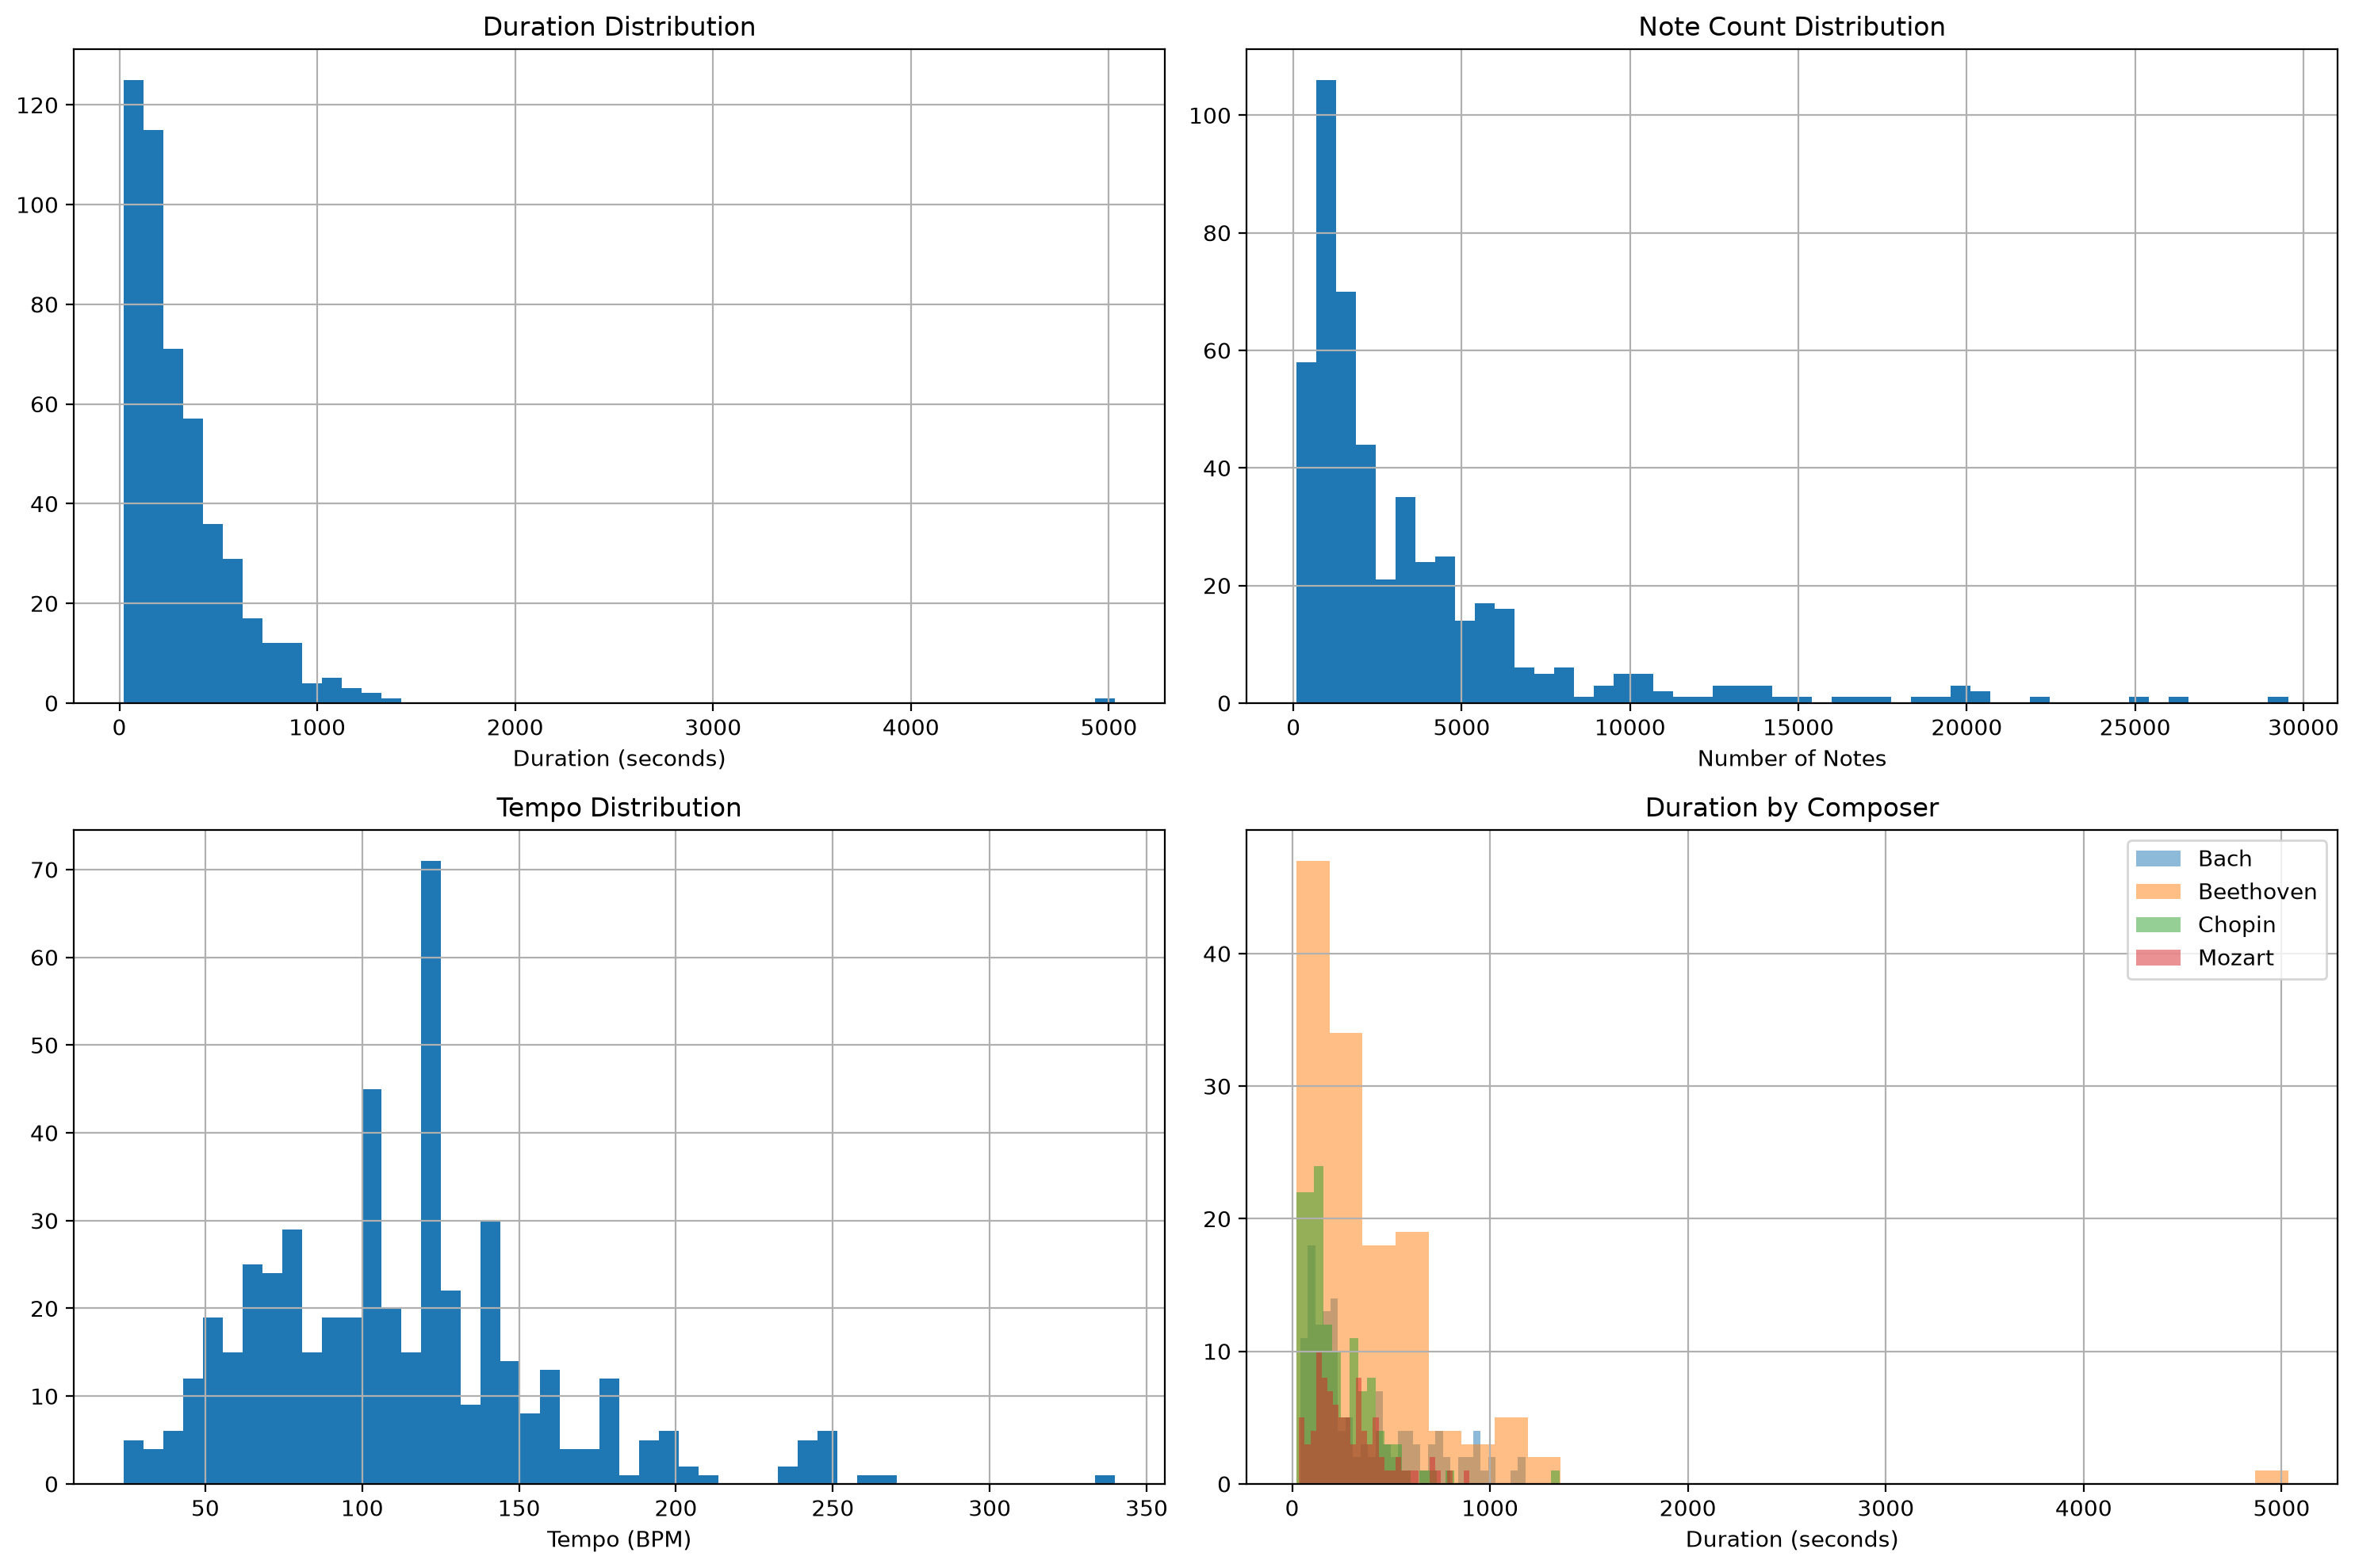

In [6]:
# Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Duration distribution
metadata_df['duration'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Duration Distribution')
axes[0,0].set_xlabel('Duration (seconds)')

# Note count distribution
metadata_df['num_notes'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Note Count Distribution')
axes[0,1].set_xlabel('Number of Notes')

# Tempo distribution
metadata_df['tempo'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Tempo Distribution')
axes[1,0].set_xlabel('Tempo (BPM)')

# Duration by composer
for composer in COMPOSERS:
    composer_data = metadata_df[metadata_df['composer'] == composer]['duration']
    composer_data.hist(bins=30, alpha=0.5, label=composer, ax=axes[1,1])
axes[1,1].set_title('Duration by Composer')
axes[1,1].set_xlabel('Duration (seconds)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_distributions.png', dpi=FIGURE_DPI)
plt.show()

## 3. Data Preprocessing and Cleaning

In [7]:
# Clean dataset
print("Cleaning dataset...")
cleaned_df = clean_dataset(
    metadata_path=METADATA_FILE,
    min_notes=MIN_NOTES,
    min_duration=1.0,
    max_duration=600.0,
    balance=True,
    balance_method='undersample',
    output_path=INTERIM_DATA_DIR / 'cleaned_metadata.csv'
)

print(f"\nCleaned dataset: {len(cleaned_df)} files")

Cleaning dataset...
Starting dataset cleaning...
Original dataset: 490 files
Filtered 0 files with < 10 notes
Retained 490 valid files
Filtered 65 files with duration outside [1.0, 600.0] seconds
Retained 425 valid files
Filtered 0 files from non-specified composers
Retained 425 files from specified composers
Removed 0 duplicate files
Retained 425 unique files


Validating files: 100%|██████████| 425/425 [00:00<00:00, 42946.47it/s]

Found 0 missing files
Retained 425 existing files
Balanced dataset: 336 total files
Samples per composer:
composer
Bach         84
Beethoven    84
Chopin       84
Mozart       84
Name: count, dtype: int64

Cleaning Report:
Original files: 490
Valid files: 336
Invalid files: 65
Files per composer:
  Bach: 84
  Beethoven: 84
  Chopin: 84
  Mozart: 84
Saved cleaned metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/cleaned_metadata.csv

Cleaned dataset: 336 files


In [8]:
# Split dataset into train/val/test
print("Splitting dataset...")
train_df, val_df, test_df = split_dataset(
    cleaned_df,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
    stratified=True,
    output_dir=INTERIM_DATA_DIR
)

print(f"Training set: {len(train_df)} files")
print(f"Validation set: {len(val_df)} files")
print(f"Test set: {len(test_df)} files")

Splitting dataset...

Dataset Split Statistics:

Training Set:
  Total: 268 files
  Percentage: 79.8%
  Composers:
    Bach: 67 (25.0%)
    Beethoven: 67 (25.0%)
    Chopin: 67 (25.0%)
    Mozart: 67 (25.0%)

Validation Set:
  Total: 34 files
  Percentage: 10.1%
  Composers:
    Bach: 8 (23.5%)
    Beethoven: 9 (26.5%)
    Chopin: 8 (23.5%)
    Mozart: 9 (26.5%)

Test Set:
  Total: 34 files
  Percentage: 10.1%
  Composers:
    Bach: 9 (26.5%)
    Beethoven: 8 (23.5%)
    Chopin: 9 (26.5%)
    Mozart: 8 (23.5%)
Saved training metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/train_metadata.csv
Saved validation metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/val_metadata.csv
Saved test metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/

## 4. Feature Extraction and Dataset Preparation

In [9]:
# Prepare LSTM dataset
print("Preparing LSTM dataset...")
X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, X_test_lstm, y_test_lstm = prepare_lstm_dataset(
    train_df, val_df, test_df,
    feature_type='combined',
    sequence_length=SEQUENCE_LENGTH,
    normalize=True,
    save_path=LSTM_FEATURES_FILE
)

print(f"LSTM training data shape: {X_train_lstm.shape}")
print(f"LSTM validation data shape: {X_val_lstm.shape}")
print(f"LSTM test data shape: {X_test_lstm.shape}")

Preparing LSTM dataset...
Loading training set...
Loading 268 MIDI files for LSTM dataset...


100%|██████████| 268/268 [00:05<00:00, 46.01it/s]


Loaded 268 samples successfully
Feature shape: (268, 500, 3)
Labels shape: (268,)
Loading validation set...
Loading 34 MIDI files for LSTM dataset...


100%|██████████| 34/34 [00:00<00:00, 46.14it/s]


Loaded 34 samples successfully
Feature shape: (34, 500, 3)
Labels shape: (34,)
Loading test set...
Loading 34 MIDI files for LSTM dataset...


100%|██████████| 34/34 [00:01<00:00, 33.53it/s]

Loaded 34 samples successfully
Feature shape: (34, 500, 3)
Labels shape: (34,)
Saved LSTM dataset to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/features/lstm_features.npz
LSTM training data shape: (268, 500, 3)
LSTM validation data shape: (34, 500, 3)
LSTM test data shape: (34, 500, 3)


In [10]:
# Prepare CNN dataset
print("Preparing CNN dataset...")
X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn, X_test_cnn, y_test_cnn = prepare_cnn_dataset(
    train_df, val_df, test_df,
    roll_type='velocity',
    time_steps=MAX_TIME_STEPS,
    pitch_range=PITCH_RANGE,
    fps=20.0,
    save_path=CNN_FEATURES_FILE
)

print(f"CNN training data shape: {X_train_cnn.shape}")
print(f"CNN validation data shape: {X_val_cnn.shape}")
print(f"CNN test data shape: {X_test_cnn.shape}")

Preparing CNN dataset...
Loading training set...
Loading 268 MIDI files for CNN dataset...


100%|██████████| 268/268 [00:07<00:00, 34.56it/s]


Loaded 268 samples successfully
Feature shape: (268, 128, 1000)
Labels shape: (268,)
Loading validation set...
Loading 34 MIDI files for CNN dataset...


100%|██████████| 34/34 [00:00<00:00, 39.38it/s]


Loaded 34 samples successfully
Feature shape: (34, 128, 1000)
Labels shape: (34,)
Loading test set...
Loading 34 MIDI files for CNN dataset...


100%|██████████| 34/34 [00:01<00:00, 27.29it/s]


Loaded 34 samples successfully
Feature shape: (34, 128, 1000)
Labels shape: (34,)
Saved CNN dataset to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/features/cnn_features.npz
CNN training data shape: (268, 128, 1000, 1)
CNN validation data shape: (34, 128, 1000, 1)
CNN test data shape: (34, 128, 1000, 1)


## 5. LSTM Model Training

In [11]:
# Train LSTM model (using default hyperparameters — will be retrained with tuned params later)
print("Training LSTM model...")
lstm_input_shape = X_train_lstm.shape[1:]  # (sequence_length, num_features)

lstm_summary, lstm_metrics = train_lstm_model(
    X_train_lstm, y_train_lstm,
    X_val_lstm, y_val_lstm,
    X_test_lstm, y_test_lstm,
    input_shape=lstm_input_shape,
    num_classes=NUM_CLASSES,
    model_type='standard',
    batch_size=LSTM_BATCH_SIZE,
    epochs=LSTM_EPOCHS
)

print("\nLSTM Training Summary:")
for key, value in lstm_summary.items():
    print(f"  {key}: {value}")

Training LSTM model...


Model: "LSTM_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 256)       │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,964 (3.15 MB)

 Trainable params: 824,964 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Training LSTM model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2910 - loss: 1.3766
Epoch 1: val_accuracy improved from None to 0.35294, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2910 - loss: 1.3766 - val_accuracy: 0.3529 - val_loss: 1.3166 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.3545 - loss: 1.3731
Epoch 2: val_accuracy did not improve from 0.35294
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3545 - loss: 1.3731 - val_accuracy: 0.3529 - val_loss: 1.2695 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.3209 - loss: 1.3131
Epoch 3: val_accuracy improved from 0.35294 to 0.50000, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 3: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 939ms/step - accuracy: 0.3209 - loss: 1.3131 - val_accuracy: 0.5000 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.3918 - loss: 1.2731
Epoch 4: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 928ms/step - accuracy: 0.3918 - loss: 1.2731 - val_accuracy: 0.3529 - val_loss: 1.3068 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - accuracy: 0.4179 - loss: 1.2542
Epoch 5: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4179 - loss: 1.2542 - val_accuracy: 0.4118 - val_loss: 1.2611 - learning_rate: 0.0010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4179 - loss: 1.2288
Epoch 6: val_accuracy did not improve

Training completed in 2m 2s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step
Test Loss: 1.2824
Test Accuracy: 0.4118
Precision: 0.4201
Recall: 0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_final.h5

LSTM Training Summary:
  epochs_trained: 13
  final_train_loss: 1.1875343322753906
  final_train_accuracy: 0.5111940503120422
  final_val_loss: 1.376662015914917
  final_val_accuracy: 0.44117647409439087
  best_val_accuracy: 0.5
  best_val_loss: 1.2610507011413574
  training_time: 122.70661306381226
  parameters: 824964


## 6. CNN Model Training

In [12]:
# Train CNN model
print("Training CNN model...")
cnn_input_shape = X_train_cnn.shape[1:]  # (pitch_range, time_steps, channels)

cnn_summary, cnn_metrics = train_cnn_model(
    X_train_cnn, y_train_cnn,
    X_val_cnn, y_val_cnn,
    X_test_cnn, y_test_cnn,
    input_shape=cnn_input_shape,
    num_classes=NUM_CLASSES,
    model_type='standard',
    batch_size=CNN_BATCH_SIZE,
    epochs=CNN_EPOCHS
)

print("\nCNN Training Summary:")
for key, value in cnn_summary.items():
    print(f"  {key}: {value}")

Training CNN model...


Model: "CNN_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 1000, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 1000, 64)  │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1000, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 500, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 500, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 250, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 250, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,140 (1.93 MB)

 Trainable params: 505,220 (1.93 MB)

 Non-trainable params: 1,920 (7.50 KB)

Training CNN model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3545 - loss: 1.6989
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.3545 - loss: 1.6989 - val_accuracy: 0.2353 - val_loss: 1.3583 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4739 - loss: 1.3284
Epoch 2: val_accuracy improved from 0.23529 to 0.44118, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 2: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.4739 - loss: 1.3284 - val_accuracy: 0.4412 - val_loss: 1.3591 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5410 - loss: 1.1440
Epoch 3: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5410 - loss: 1.1440 - val_accuracy: 0.2647 - val_loss: 1.4202 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5784 - loss: 1.0311
Epoch 4: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5784 - loss: 1.0311 - val_accuracy: 0.2647 - val_loss: 1.6281 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6455 - loss: 0.9459
Epoch 5: val_accuracy did not improve from 0.44

Training completed in 4m 27s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
Test Loss: 1.3618
Test Accuracy: 0.3824
Precision: 0.2224
Recall: 0.3824
F1 Score (weighted): 0.2611
F1 Score (macro):    0.2601
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_final.h5

CNN Training Summary:
  epochs_trained: 12
  final_train_loss: 0.6177985668182373
  final_train_accuracy: 0.7686567306518555
  final_val_loss: 5.281357765197754
  final_val_accuracy: 0.2647058963775635
  best_val_accuracy: 0.44117647409439087
  best_val_loss: 1.358283281326294
  training_time: 267.96794605255127
  parameters: 505220


## 7. Model Evaluation

In [13]:
# Load trained models and make predictions
from tensorflow import keras

# Load LSTM model
lstm_model = keras.models.load_model(BEST_LSTM_MODEL)
lstm_pred_proba = lstm_model.predict(X_test_lstm)
lstm_pred = np.argmax(lstm_pred_proba, axis=1)

# Load CNN model
cnn_model = keras.models.load_model(BEST_CNN_MODEL)
cnn_pred_proba = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_pred_proba, axis=1)

print("Predictions generated successfully!")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x32cfa2660> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Predictions generated successfully!


LSTM Model Evaluation:

EVALUATION METRICS
Accuracy:  0.4118
Precision: 0.4201
Recall:    0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
ROC-AUC:   0.6836

Per-Class Metrics:
--------------------------------------------------
Bach:
  Precision: 0.6667
  Recall:    0.4444
  F1 Score:  0.5333
Beethoven:
  Precision: 0.2727
  Recall:    0.3750
  F1 Score:  0.3158
Chopin:
  Precision: 0.5000
  Recall:    0.6667
  F1 Score:  0.5714
Mozart:
  Precision: 0.2000
  Recall:    0.1250
  F1 Score:  0.1538

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        Bach       0.67      0.44      0.53         9
   Beethoven       0.27      0.38      0.32         8
      Chopin       0.50      0.67      0.57         9
      Mozart       0.20      0.12      0.15         8

    accuracy                           0.41        34
   macro avg       0.41      0.40      0.39        34
weighted avg       0.42      0

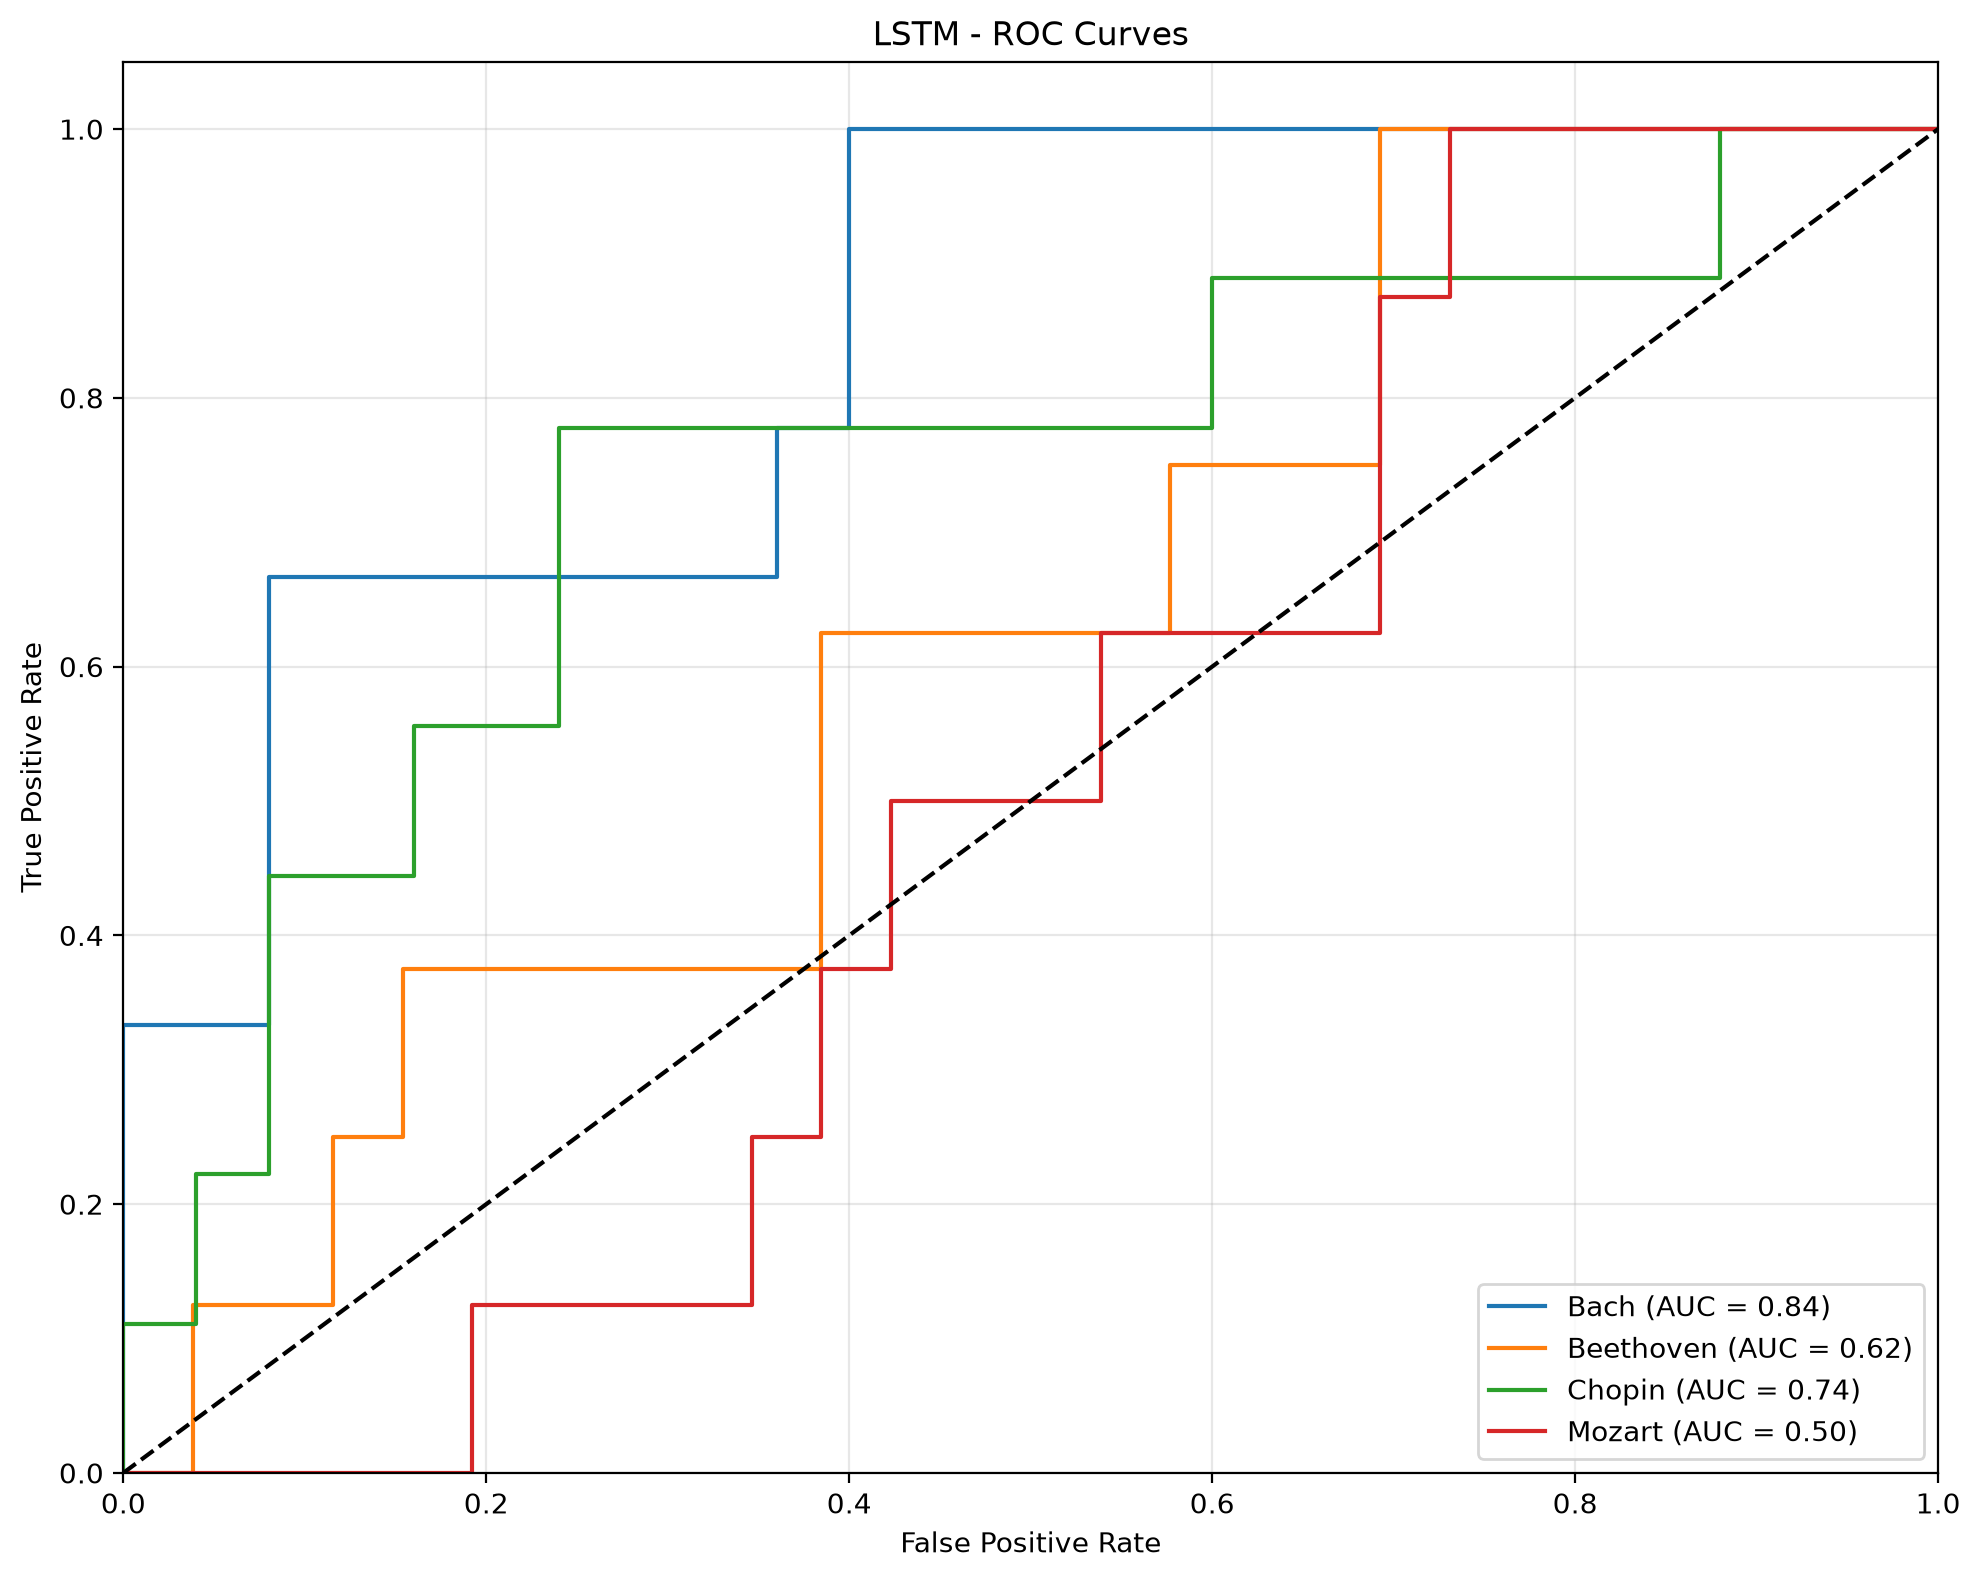

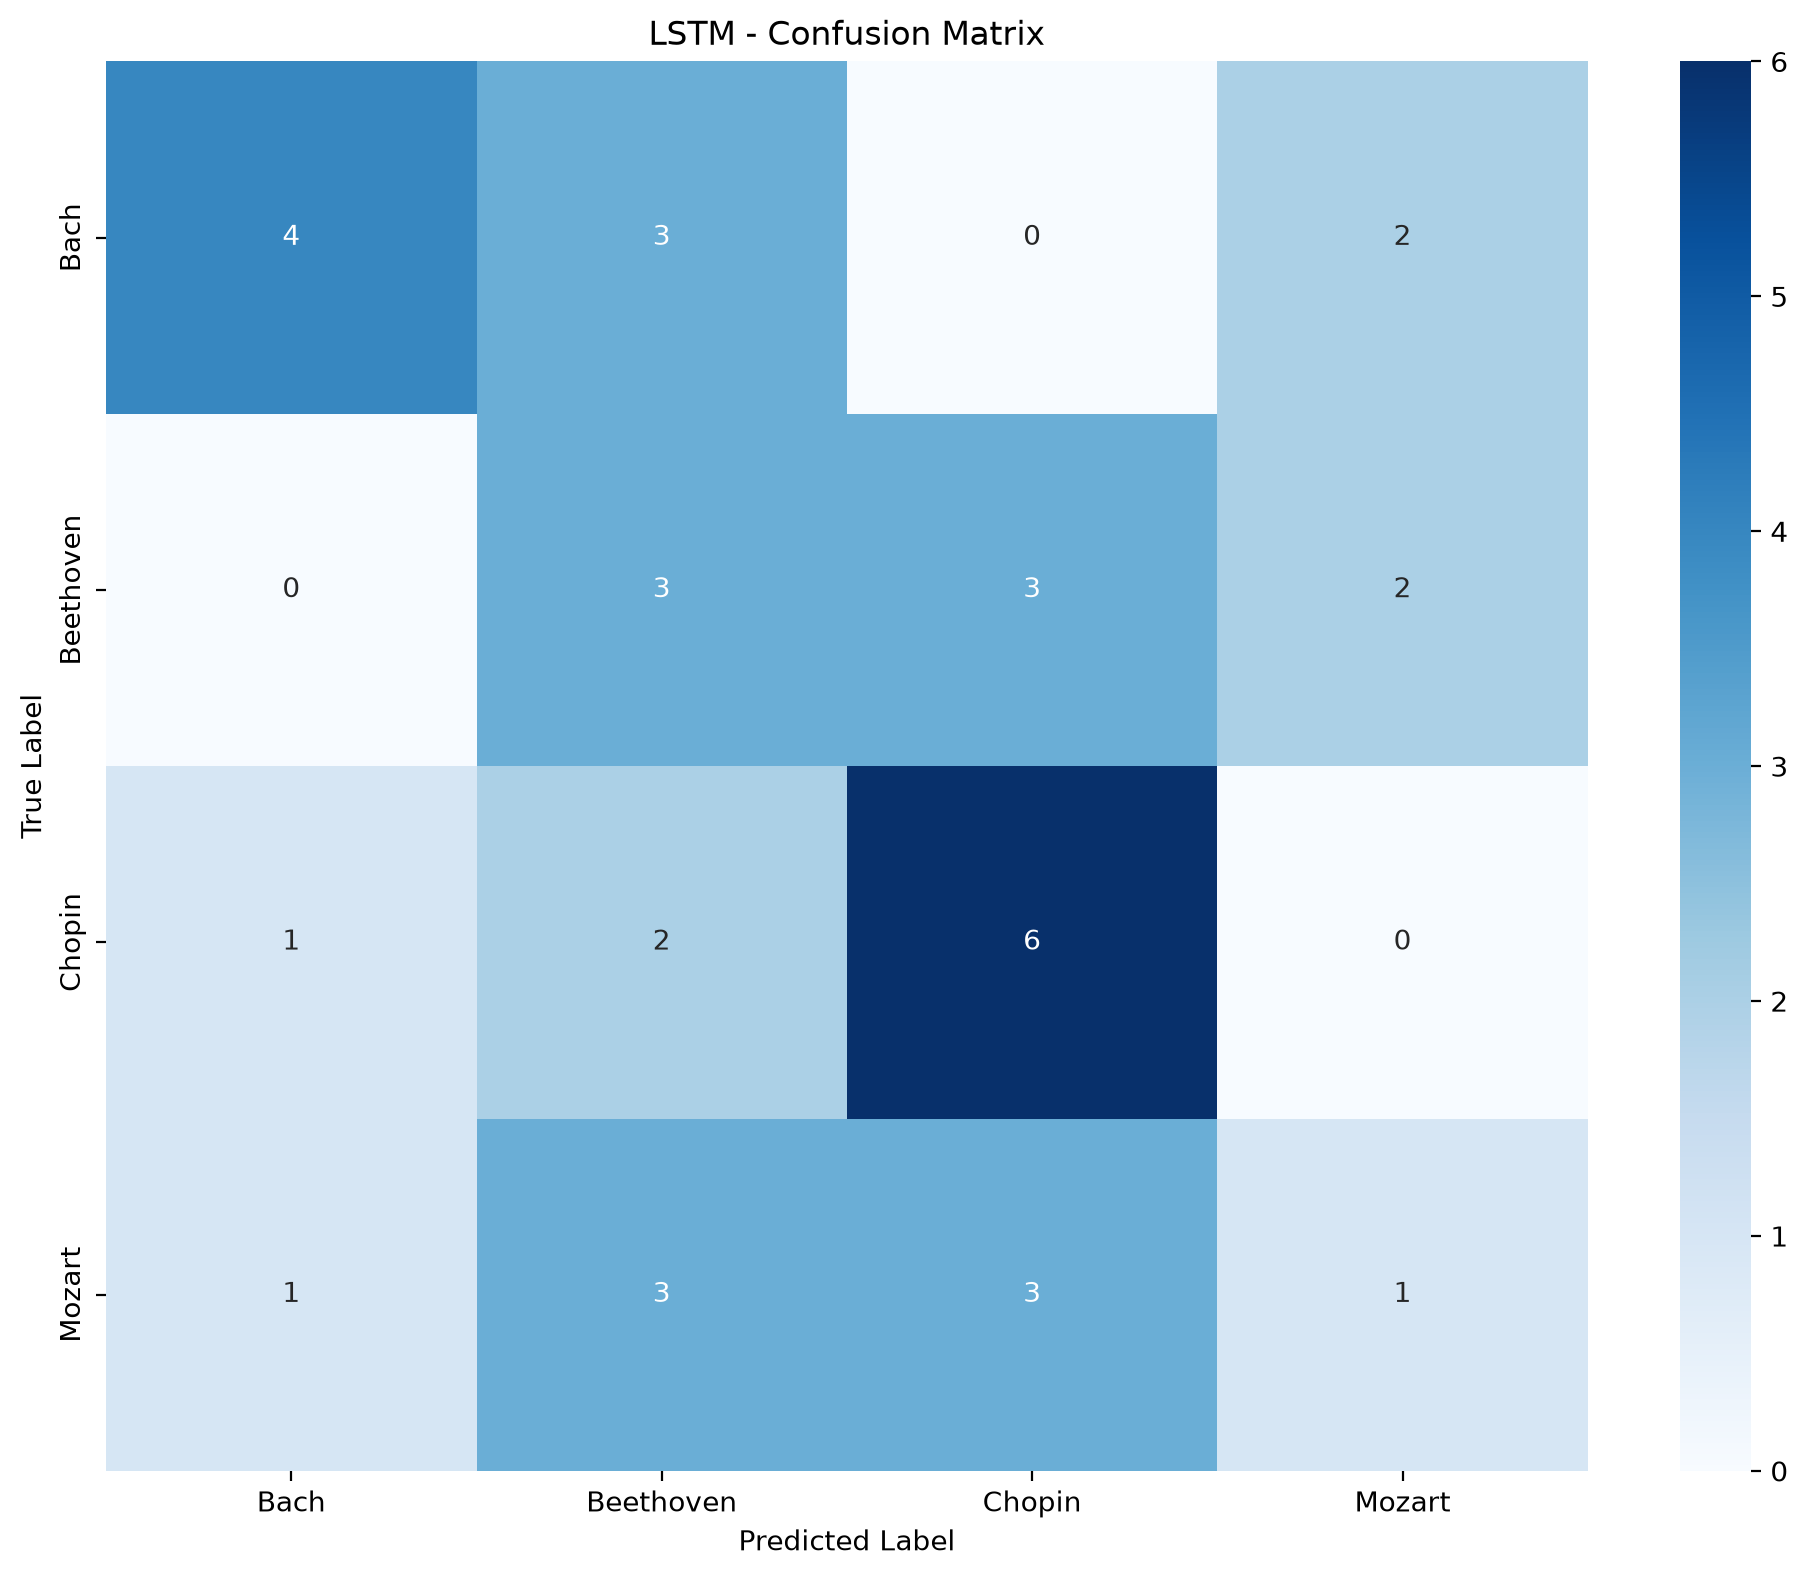

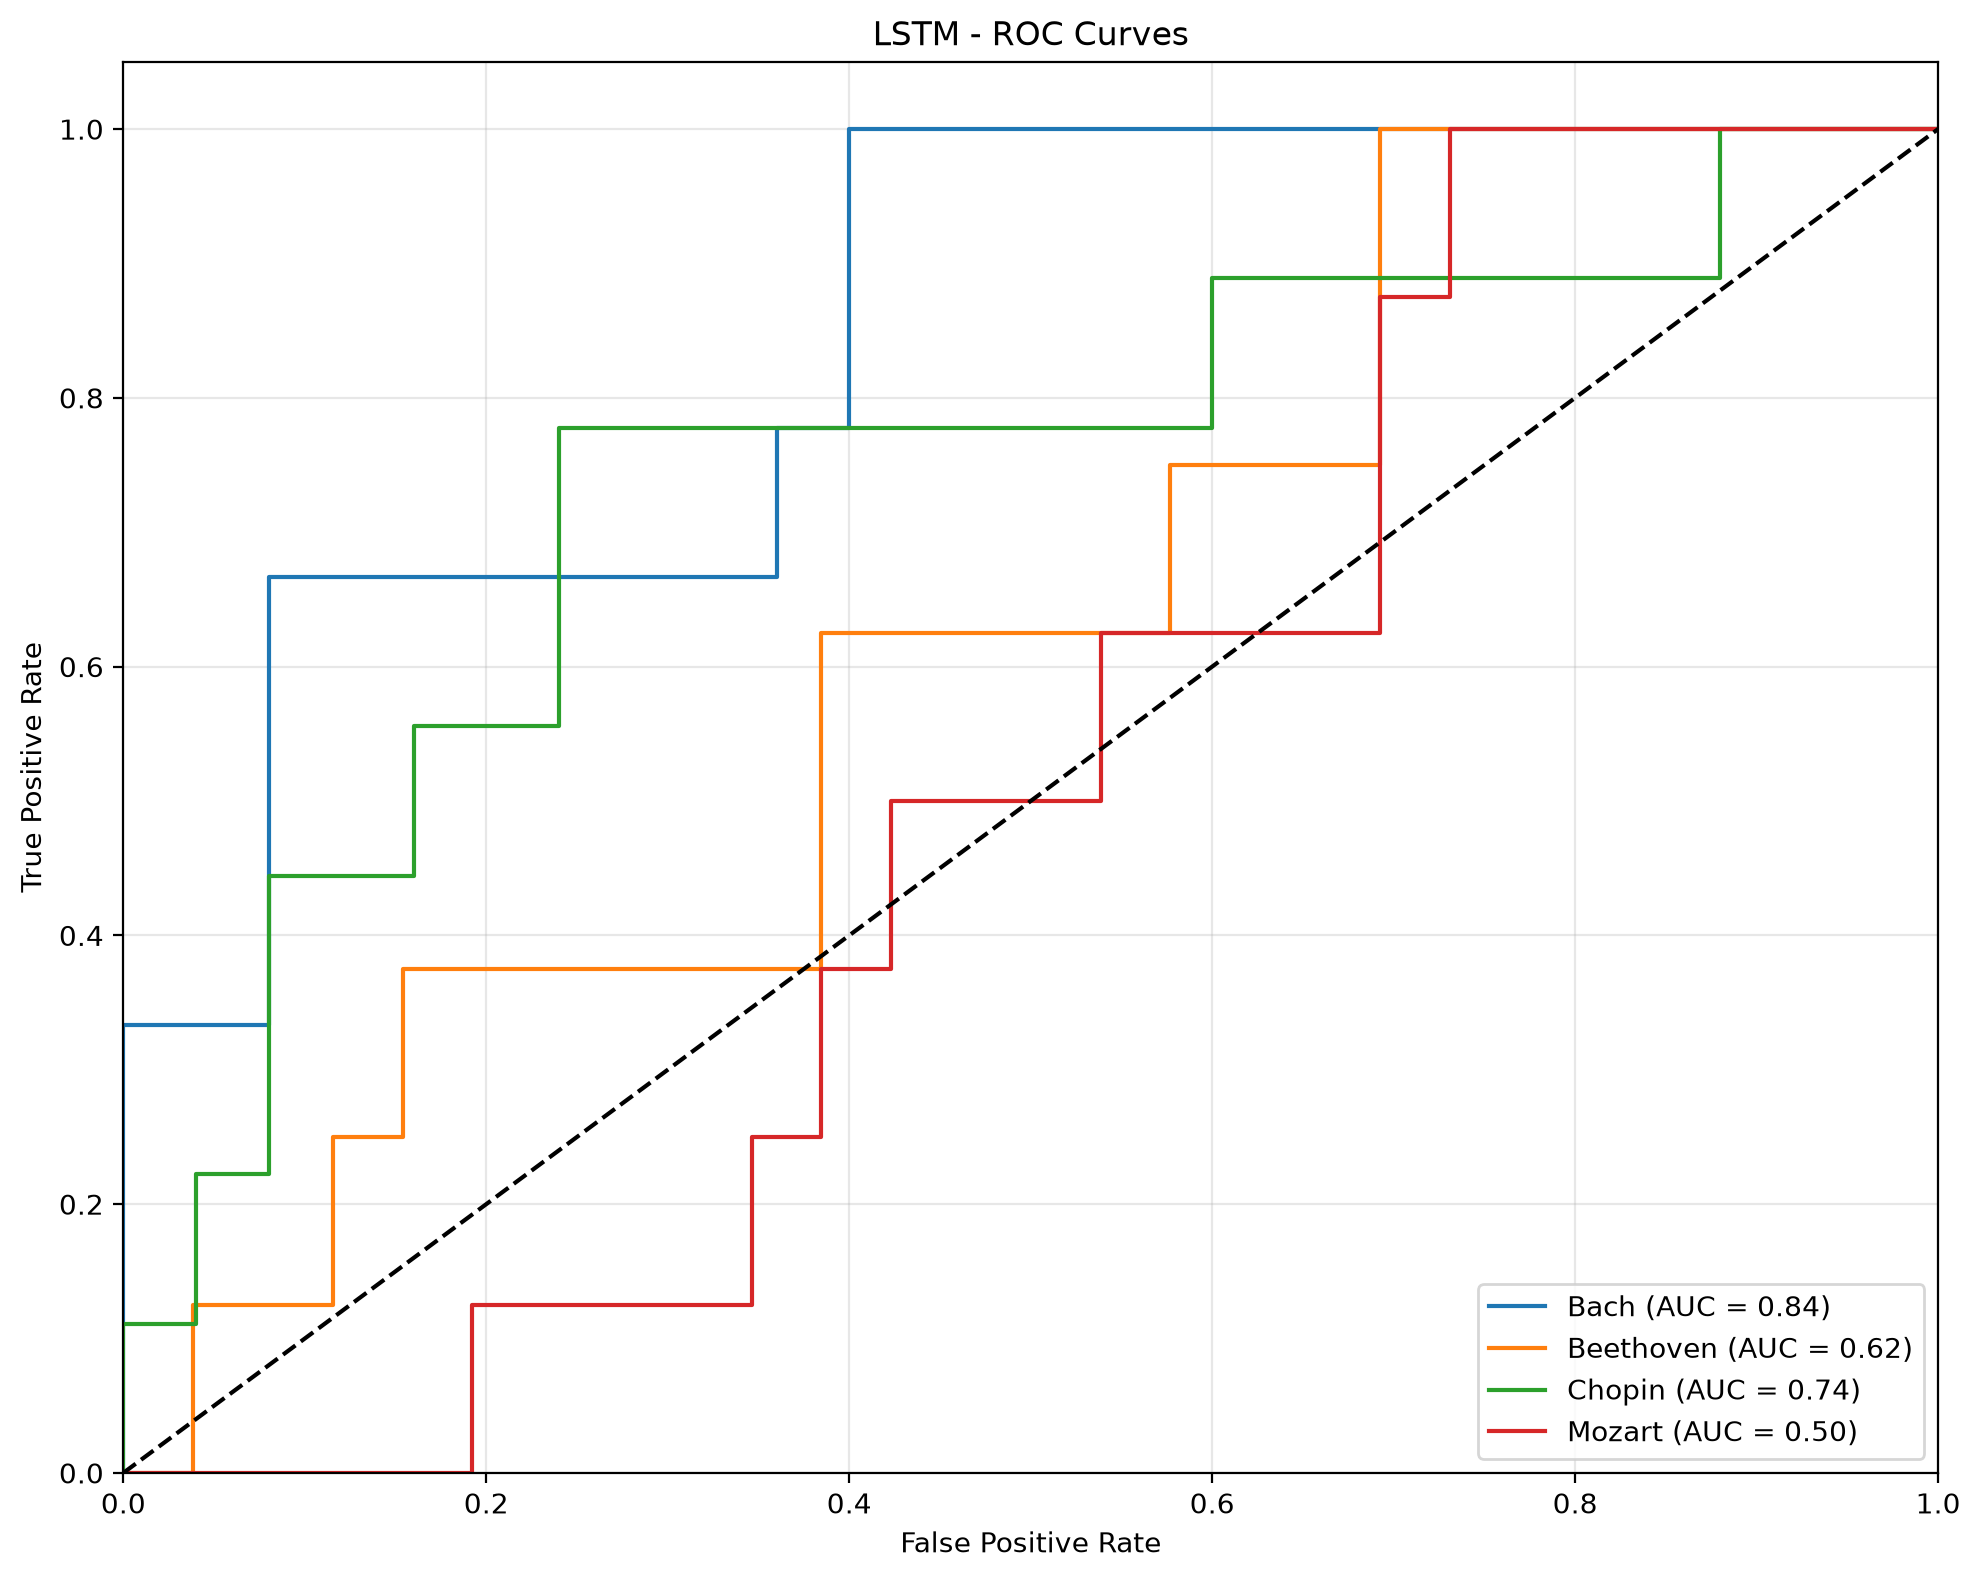

In [14]:
# Evaluate LSTM model
print("LSTM Model Evaluation:")
lstm_evaluator = ModelEvaluator(COMPOSERS)
lstm_metrics = lstm_evaluator.calculate_metrics(y_test_lstm, lstm_pred, lstm_pred_proba)
lstm_evaluator.print_metrics(y_test_lstm, lstm_pred, lstm_pred_proba)
lstm_evaluator.plot_confusion_matrix(y_test_lstm, lstm_pred, "LSTM", save_fig=True)
lstm_evaluator.plot_roc_curves(y_test_lstm, lstm_pred_proba, "LSTM", save_fig=True)

CNN Model Evaluation:

EVALUATION METRICS
Accuracy:  0.3824
Precision: 0.2224
Recall:    0.3824
F1 Score (weighted): 0.2611
F1 Score (macro):    0.2601
ROC-AUC:   0.7180

Per-Class Metrics:
--------------------------------------------------
Bach:
  Precision: 0.5556
  Recall:    0.5556
  F1 Score:  0.5556
Beethoven:
  Precision: 0.3200
  Recall:    1.0000
  F1 Score:  0.4848
Chopin:
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
Mozart:
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        Bach       0.56      0.56      0.56         9
   Beethoven       0.32      1.00      0.48         8
      Chopin       0.00      0.00      0.00         9
      Mozart       0.00      0.00      0.00         8

    accuracy                           0.38        34
   macro avg       0.22      0.39      0.26        34
weighted avg       0.22      0.

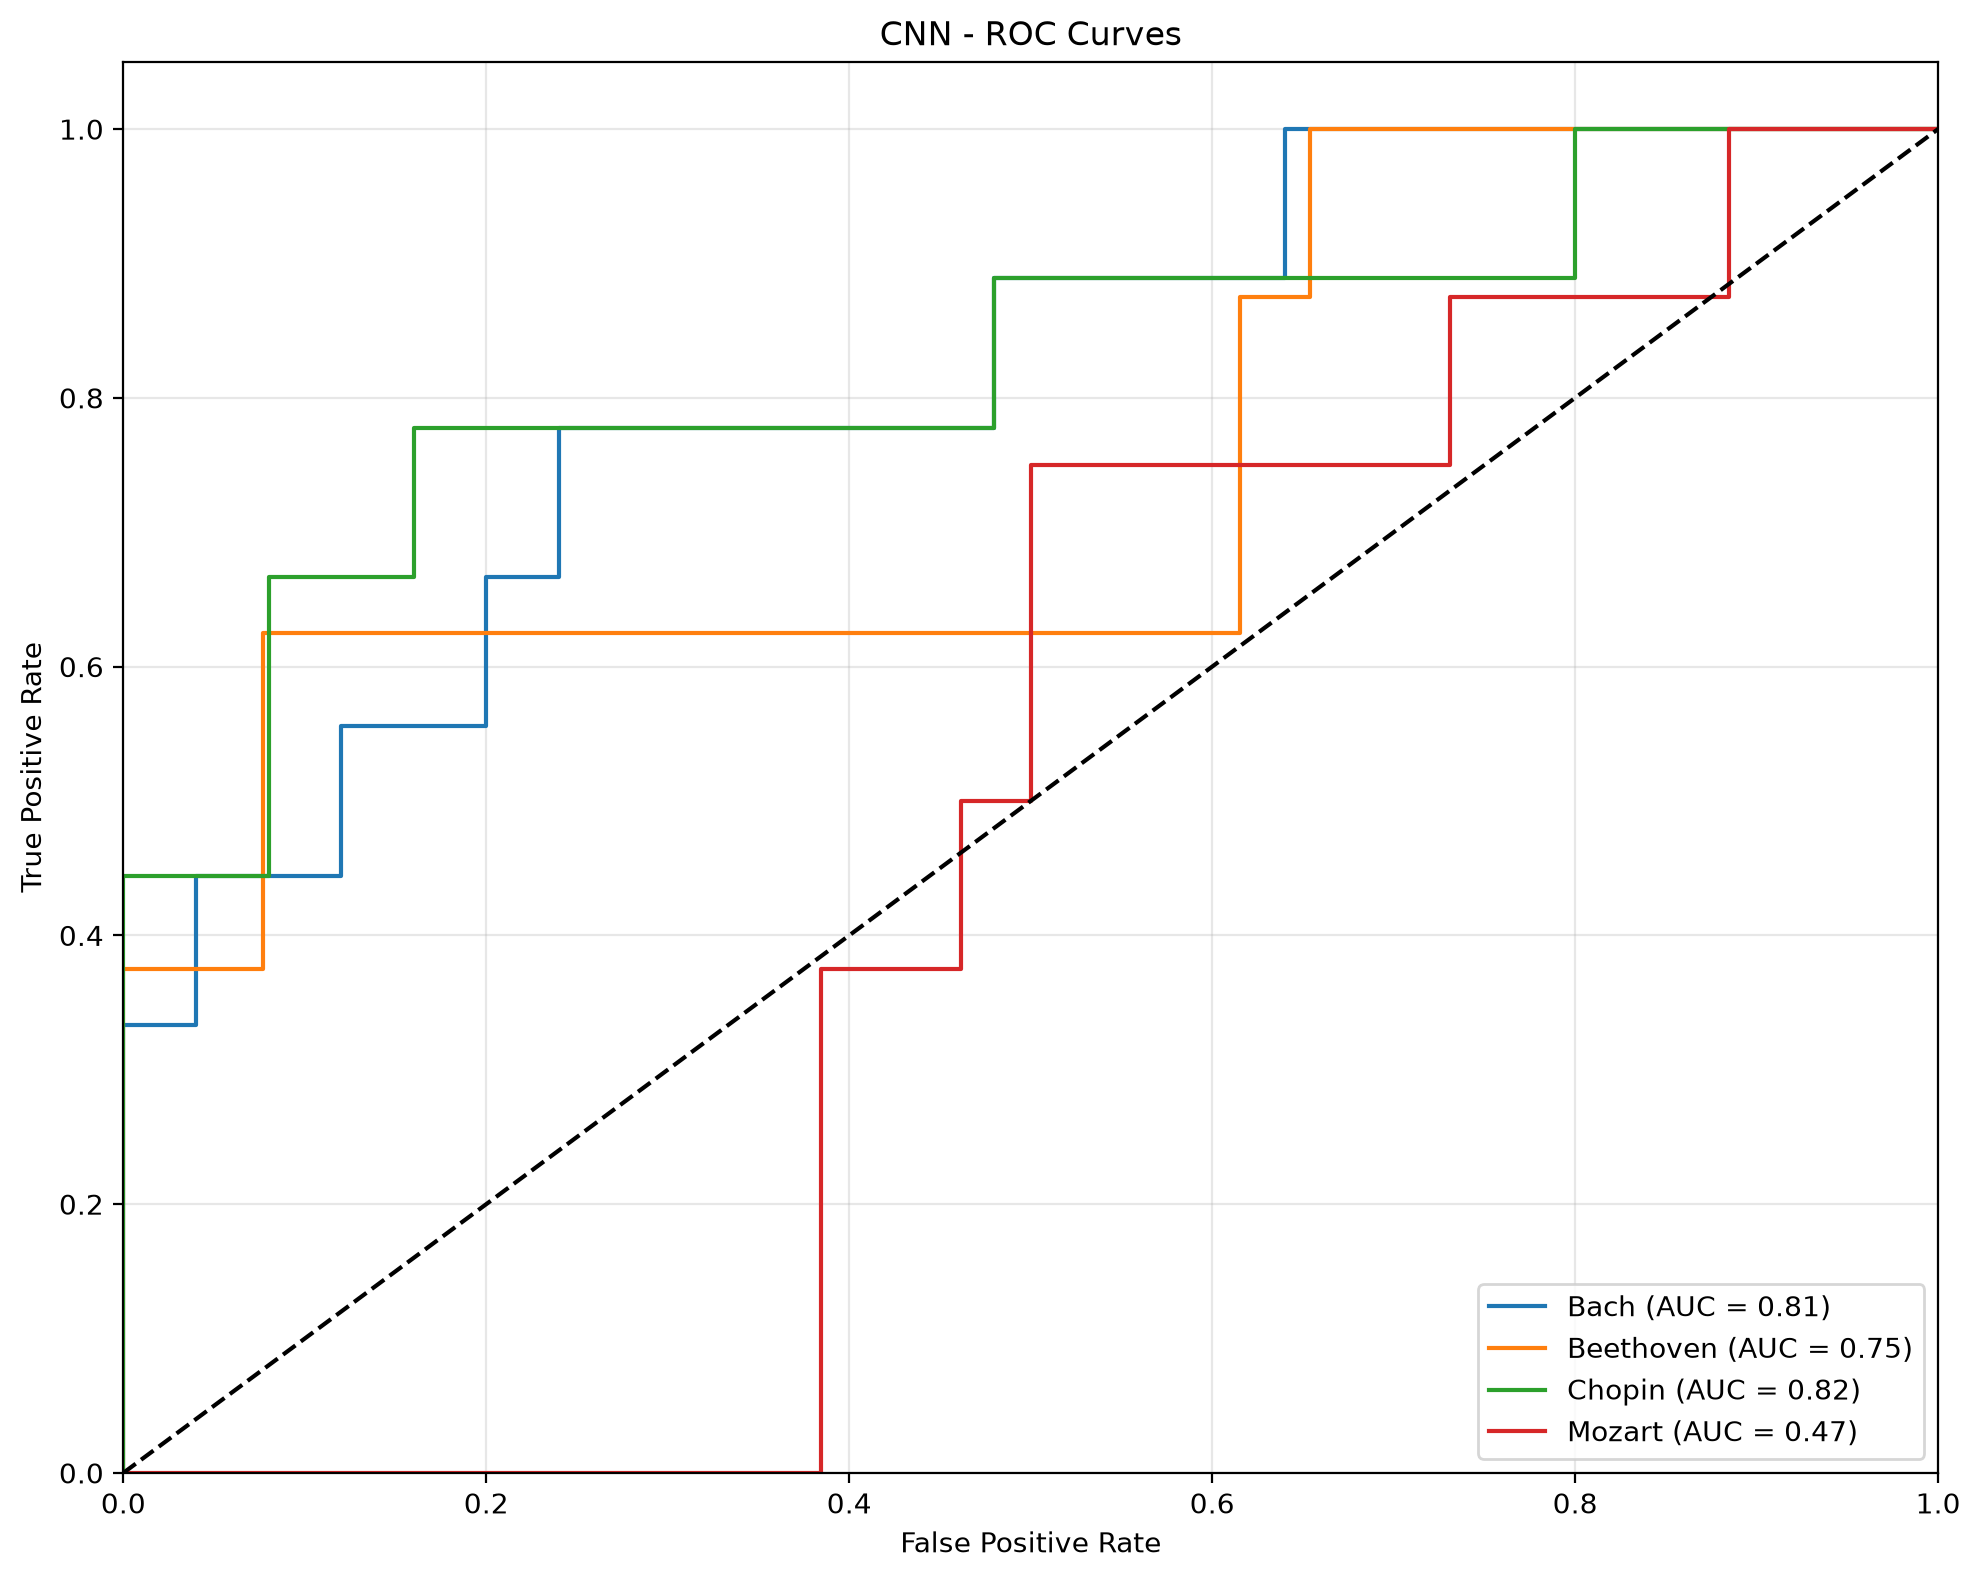

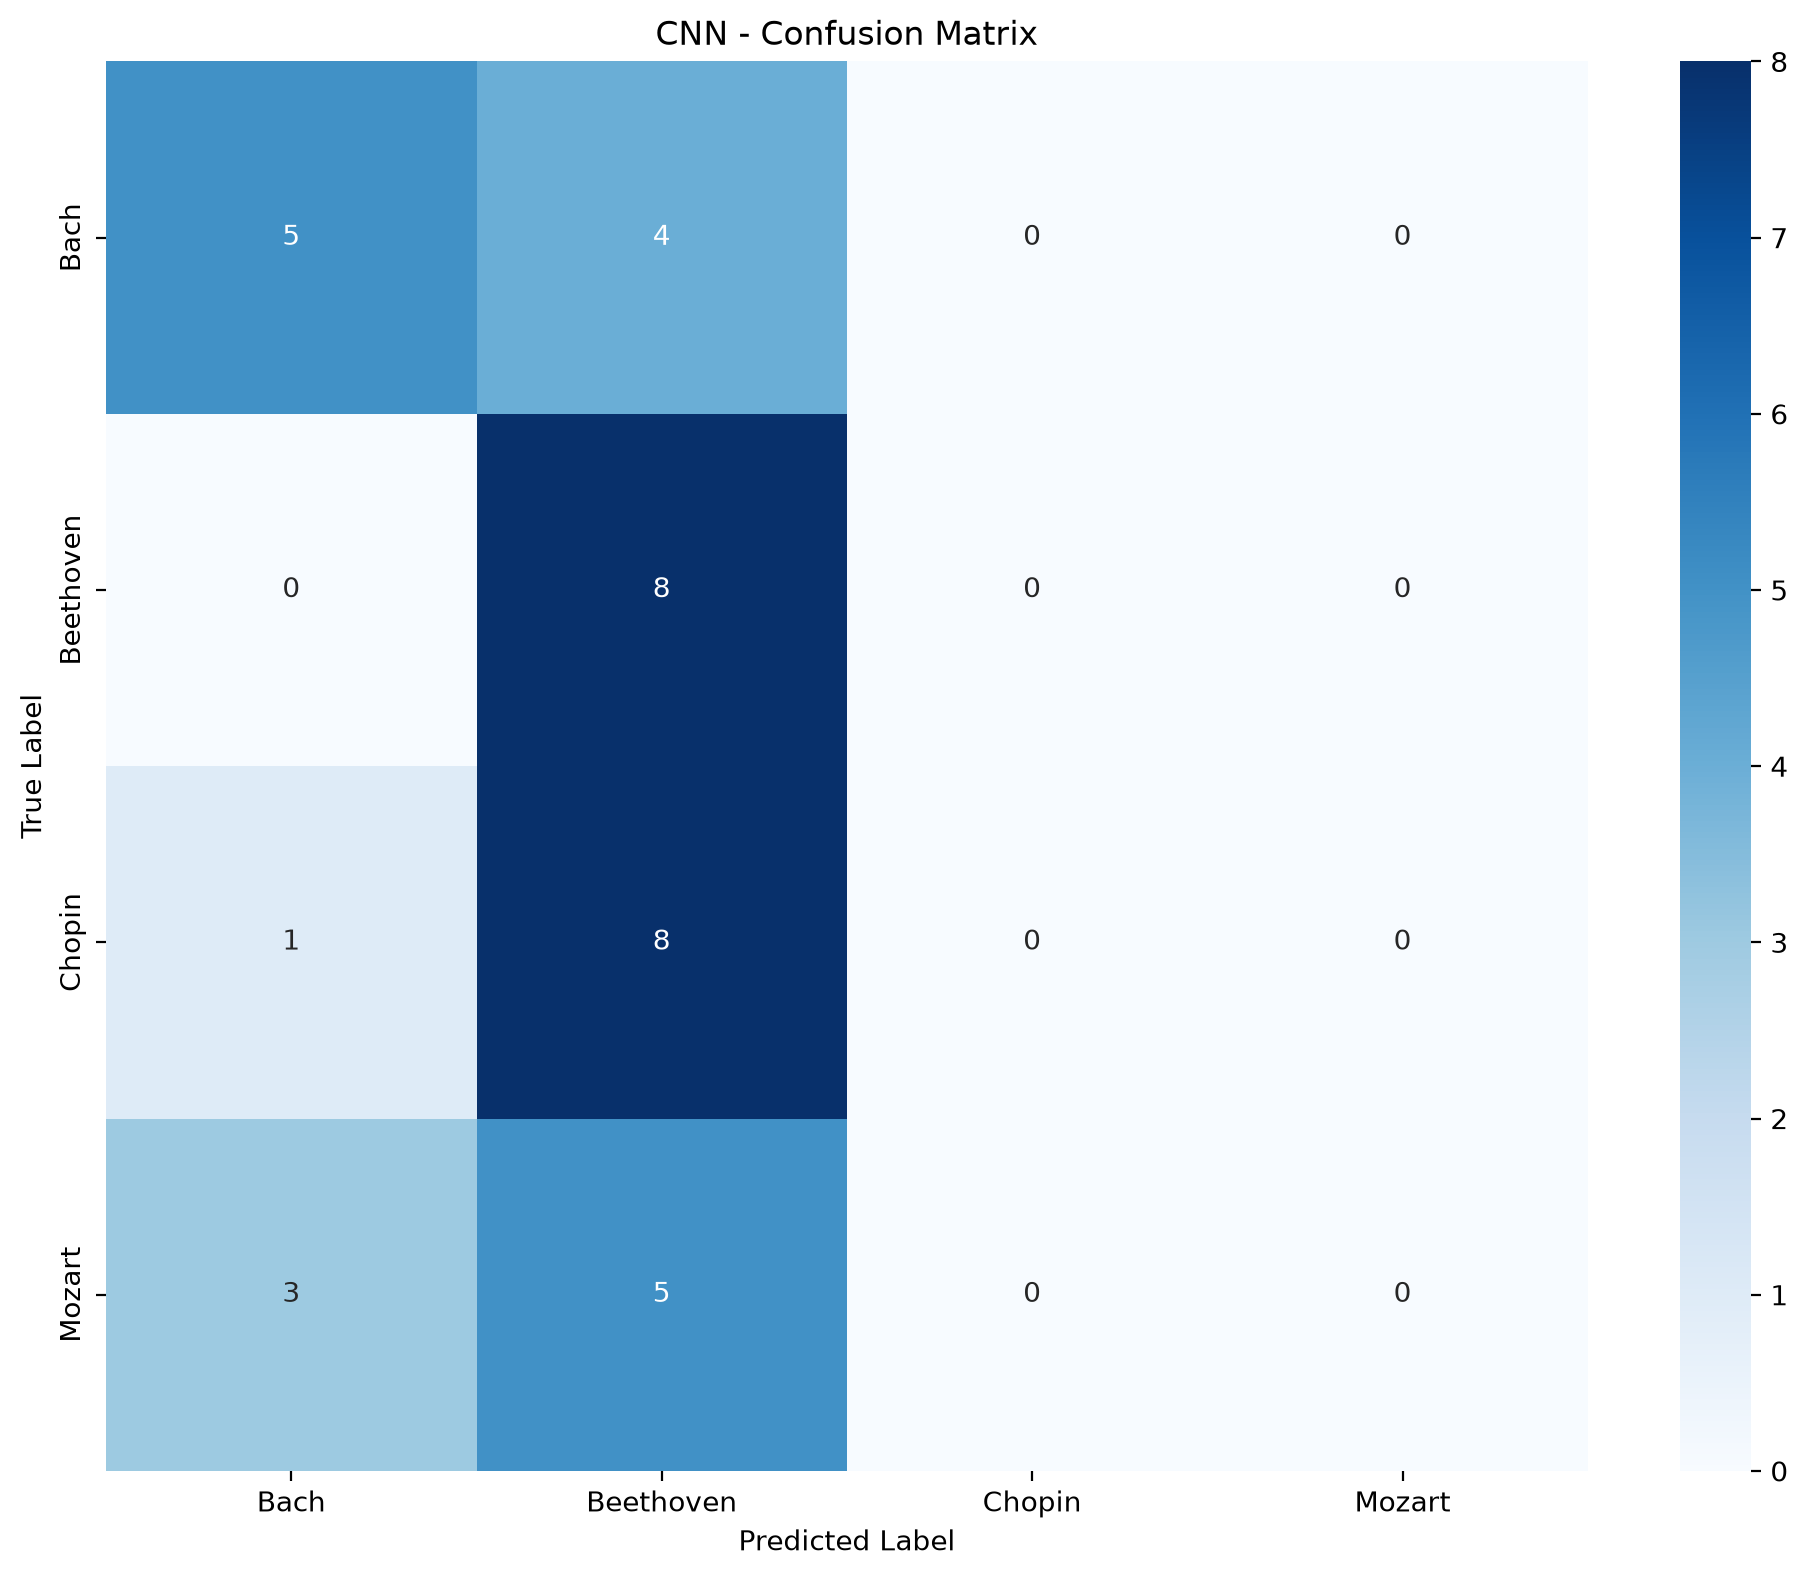

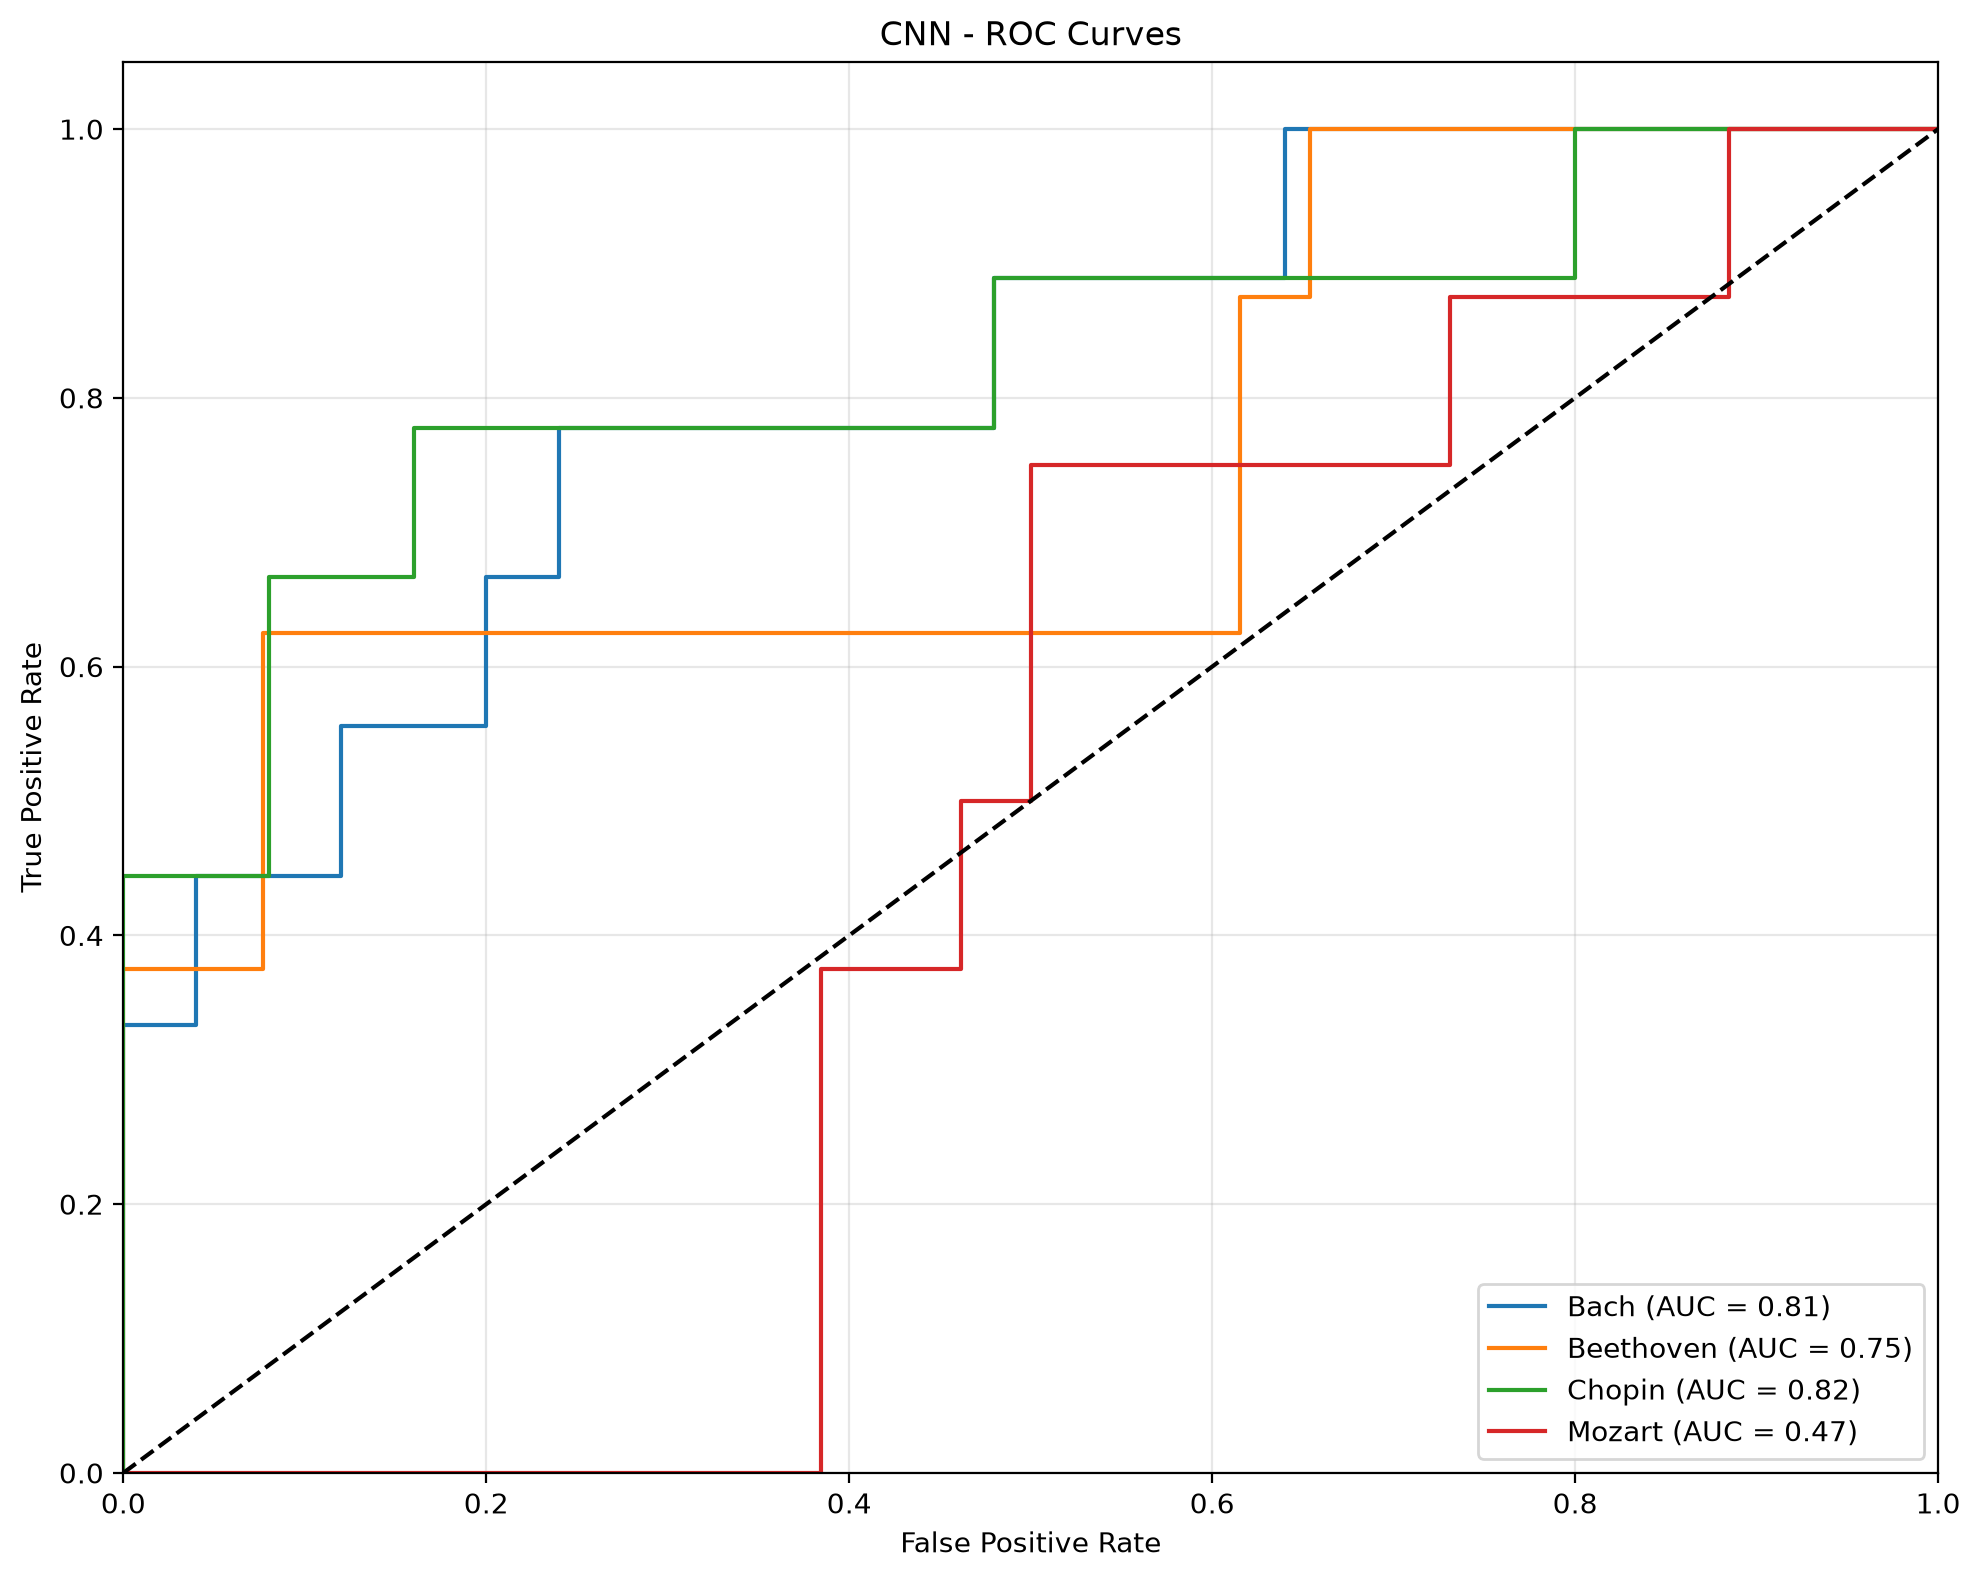

In [15]:
# Evaluate CNN model
print("CNN Model Evaluation:")
cnn_evaluator = ModelEvaluator(COMPOSERS)
cnn_metrics = cnn_evaluator.calculate_metrics(y_test_cnn, cnn_pred, cnn_pred_proba)
cnn_evaluator.print_metrics(y_test_cnn, cnn_pred, cnn_pred_proba)
cnn_evaluator.plot_confusion_matrix(y_test_cnn, cnn_pred, "CNN", save_fig=True)
cnn_evaluator.plot_roc_curves(y_test_cnn, cnn_pred_proba, "CNN", save_fig=True)

In [16]:
# Preserve baseline (default-param) metrics for post-tuning comparison
baseline_lstm_metrics = dict(lstm_metrics)
baseline_cnn_metrics = dict(cnn_metrics)
baseline_lstm_summary = dict(lstm_summary)
baseline_cnn_summary = dict(cnn_summary)
print("Baseline metrics saved for post-tuning comparison.")

Baseline metrics saved for post-tuning comparison.


## 8. Model Comparison

In [17]:
# Compare model performance
metrics_dict = {
    'LSTM': lstm_metrics,
    'CNN': cnn_metrics
}

# Create comparison table
visualizer = ModelVisualizer(COMPOSERS)
comparison_table = visualizer.create_comparison_table(
    metrics_dict, 
    save_path='model_comparison.csv'
)
comparison_table

Saved comparison table to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/tables/model_comparison.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LSTM,0.4118,0.4201,0.4118,0.4029,0.6836
1,CNN,0.3824,0.2224,0.3824,0.2611,0.7180


Saved model comparison plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/LSTM_vs_CNN_Model_Comparison.png


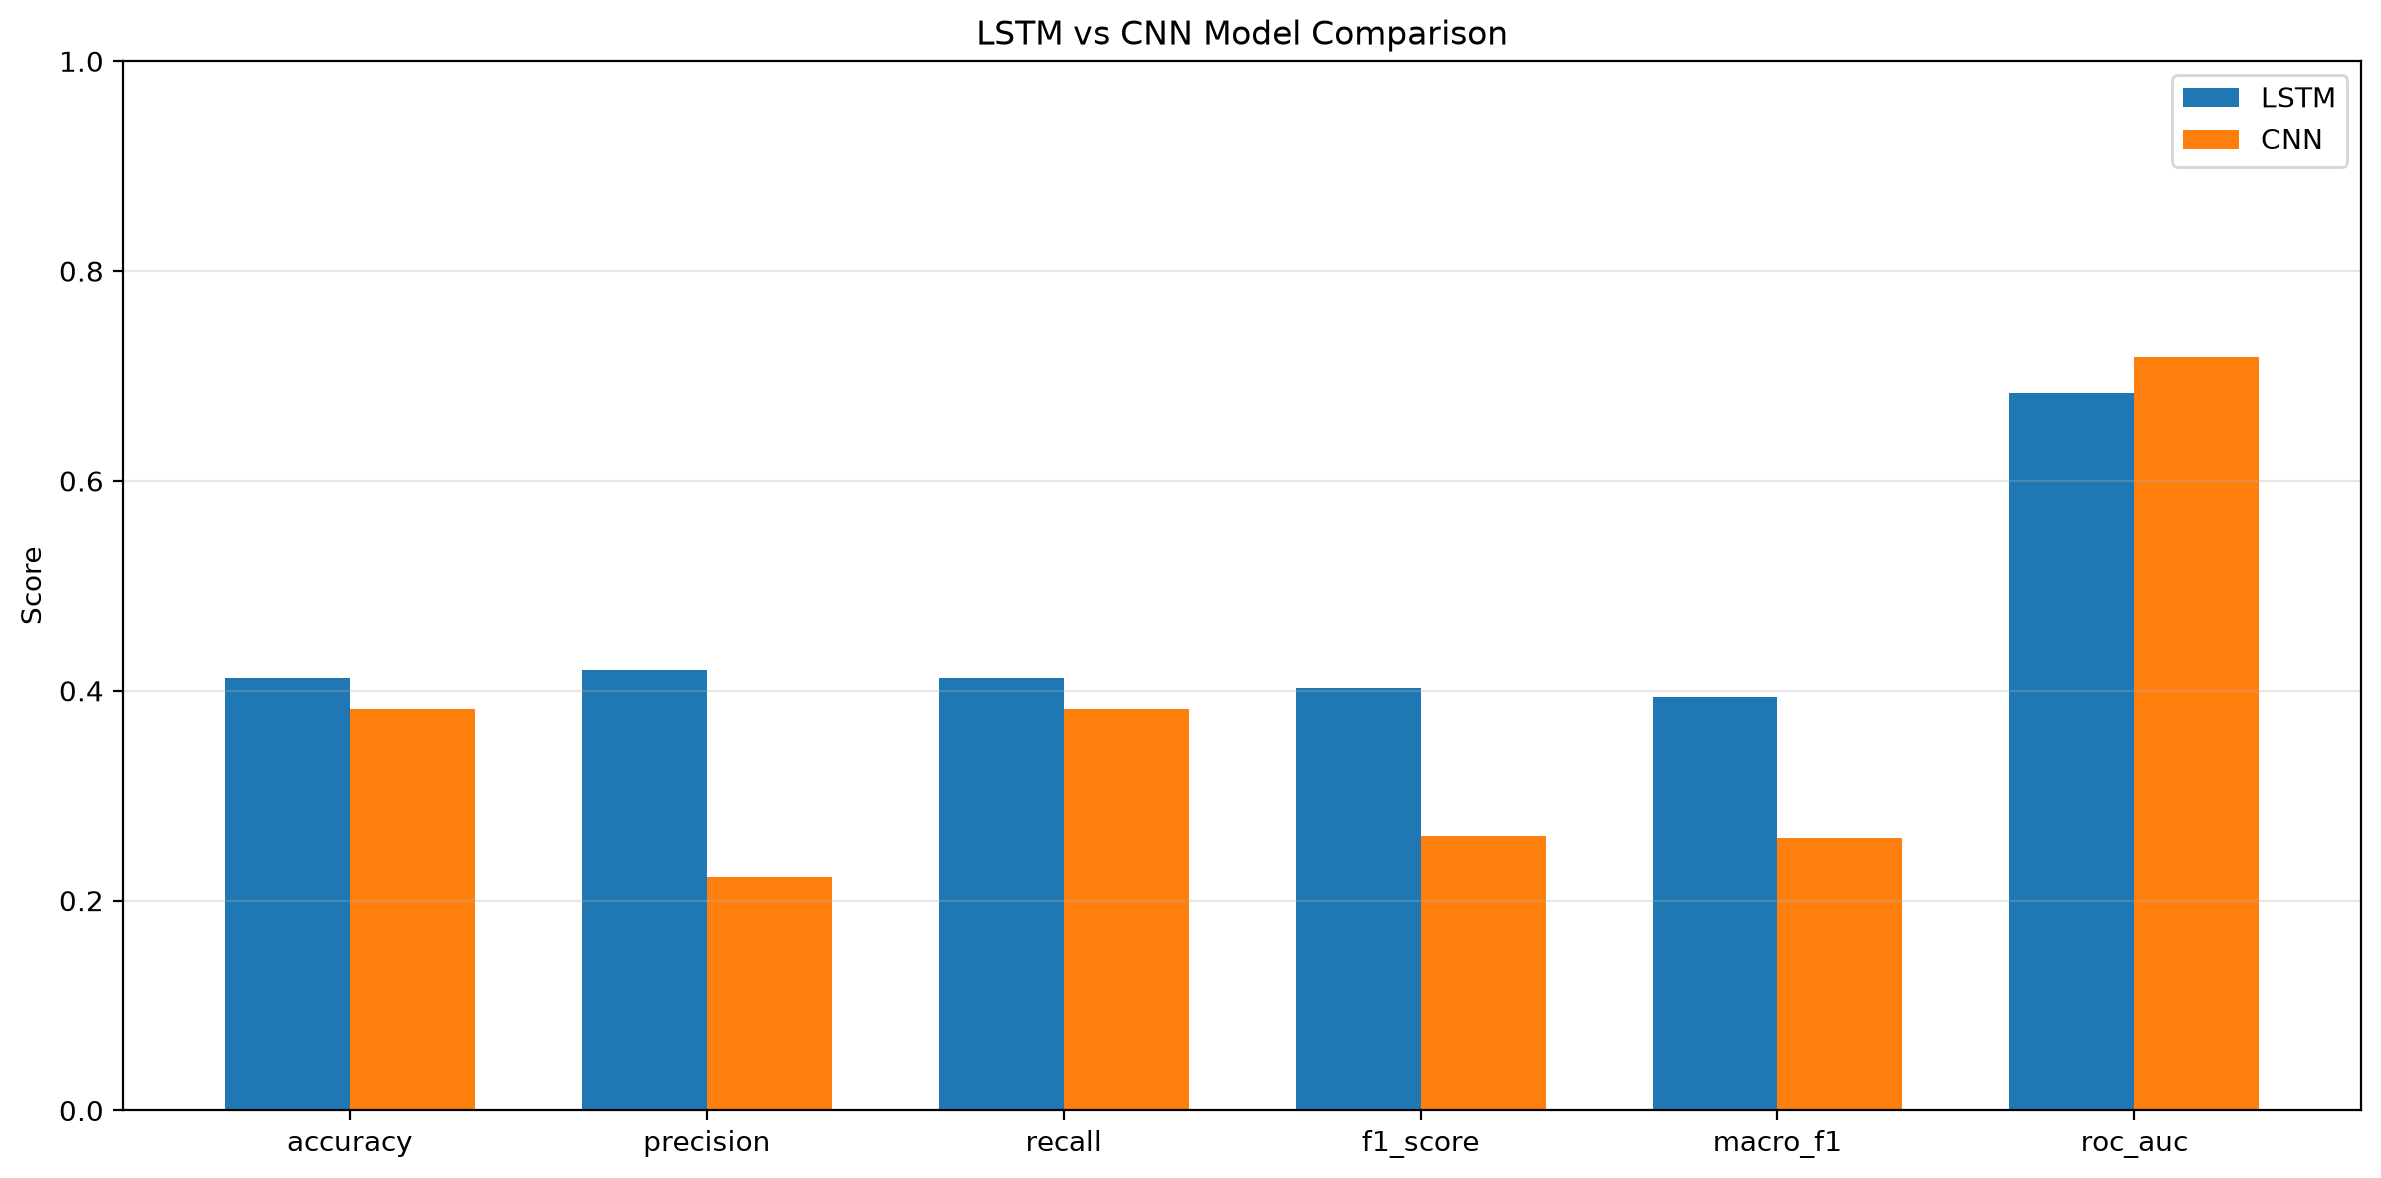

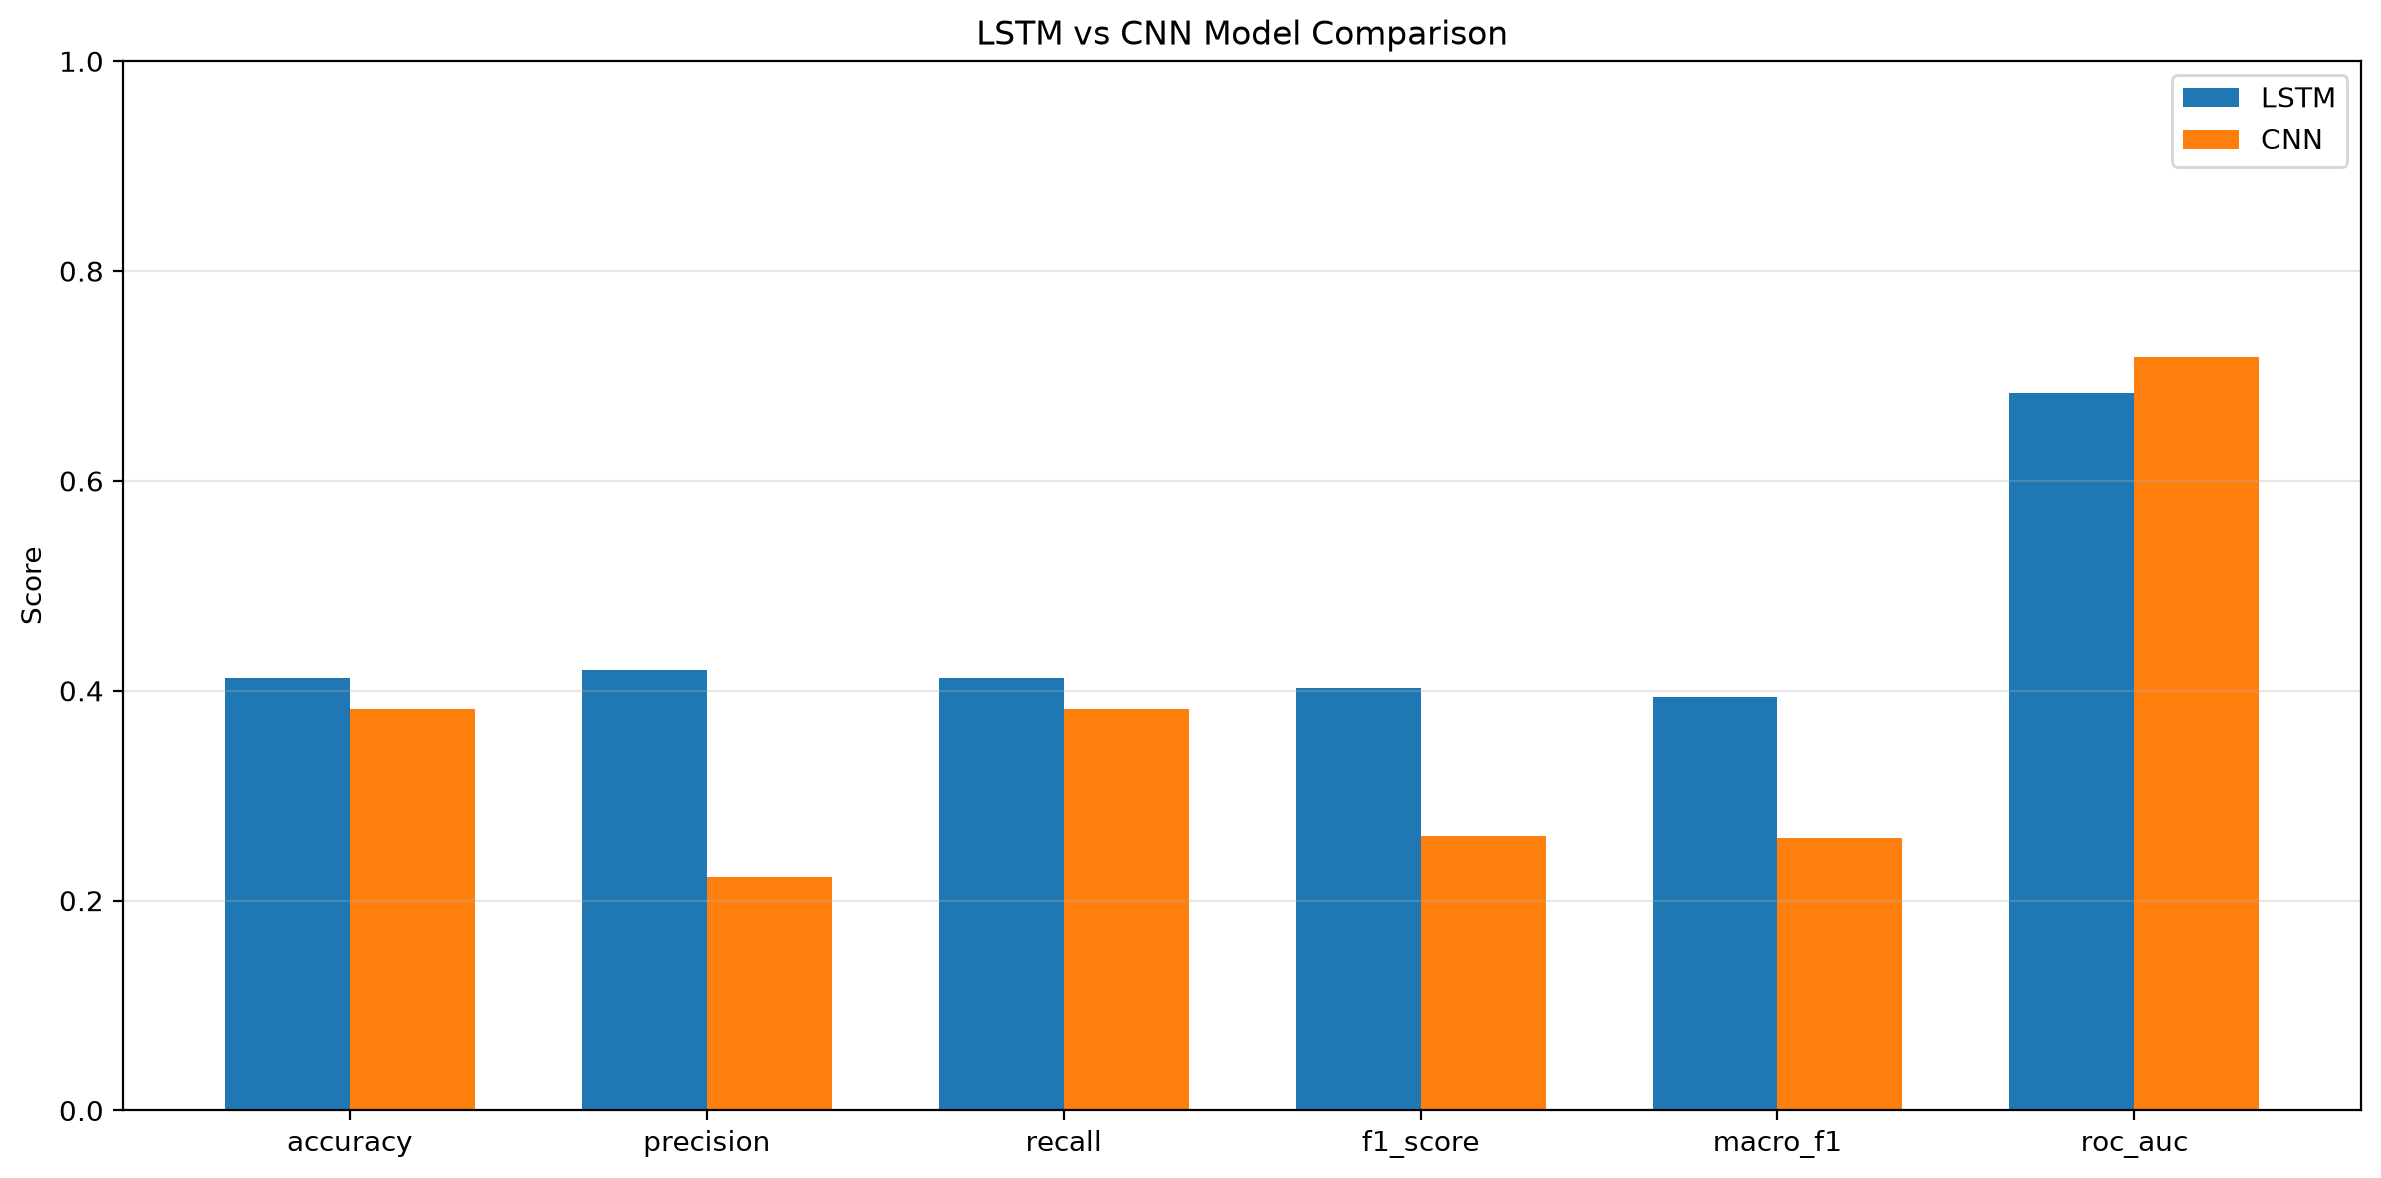

In [18]:
# Plot model comparison
visualizer.plot_model_comparison(
    metrics_dict,
    "LSTM vs CNN Model Comparison",
    save_fig=True
)

Saved per-class performance plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Per-Class_Performance_Comparison.png


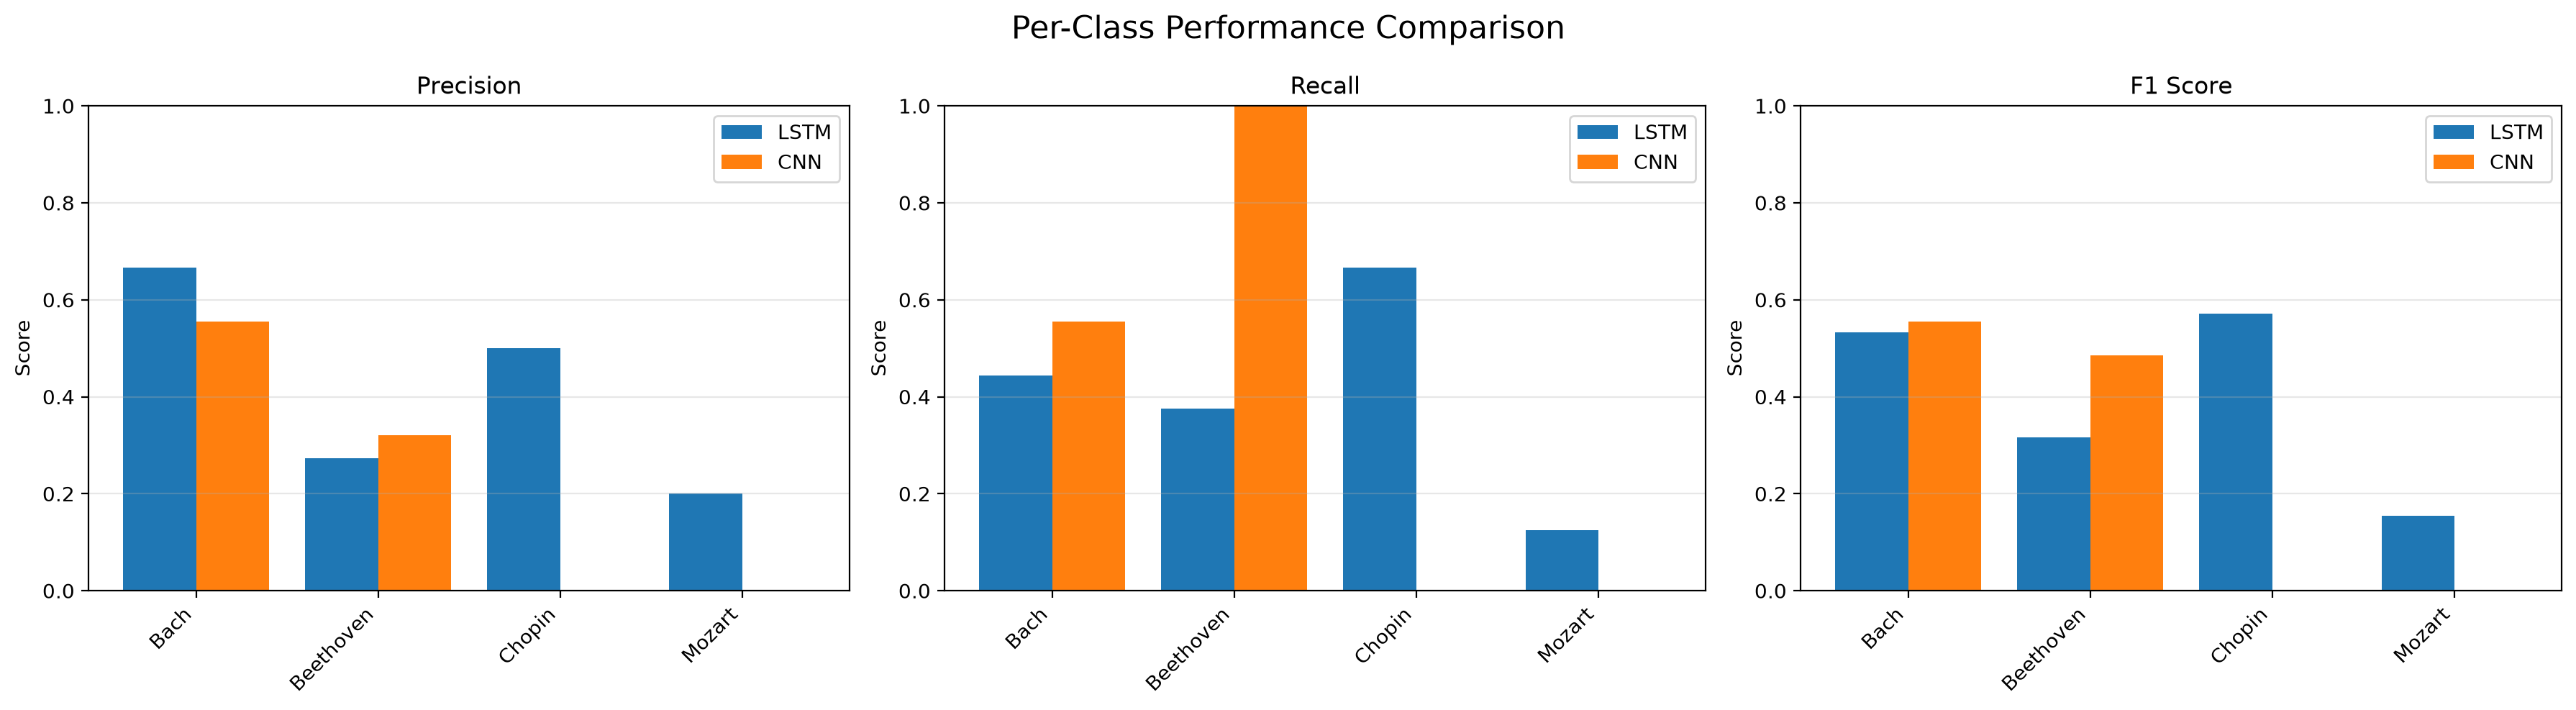

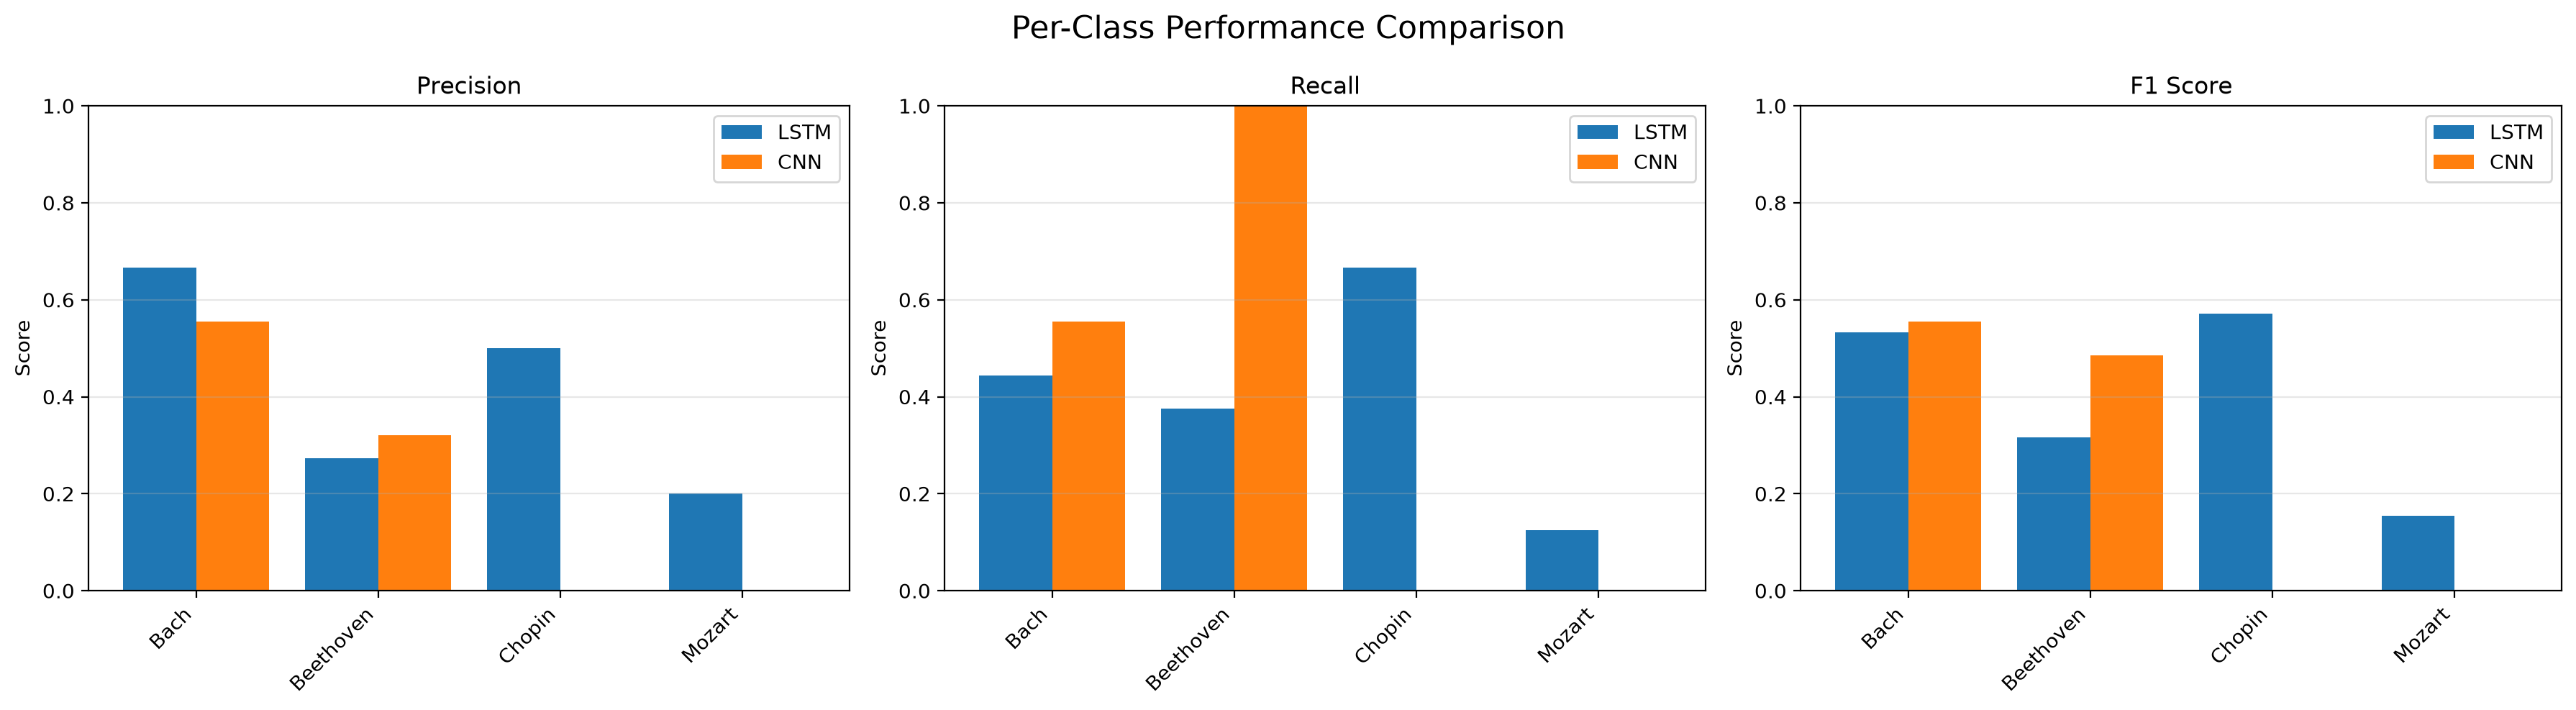

In [19]:
# Plot per-class performance
visualizer.plot_per_class_performance(
    metrics_dict,
    "Per-Class Performance Comparison",
    save_fig=True
)

## 9. Hyperparameter Tuning Results (Optional)

In [20]:
# Hyperparameter Tuning — LSTM
import itertools, json, time as _time
from src.models import create_lstm_model
from src.training import LSTMTrainer

lstm_param_grid = {
    'hidden_units': [128, 256],
    'dropout': [0.3, 0.5],
    'learning_rate': [1e-3, 1e-4],
}

TUNING_EPOCHS = 10  # short runs for selection

print("Starting LSTM hyperparameter search …")
lstm_results = []
for hu, dr, lr in itertools.product(
        lstm_param_grid['hidden_units'],
        lstm_param_grid['dropout'],
        lstm_param_grid['learning_rate']):
    label = f"hu={hu}, dr={dr}, lr={lr}"
    print(f"\n--- {label} ---")
    set_random_seed()
    model = create_lstm_model(
        X_train_lstm.shape[1:], NUM_CLASSES,
        model_type='standard',
        hidden_units=hu, dropout=dr, learning_rate=lr)
    trainer = LSTMTrainer(model, batch_size=LSTM_BATCH_SIZE, epochs=TUNING_EPOCHS)
    history = trainer.train(X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm)
    val_metrics = trainer.evaluate(X_val_lstm, y_val_lstm)
    lstm_results.append({
        'hidden_units': hu, 'dropout': dr, 'learning_rate': lr,
        'val_accuracy': val_metrics['test_accuracy'],
        'val_f1': val_metrics['f1_score']
    })
    print(f"  val_acc={val_metrics['test_accuracy']:.4f}  val_f1={val_metrics['f1_score']:.4f}")

best_lstm_hp = max(lstm_results, key=lambda r: r['val_accuracy'])
print(f"\nBest LSTM params: {best_lstm_hp}")

Starting LSTM hyperparameter search …

--- hu=128, dr=0.3, lr=0.001 ---
Training LSTM model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2687 - loss: 1.3884
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - accuracy: 0.2687 - loss: 1.3884 - val_accuracy: 0.2353 - val_loss: 1.3663 - learning_rate: 0.0010
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.3507 - loss: 1.3458
Epoch 2: val_accuracy improved from 0.23529 to 0.38235, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 2: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 0.3507 - loss: 1.3458 - val_accuracy: 0.3824 - val_loss: 1.3066 - learning_rate: 0.0010
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.3433 - loss: 1.3310
Epoch 3: val_accuracy did not improve from 0.38235
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 320ms/step - accuracy: 0.3433 - loss: 1.3310 - val_accuracy: 0.3529 - val_loss: 1.3103 - learning_rate: 0.0010
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.3993 - loss: 1.2809
Epoch 4: val_accuracy did not improve from 0.38235
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - accuracy: 0.3993 - loss: 1.2809 - val_accuracy: 0.3529 - val_loss: 1.2730 - learning_rate: 0.0010
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.4216 - loss: 1.2445
Epoch 5: val_accuracy did not i


Epoch 7: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.4030 - loss: 1.2213 - val_accuracy: 0.4118 - val_loss: 1.2673 - learning_rate: 0.0010
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4254 - loss: 1.2350
Epoch 8: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step - accuracy: 0.4254 - loss: 1.2350 - val_accuracy: 0.4118 - val_loss: 1.2991 - learning_rate: 0.0010
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.4478 - loss: 1.2266
Epoch 9: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 0.4478 - loss: 1.2266 - val_accuracy: 0.3824 - val_loss: 1.2761 - learning_rate: 0.0010
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.4366 - loss: 1.2054
Epoch 10: val_accuracy did not

Training completed in 30s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Test Loss: 1.2673
Test Accuracy: 0.4118
Precision: 0.4461
Recall: 0.4118
F1 Score (weighted): 0.3609
F1 Score (macro):    0.3682
  val_acc=0.4118  val_f1=0.3609

--- hu=128, dr=0.3, lr=0.0001 ---
Training LSTM model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.2090 - loss: 1.3910
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5


...


Epoch 6: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 830ms/step - accuracy: 0.4142 - loss: 1.2574 - val_accuracy: 0.4706 - val_loss: 1.3113 - learning_rate: 0.0010
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.4179 - loss: 1.2655
Epoch 7: val_accuracy did not improve from 0.47059
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 845ms/step - accuracy: 0.4179 - loss: 1.2655 - val_accuracy: 0.4412 - val_loss: 1.2624 - learning_rate: 0.0010
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.4179 - loss: 1.2354
Epoch 8: val_accuracy did not improve from 0.47059
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 857ms/step - accuracy: 0.4179 - loss: 1.2354 - val_accuracy: 0.4118 - val_loss: 1.2921 - learning_rate: 0.0010
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.4478 - loss: 1.2021
Epoch 9: val_accuracy did not i

Training completed in 1m 17s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step
Test Loss: 1.3113
Test Accuracy: 0.4706
Precision: 0.6529
Recall: 0.4706
F1 Score (weighted): 0.4311
F1 Score (macro):    0.4384
  val_acc=0.4706  val_f1=0.4311

--- hu=256, dr=0.5, lr=0.0001 ---
Training LSTM model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.2351 - loss: 1.3879
Epoch 1: val_accuracy improved from None to 0.29412, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 855ms/step - accuracy: 0.2351 - loss: 1.3879 - val_accuracy: 0.2941 - val_loss: 1.3829 - learning_rate: 1.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.2948 - loss: 1.3815
Epoch 2: val_accuracy did not improve from 0.29412
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 867ms/step - accuracy: 0.2948 - loss: 1.3815 - val_accuracy: 0.2941 - val_loss: 1.3785 - learning_rate: 1.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.3433 - loss: 1.3709
Epoch 3: val_accuracy did not improve from 0.29412
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 832ms/step - accuracy: 0.3433 - loss: 1.3709 - val_accuracy: 0.2647 - val_loss: 1.3737 - learning_rate: 1.0000e-04
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.3246 - loss: 1.3748
Epoch 4: val_accura


Epoch 8: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 865ms/step - accuracy: 0.4067 - loss: 1.3041 - val_accuracy: 0.4412 - val_loss: 1.2866 - learning_rate: 1.0000e-04
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.4328 - loss: 1.2419
Epoch 9: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 813ms/step - accuracy: 0.4328 - loss: 1.2419 - val_accuracy: 0.4412 - val_loss: 1.3057 - learning_rate: 1.0000e-04
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.4403 - loss: 1.2825
Epoch 10: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 882ms/step - accuracy: 0.4403 - loss: 1.2825 - val_accuracy: 0.4412 - val_loss: 1.2682 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 8.


Training completed in 1m 18s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step
Test Loss: 1.2866
Test Accuracy: 0.4412
Precision: 0.4669
Recall: 0.4412
F1 Score (weighted): 0.3606
F1 Score (macro):    0.3567
  val_acc=0.4412  val_f1=0.3606

Best LSTM params: {'hidden_units': 256, 'dropout': 0.3, 'learning_rate': 0.001, 'val_accuracy': 0.5, 'val_f1': 0.4795518207282913}


In [21]:
# Hyperparameter Tuning — CNN
from src.models import create_cnn_model
from src.training import CNNTrainer

cnn_param_grid = {
    'filters': [[32, 64, 128], [64, 128, 256]],
    'dropout': [0.3, 0.5],
    'learning_rate': [1e-3, 1e-4],
}

print("Starting CNN hyperparameter search …")
cnn_results = []
for filt, dr, lr in itertools.product(
        cnn_param_grid['filters'],
        cnn_param_grid['dropout'],
        cnn_param_grid['learning_rate']):
    label = f"filt={filt}, dr={dr}, lr={lr}"
    print(f"\n--- {label} ---")
    set_random_seed()
    model = create_cnn_model(
        X_train_cnn.shape[1:], NUM_CLASSES,
        model_type='standard',
        filters=filt, dropout=dr, learning_rate=lr)
    trainer = CNNTrainer(model, batch_size=CNN_BATCH_SIZE, epochs=TUNING_EPOCHS)
    history = trainer.train(X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn)
    val_metrics = trainer.evaluate(X_val_cnn, y_val_cnn)
    cnn_results.append({
        'filters': filt, 'dropout': dr, 'learning_rate': lr,
        'val_accuracy': val_metrics['test_accuracy'],
        'val_f1': val_metrics['f1_score']
    })
    print(f"  val_acc={val_metrics['test_accuracy']:.4f}  val_f1={val_metrics['f1_score']:.4f}")

best_cnn_hp = max(cnn_results, key=lambda r: r['val_accuracy'])
print(f"\nBest CNN params: {best_cnn_hp}")

Starting CNN hyperparameter search …

--- filt=[32, 64, 128], dr=0.3, lr=0.001 ---
Training CNN model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 932ms/step - accuracy: 0.3619 - loss: 1.5877
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 971ms/step - accuracy: 0.3619 - loss: 1.5877 - val_accuracy: 0.2353 - val_loss: 1.3660 - learning_rate: 0.0010
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.4739 - loss: 1.3039
Epoch 2: val_accuracy improved from 0.23529 to 0.41176, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 2: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 956ms/step - accuracy: 0.4739 - loss: 1.3039 - val_accuracy: 0.4118 - val_loss: 1.3485 - learning_rate: 0.0010
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.5299 - loss: 1.1367
Epoch 3: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 950ms/step - accuracy: 0.5299 - loss: 1.1367 - val_accuracy: 0.2647 - val_loss: 1.3647 - learning_rate: 0.0010
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.5000 - loss: 1.1008
Epoch 4: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 972ms/step - accuracy: 0.5000 - loss: 1.1008 - val_accuracy: 0.2647 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.5560 - loss: 1.0324
Epoch 5: val_accuracy did not im

Training completed in 1m 28s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Test Loss: 1.3485
Test Accuracy: 0.4118
Precision: 0.5189
Recall: 0.4118
F1 Score (weighted): 0.3451
F1 Score (macro):    0.3370
  val_acc=0.4118  val_f1=0.3451

--- filt=[32, 64, 128], dr=0.3, lr=0.0001 ---
Training CNN model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - accuracy: 0.3470 - loss: 1.5032
Epoch 1: val_accuracy improved from None to 0.41176, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 978ms/step - accuracy: 0.3470 - loss: 1.5032 - val_accuracy: 0.4118 - val_loss: 1.3821 - learning_rate: 1.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 943ms/step - accuracy: 0.4142 - loss: 1.3232
Epoch 2: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 967ms/step - accuracy: 0.4142 - loss: 1.3232 - val_accuracy: 0.2647 - val_loss: 1.3800 - learning_rate: 1.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.4739 - loss: 1.2532
Epoch 3: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 961ms/step - accuracy: 0.4739 - loss: 1.2532 - val_accuracy: 0.2647 - val_loss: 1.3819 - learning_rate: 1.0000e-04
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.4515 - loss: 1.1938
Epoch 4: val_accura

...

Training completed in 3m 42s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Test Loss: 1.3680
Test Accuracy: 0.5294
Precision: 0.6638
Recall: 0.5294
F1 Score (weighted): 0.4843
F1 Score (macro):    0.4900
  val_acc=0.5294  val_f1=0.4843

--- filt=[64, 128, 256], dr=0.5, lr=0.0001 ---
Training CNN model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3060 - loss: 1.6161
Epoch 1: val_accuracy improved from None to 0.26471, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3060 - loss: 1.6161 - val_accuracy: 0.2647 - val_loss: 1.3866 - learning_rate: 1.0000e-04
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4104 - loss: 1.4843
Epoch 2: val_accuracy did not improve from 0.26471
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4104 - loss: 1.4843 - val_accuracy: 0.2647 - val_loss: 1.3886 - learning_rate: 1.0000e-04
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4067 - loss: 1.5131
Epoch 3: val_accuracy improved from 0.26471 to 0.35294, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 3: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4067 - loss: 1.5131 - val_accuracy: 0.3529 - val_loss: 1.3876 - learning_rate: 1.0000e-04
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4403 - loss: 1.4346
Epoch 4: val_accuracy did not improve from 0.35294
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4403 - loss: 1.4346 - val_accuracy: 0.2647 - val_loss: 1.3889 - learning_rate: 1.0000e-04
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4627 - loss: 1.3421
Epoch 5: val_accuracy did not improve from 0.35294
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4627 - loss: 1.3421 - val_accuracy: 0.2647 - val_loss: 1.3899 - learning_rate: 1.0000e-04
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4403 - loss: 1.4243
Epoch 6: val_accuracy did not impro


Epoch 9: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4478 - loss: 1.3819 - val_accuracy: 0.3824 - val_loss: 1.4064 - learning_rate: 5.0000e-05
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4627 - loss: 1.3324
Epoch 10: val_accuracy did not improve from 0.38235
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4627 - loss: 1.3324 - val_accuracy: 0.3235 - val_loss: 1.4122 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 9.


Training completed in 3m 48s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Test Loss: 1.4064
Test Accuracy: 0.3824
Precision: 0.1949
Recall: 0.3824
F1 Score (weighted): 0.2551
F1 Score (macro):    0.2409
  val_acc=0.3824  val_f1=0.2551

Best CNN params: {'filters': [64, 128, 256], 'dropout': 0.5, 'learning_rate': 0.001, 'val_accuracy': 0.529411792755127, 'val_f1': 0.484313725490196}


In [22]:
# Tuning results summary table
tuning_df = pd.DataFrame(lstm_results)
tuning_df.columns = [c.replace('_', ' ').title() for c in tuning_df.columns]
print("LSTM Tuning Results:")
print(tuning_df.to_string(index=False))

print()

tuning_cnn_df = pd.DataFrame(cnn_results)
tuning_cnn_df.columns = [c.replace('_', ' ').title() for c in tuning_cnn_df.columns]
print("CNN Tuning Results:")
print(tuning_cnn_df.to_string(index=False))

LSTM Tuning Results:
 Hidden Units  Dropout  Learning Rate  Val Accuracy   Val F1
          128      0.3         0.0010      0.411765 0.360949
          128      0.3         0.0001      0.411765 0.371849
          128      0.5         0.0010      0.411765 0.333792
          128      0.5         0.0001      0.352941 0.235294
          256      0.3         0.0010      0.500000 0.479552
          256      0.3         0.0001      0.470588 0.380502
          256      0.5         0.0010      0.470588 0.431092
          256      0.5         0.0001      0.441176 0.360570

CNN Tuning Results:
       Filters  Dropout  Learning Rate  Val Accuracy   Val F1
 [32, 64, 128]      0.3         0.0010      0.411765 0.345065
 [32, 64, 128]      0.3         0.0001      0.411765 0.281250
 [32, 64, 128]      0.5         0.0010      0.411765 0.272561
 [32, 64, 128]      0.5         0.0001      0.294118 0.163235
[64, 128, 256]      0.3         0.0010      0.441176 0.295777
[64, 128, 256]      0.3         0.000

In [23]:
# Retrain LSTM with best hyperparameters
print("Retraining LSTM with tuned hyperparameters …")
set_random_seed()
best_lstm_model = create_lstm_model(
    X_train_lstm.shape[1:], NUM_CLASSES,
    model_type='standard',
    hidden_units=best_lstm_hp['hidden_units'],
    dropout=best_lstm_hp['dropout'],
    learning_rate=best_lstm_hp['learning_rate']
)
best_lstm_model.summary()
lstm_trainer = LSTMTrainer(best_lstm_model, batch_size=LSTM_BATCH_SIZE, epochs=LSTM_EPOCHS)
lstm_history = lstm_trainer.train(X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm)
lstm_metrics = lstm_trainer.evaluate(X_test_lstm, y_test_lstm)
lstm_trainer.save_final_model()
lstm_summary = lstm_trainer.get_training_summary()
print(f"\nTuned LSTM — Test Accuracy: {lstm_metrics['test_accuracy']:.4f}  Macro F1: {lstm_metrics['macro_f1']:.4f}")

Retraining LSTM with tuned hyperparameters …


Model: "LSTM_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 500, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 500, 256)       │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,964 (3.15 MB)

 Trainable params: 824,964 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Training LSTM model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.2910 - loss: 1.3766
Epoch 1: val_accuracy improved from None to 0.35294, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step - accuracy: 0.2910 - loss: 1.3766 - val_accuracy: 0.3529 - val_loss: 1.3166 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.3545 - loss: 1.3731
Epoch 2: val_accuracy did not improve from 0.35294
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 716ms/step - accuracy: 0.3545 - loss: 1.3731 - val_accuracy: 0.3529 - val_loss: 1.2695 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.3209 - loss: 1.3131
Epoch 3: val_accuracy improved from 0.35294 to 0.50000, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 3: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 748ms/step - accuracy: 0.3209 - loss: 1.3131 - val_accuracy: 0.5000 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.3918 - loss: 1.2731
Epoch 4: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 784ms/step - accuracy: 0.3918 - loss: 1.2731 - val_accuracy: 0.3529 - val_loss: 1.3068 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.4179 - loss: 1.2542
Epoch 5: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 787ms/step - accuracy: 0.4179 - loss: 1.2542 - val_accuracy: 0.4118 - val_loss: 1.2611 - learning_rate: 0.0010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.4179 - loss: 1.2288
Epoch 6: val_accuracy did not i

Training completed in 1m 30s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step
Test Loss: 1.2824
Test Accuracy: 0.4118
Precision: 0.4201
Recall: 0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_final.h5

Tuned LSTM — Test Accuracy: 0.4118  Macro F1: 0.3936


In [24]:
# Retrain CNN with best hyperparameters
print("Retraining CNN with tuned hyperparameters …")
set_random_seed()
best_cnn_model = create_cnn_model(
    X_train_cnn.shape[1:], NUM_CLASSES,
    model_type='standard',
    filters=best_cnn_hp['filters'],
    dropout=best_cnn_hp['dropout'],
    learning_rate=best_cnn_hp['learning_rate']
)
best_cnn_model.summary()
cnn_trainer = CNNTrainer(best_cnn_model, batch_size=CNN_BATCH_SIZE, epochs=CNN_EPOCHS)
cnn_history = cnn_trainer.train(X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn)
cnn_metrics = cnn_trainer.evaluate(X_test_cnn, y_test_cnn)
cnn_trainer.save_final_model()
cnn_summary = cnn_trainer.get_training_summary()
print(f"\nTuned CNN — Test Accuracy: {cnn_metrics['test_accuracy']:.4f}  Macro F1: {cnn_metrics['macro_f1']:.4f}")

Retraining CNN with tuned hyperparameters …


Model: "CNN_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 128, 1000, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 1000, 64)  │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128, 1000, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 500, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64, 500, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 250, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 32, 250, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,140 (1.93 MB)

 Trainable params: 505,220 (1.93 MB)

 Non-trainable params: 1,920 (7.50 KB)

Training CNN model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3396 - loss: 1.7798
Epoch 1: val_accuracy improved from None to 0.52941, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.3396 - loss: 1.7798 - val_accuracy: 0.5294 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4552 - loss: 1.4665
Epoch 2: val_accuracy did not improve from 0.52941
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4552 - loss: 1.4665 - val_accuracy: 0.2647 - val_loss: 1.3724 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4328 - loss: 1.4492
Epoch 3: val_accuracy did not improve from 0.52941
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4328 - loss: 1.4492 - val_accuracy: 0.2647 - val_loss: 1.4090 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4590 - loss: 1.3359
Epoch 4: val_accuracy did not improve from 0.52

Training completed in 4m 13s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Test Loss: 1.3668
Test Accuracy: 0.5000
Precision: 0.4108
Recall: 0.5000
F1 Score (weighted): 0.4480
F1 Score (macro):    0.4425
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_final.h5

Tuned CNN — Test Accuracy: 0.5000  Macro F1: 0.4425


## 10. Post-Tuning Model Comparison

Re-evaluate both tuned models on the test set and compare against the baseline (default hyperparameter) results.

In [25]:
# Evaluate tuned models on test set
from tensorflow import keras

# Load tuned LSTM best model & predict
tuned_lstm_model = keras.models.load_model(BEST_LSTM_MODEL)
tuned_lstm_pred_proba = tuned_lstm_model.predict(X_test_lstm)
tuned_lstm_pred = np.argmax(tuned_lstm_pred_proba, axis=1)

# Load tuned CNN best model & predict
tuned_cnn_model = keras.models.load_model(BEST_CNN_MODEL)
tuned_cnn_pred_proba = tuned_cnn_model.predict(X_test_cnn)
tuned_cnn_pred = np.argmax(tuned_cnn_pred_proba, axis=1)

# Compute tuned metrics
tuned_lstm_evaluator = ModelEvaluator(COMPOSERS)
tuned_lstm_eval = tuned_lstm_evaluator.calculate_metrics(y_test_lstm, tuned_lstm_pred, tuned_lstm_pred_proba)

tuned_cnn_evaluator = ModelEvaluator(COMPOSERS)
tuned_cnn_eval = tuned_cnn_evaluator.calculate_metrics(y_test_cnn, tuned_cnn_pred, tuned_cnn_pred_proba)

print("Tuned model evaluation complete.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
Tuned model evaluation complete.


=== Tuned LSTM Evaluation ===

EVALUATION METRICS
Accuracy:  0.4118
Precision: 0.4201
Recall:    0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
ROC-AUC:   0.6836

Per-Class Metrics:
--------------------------------------------------
Bach:
  Precision: 0.6667
  Recall:    0.4444
  F1 Score:  0.5333
Beethoven:
  Precision: 0.2727
  Recall:    0.3750
  F1 Score:  0.3158
Chopin:
  Precision: 0.5000
  Recall:    0.6667
  F1 Score:  0.5714
Mozart:
  Precision: 0.2000
  Recall:    0.1250
  F1 Score:  0.1538

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        Bach       0.67      0.44      0.53         9
   Beethoven       0.27      0.38      0.32         8
      Chopin       0.50      0.67      0.57         9
      Mozart       0.20      0.12      0.15         8

    accuracy                           0.41        34
   macro avg       0.41      0.40      0.39        34
weighted avg       0.42

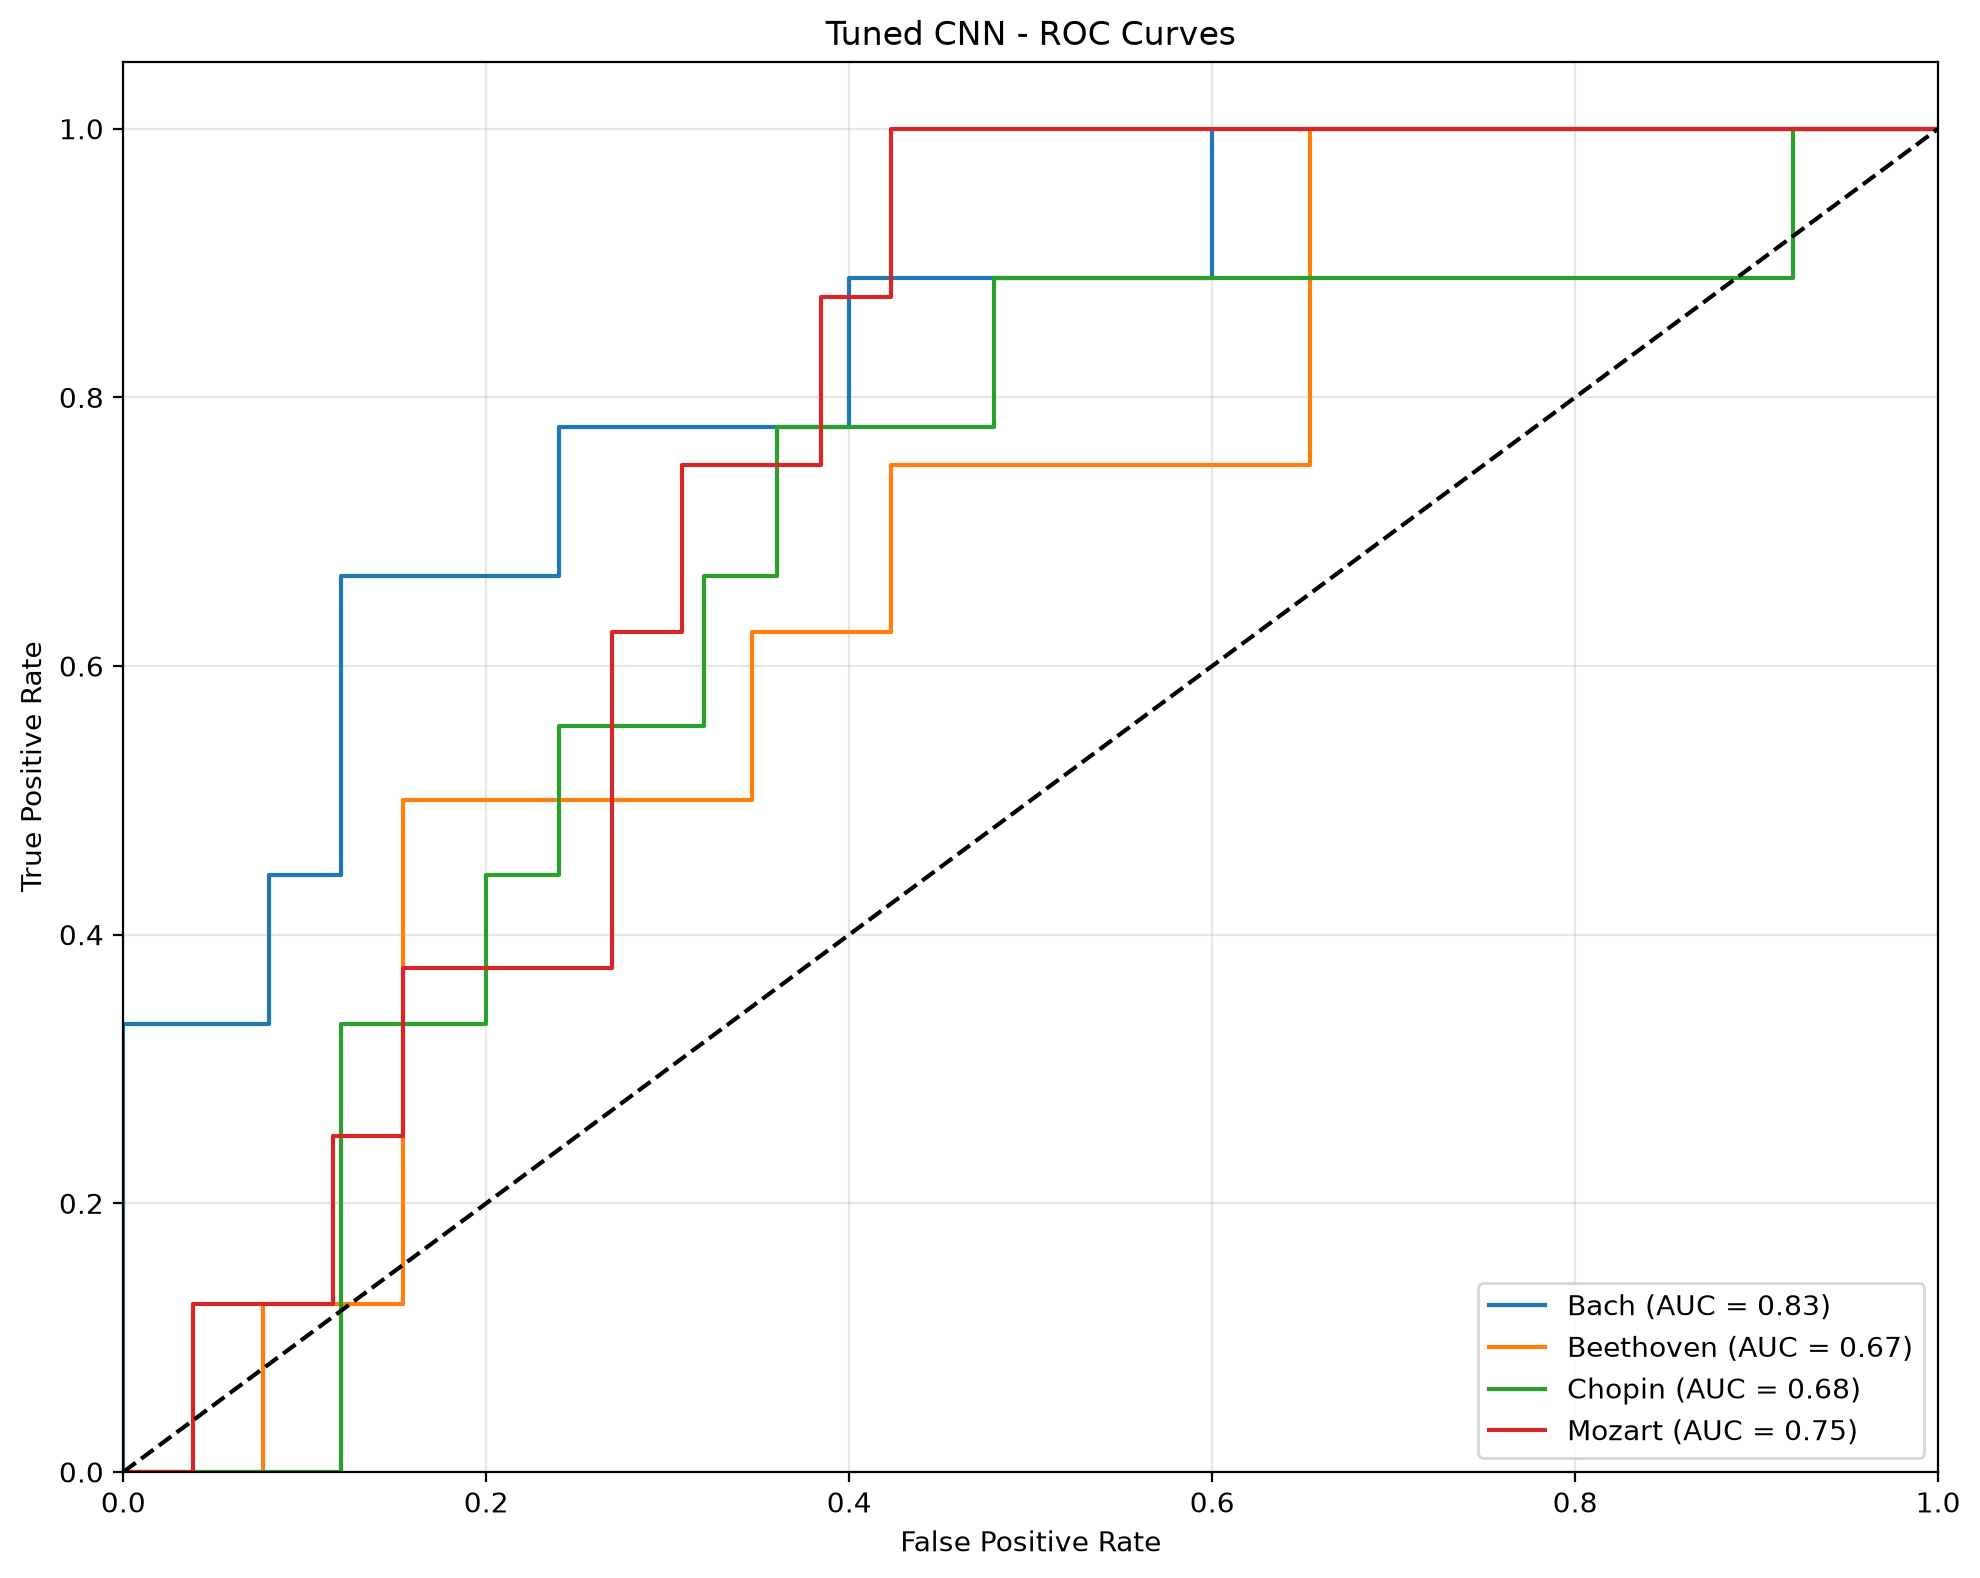

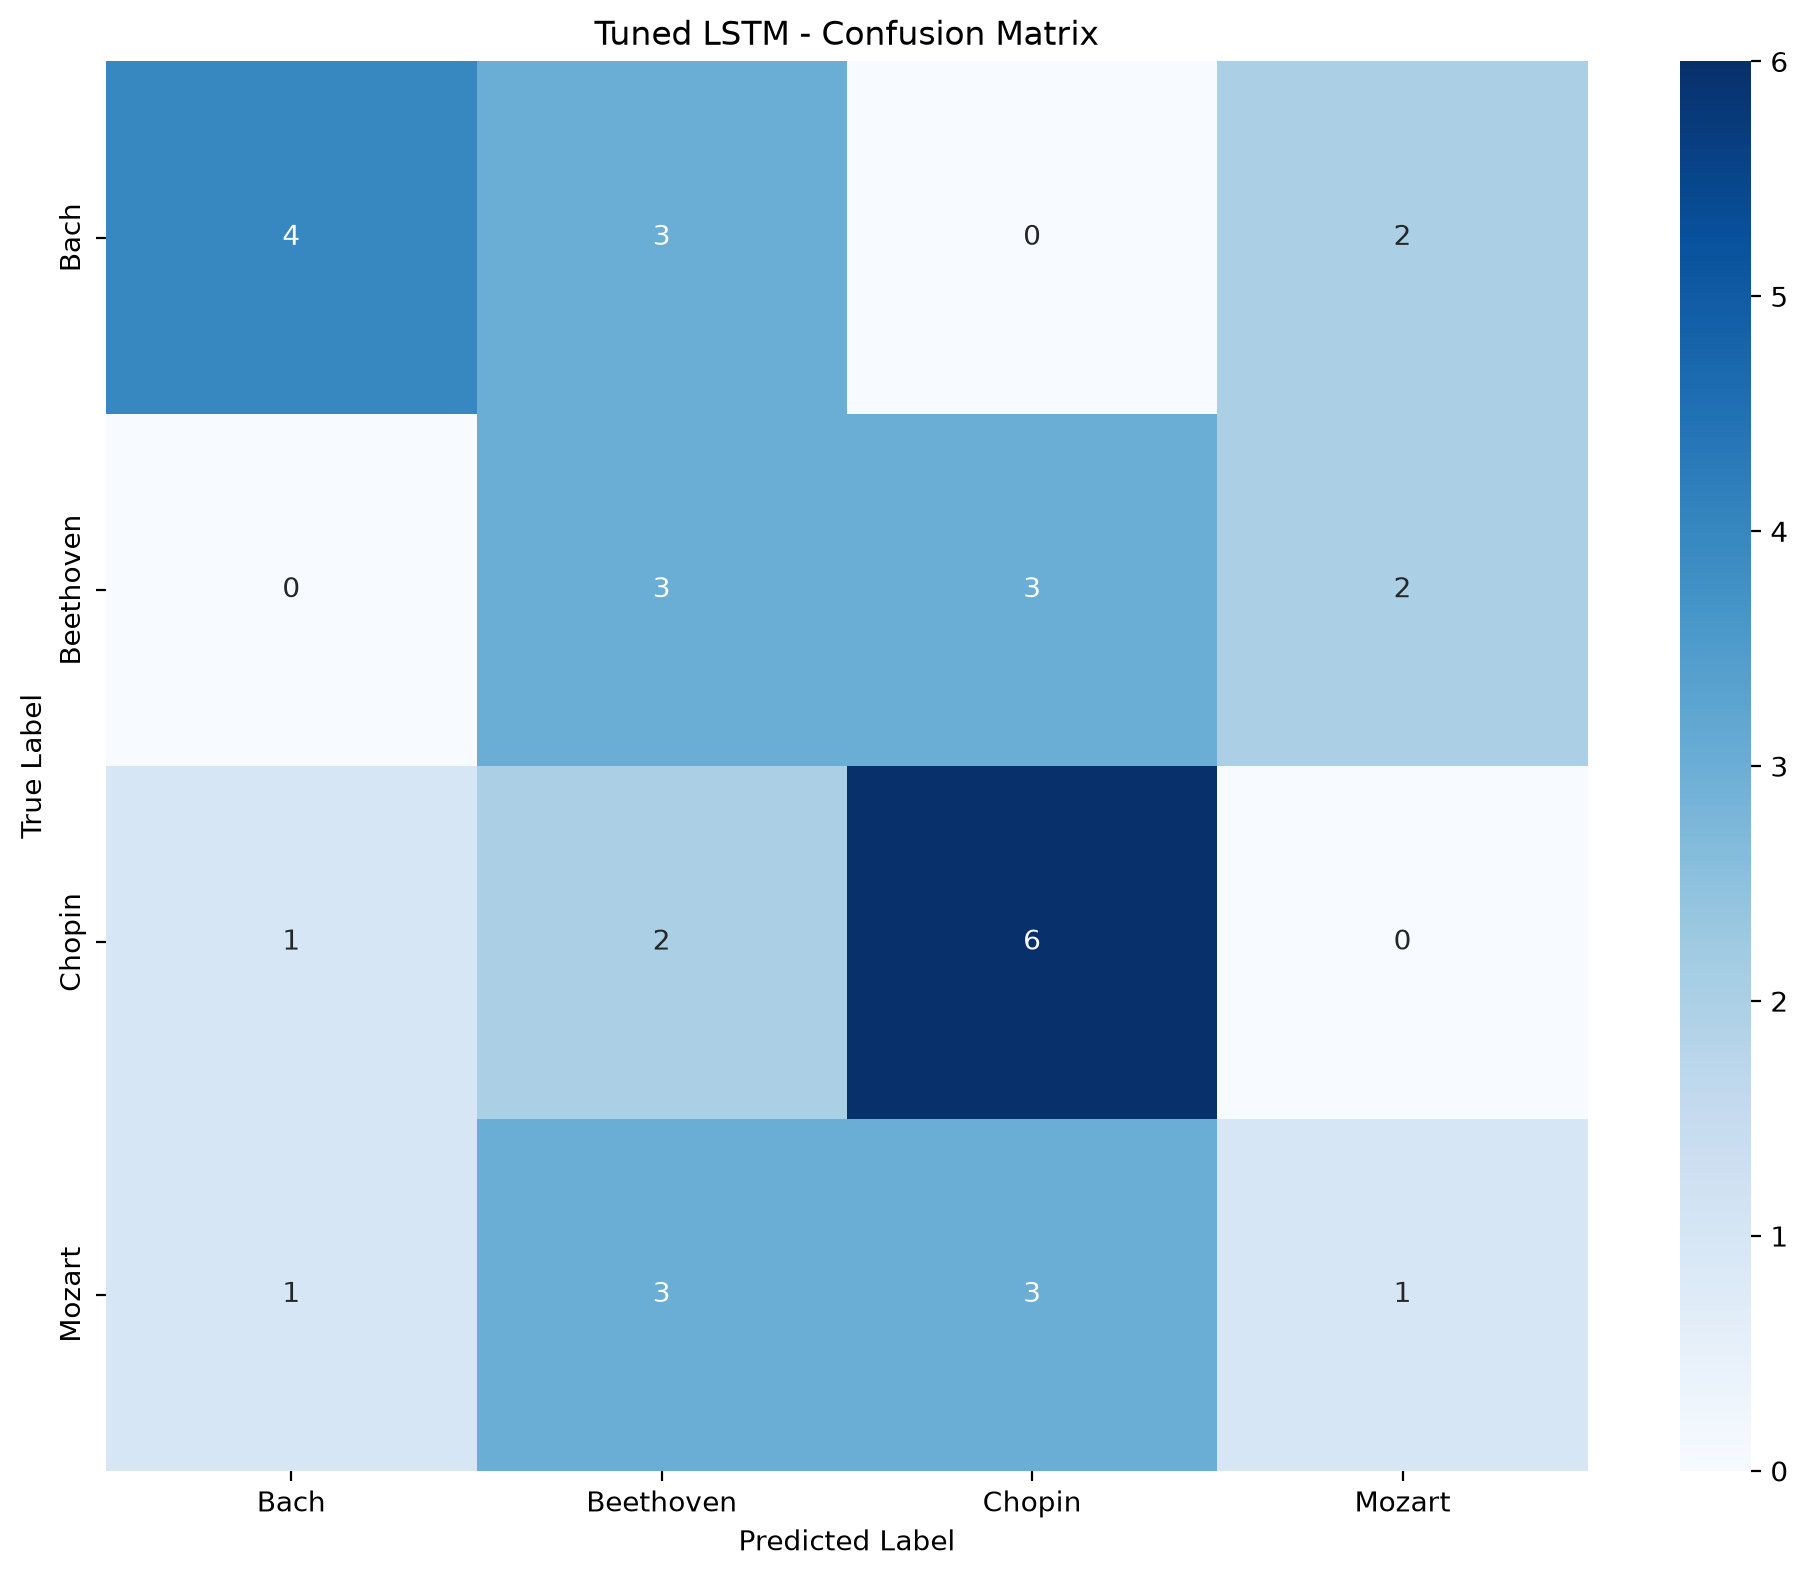

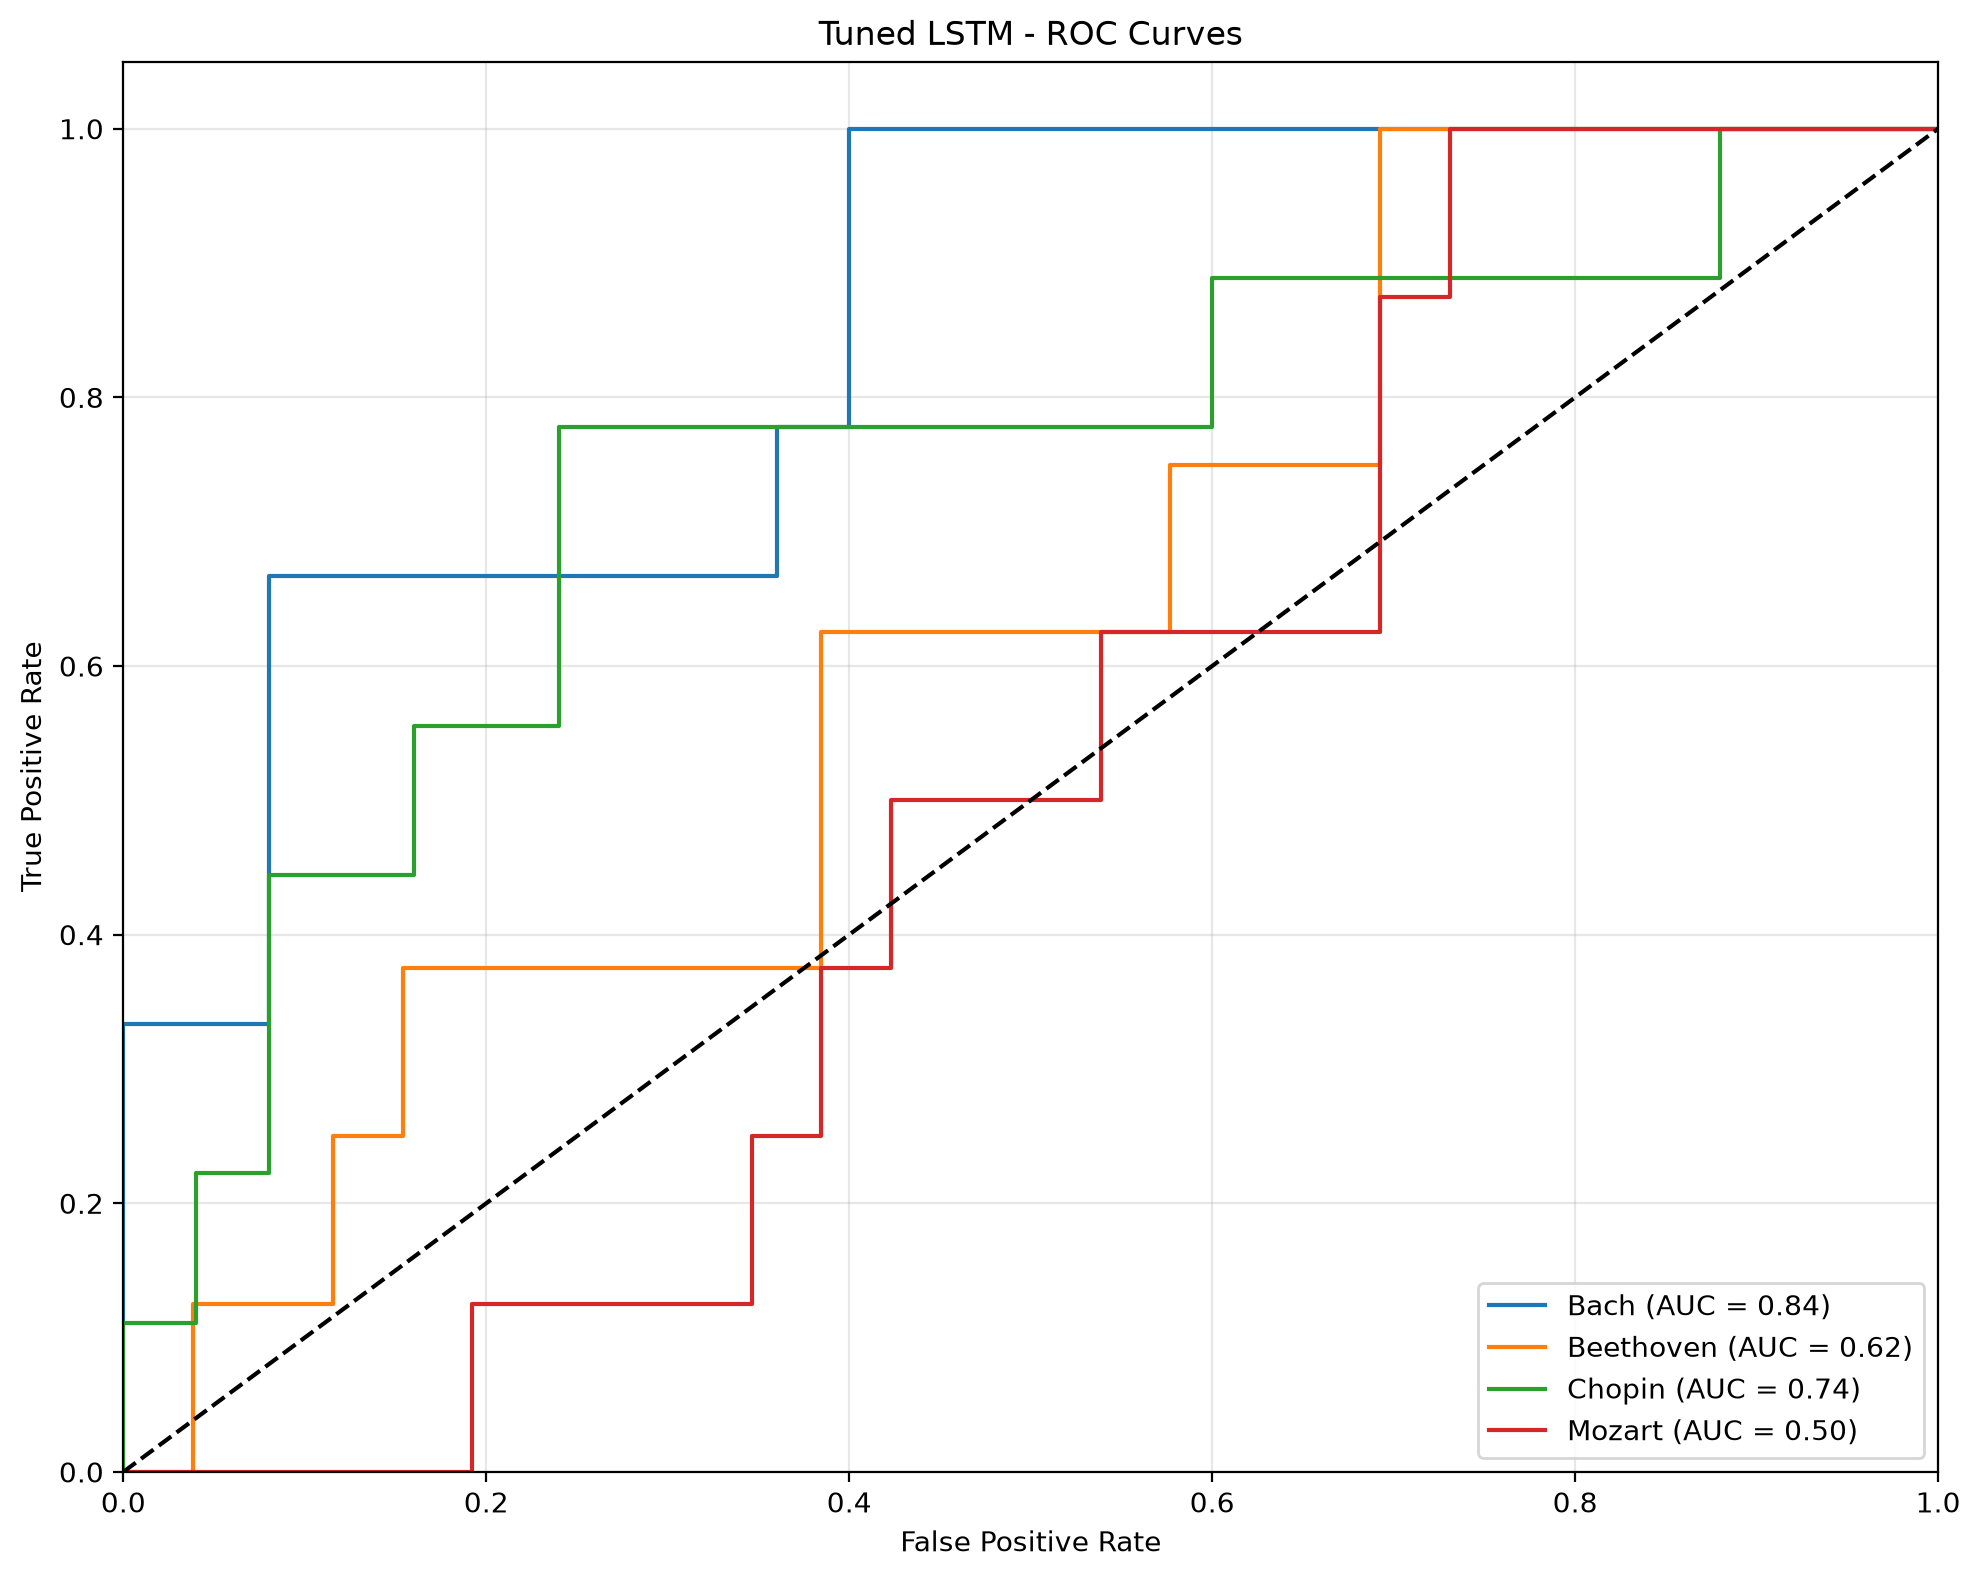

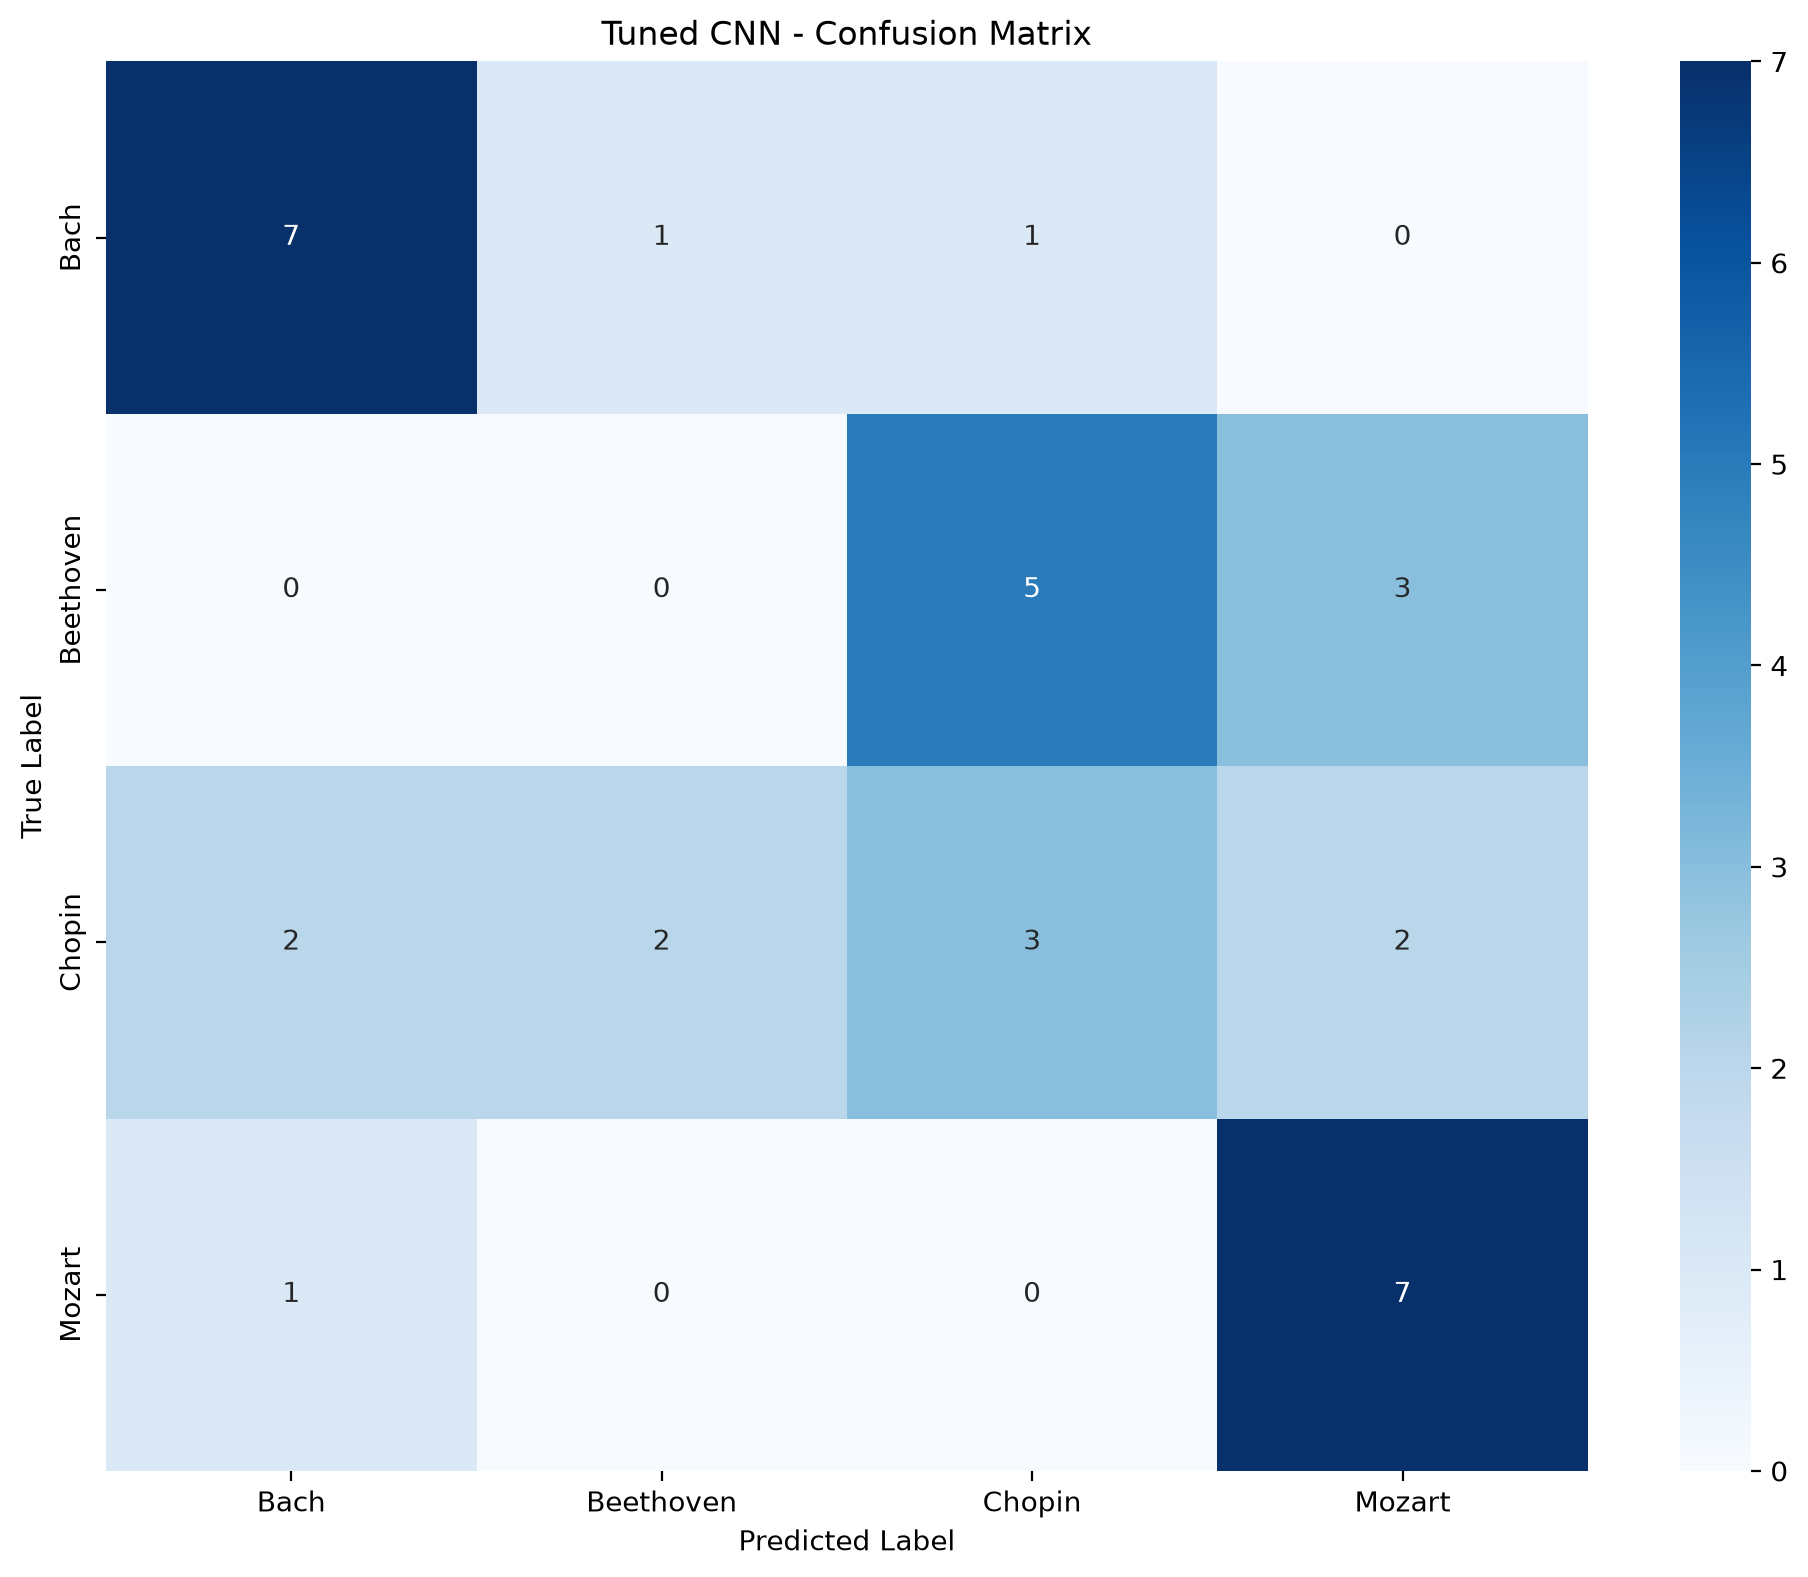

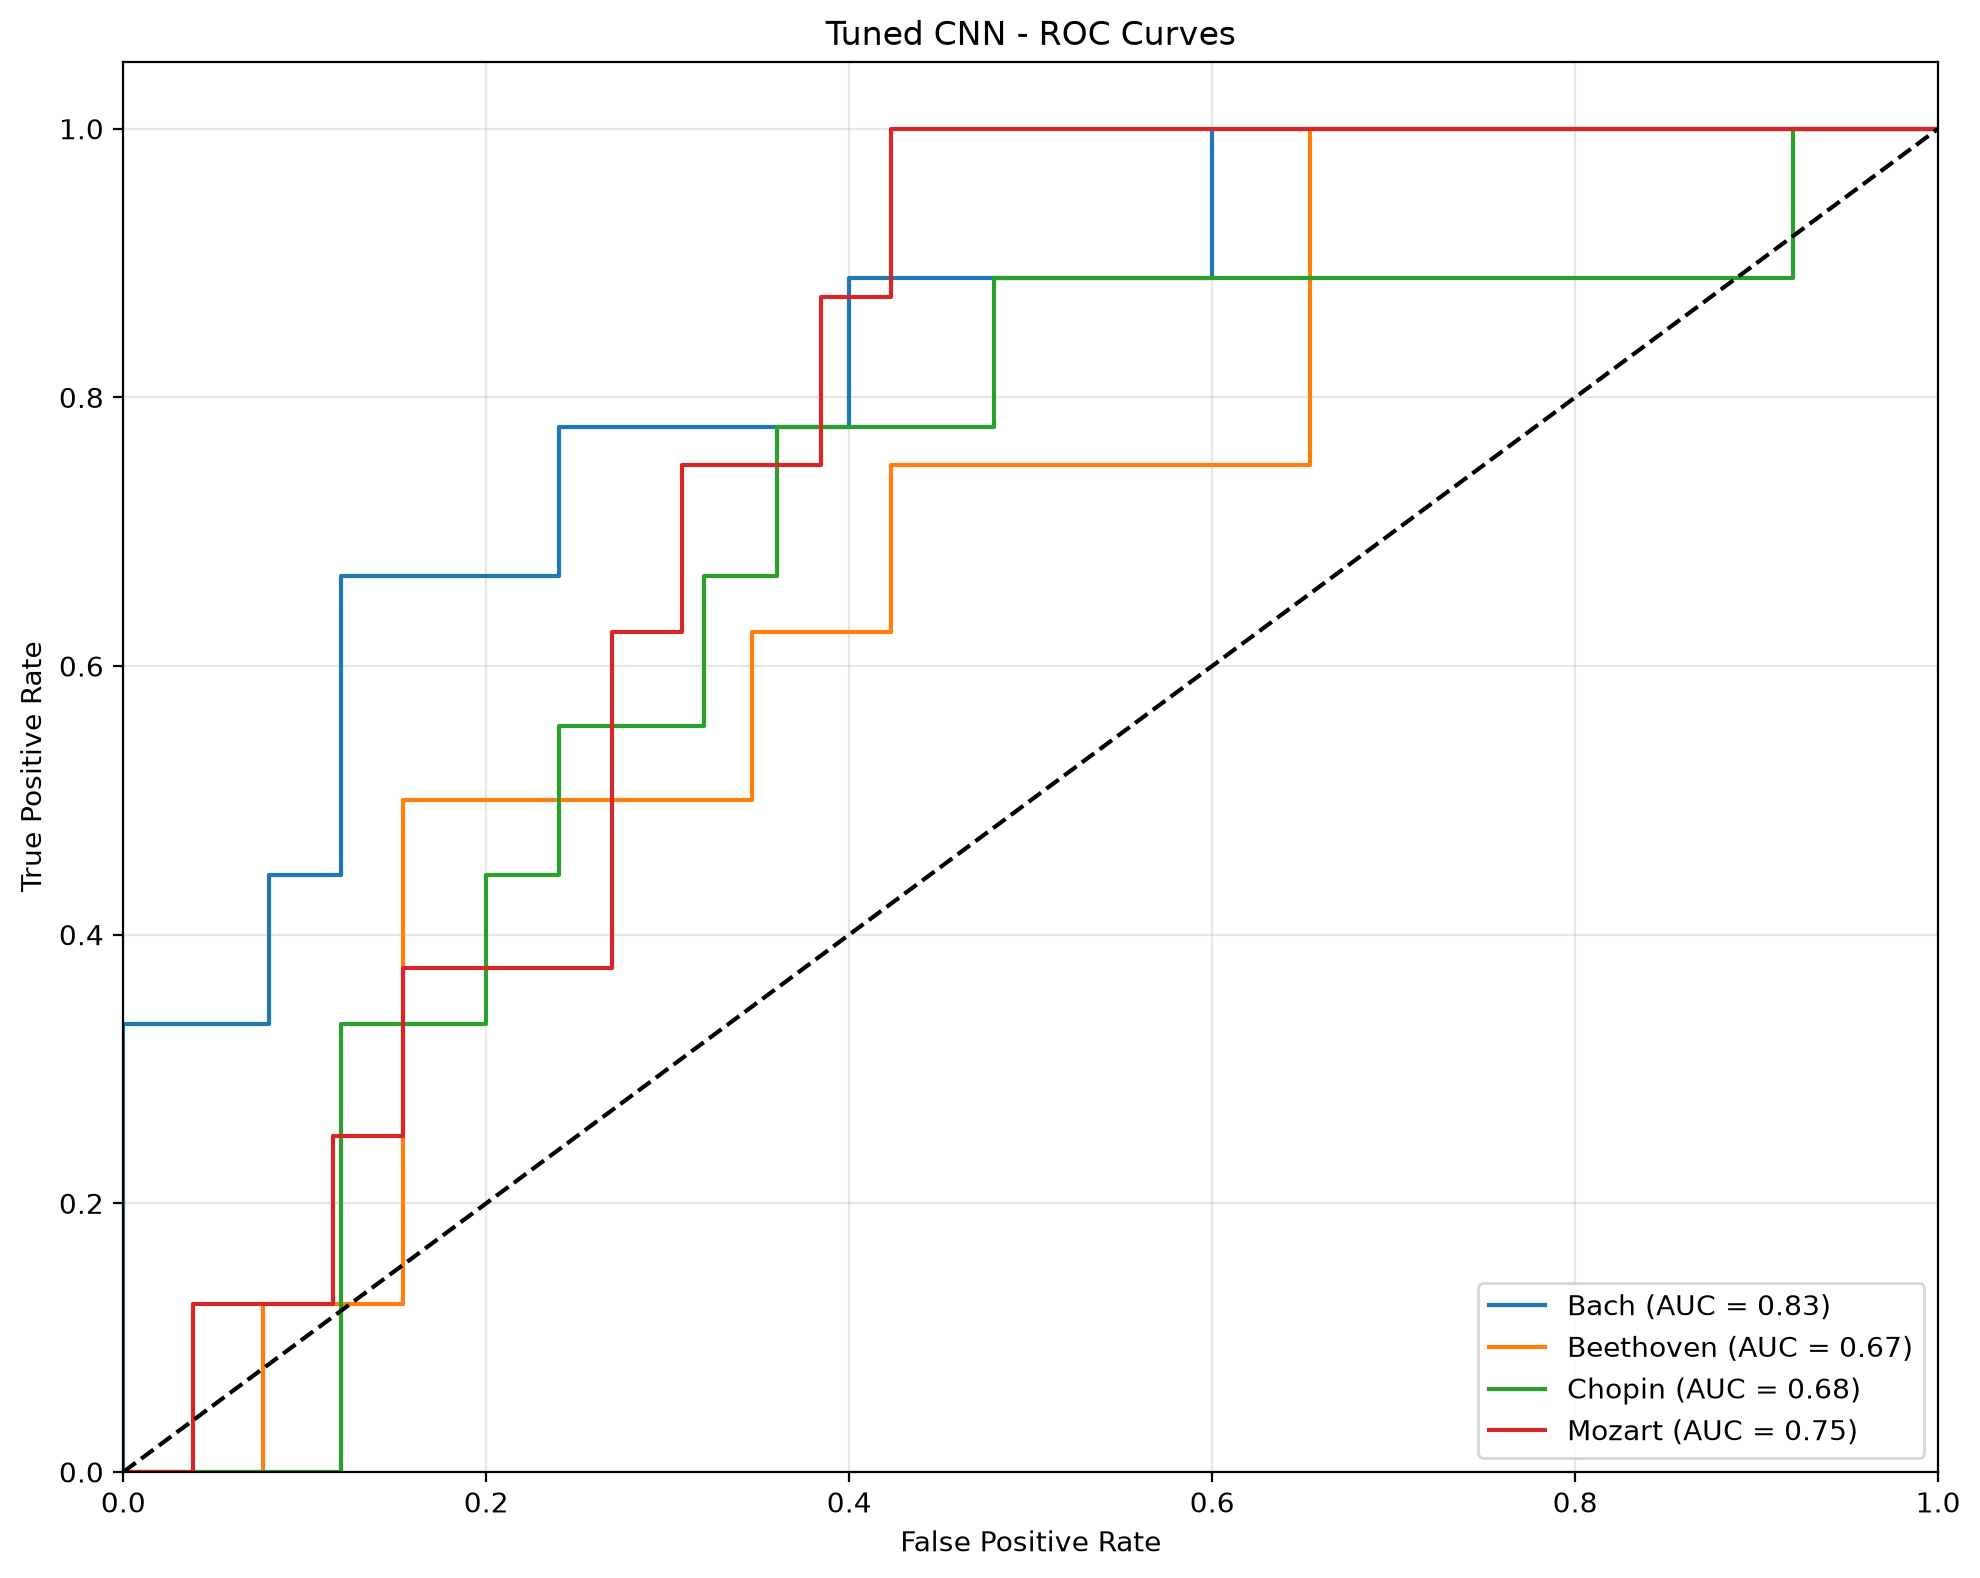

In [26]:
# Confusion matrices and ROC curves for tuned models
print("=== Tuned LSTM Evaluation ===")
tuned_lstm_evaluator.print_metrics(y_test_lstm, tuned_lstm_pred, tuned_lstm_pred_proba)
tuned_lstm_evaluator.plot_confusion_matrix(y_test_lstm, tuned_lstm_pred, "Tuned LSTM", save_fig=True)
tuned_lstm_evaluator.plot_roc_curves(y_test_lstm, tuned_lstm_pred_proba, "Tuned LSTM", save_fig=True)

print("\n=== Tuned CNN Evaluation ===")
tuned_cnn_evaluator.print_metrics(y_test_cnn, tuned_cnn_pred, tuned_cnn_pred_proba)
tuned_cnn_evaluator.plot_confusion_matrix(y_test_cnn, tuned_cnn_pred, "Tuned CNN", save_fig=True)
tuned_cnn_evaluator.plot_roc_curves(y_test_cnn, tuned_cnn_pred_proba, "Tuned CNN", save_fig=True)

Saved comparison table to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/tables/tuned_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned LSTM,0.4118,0.4201,0.4118,0.4029,0.6836
1,Tuned CNN,0.5000,0.4108,0.5000,0.4480,0.7348


Saved model comparison plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Tuned_LSTM_vs_Tuned_CNN_—_Post-Hyperparameter_Tuning.png
Saved per-class performance plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Per-Class_Performance_—_Tuned_Models.png


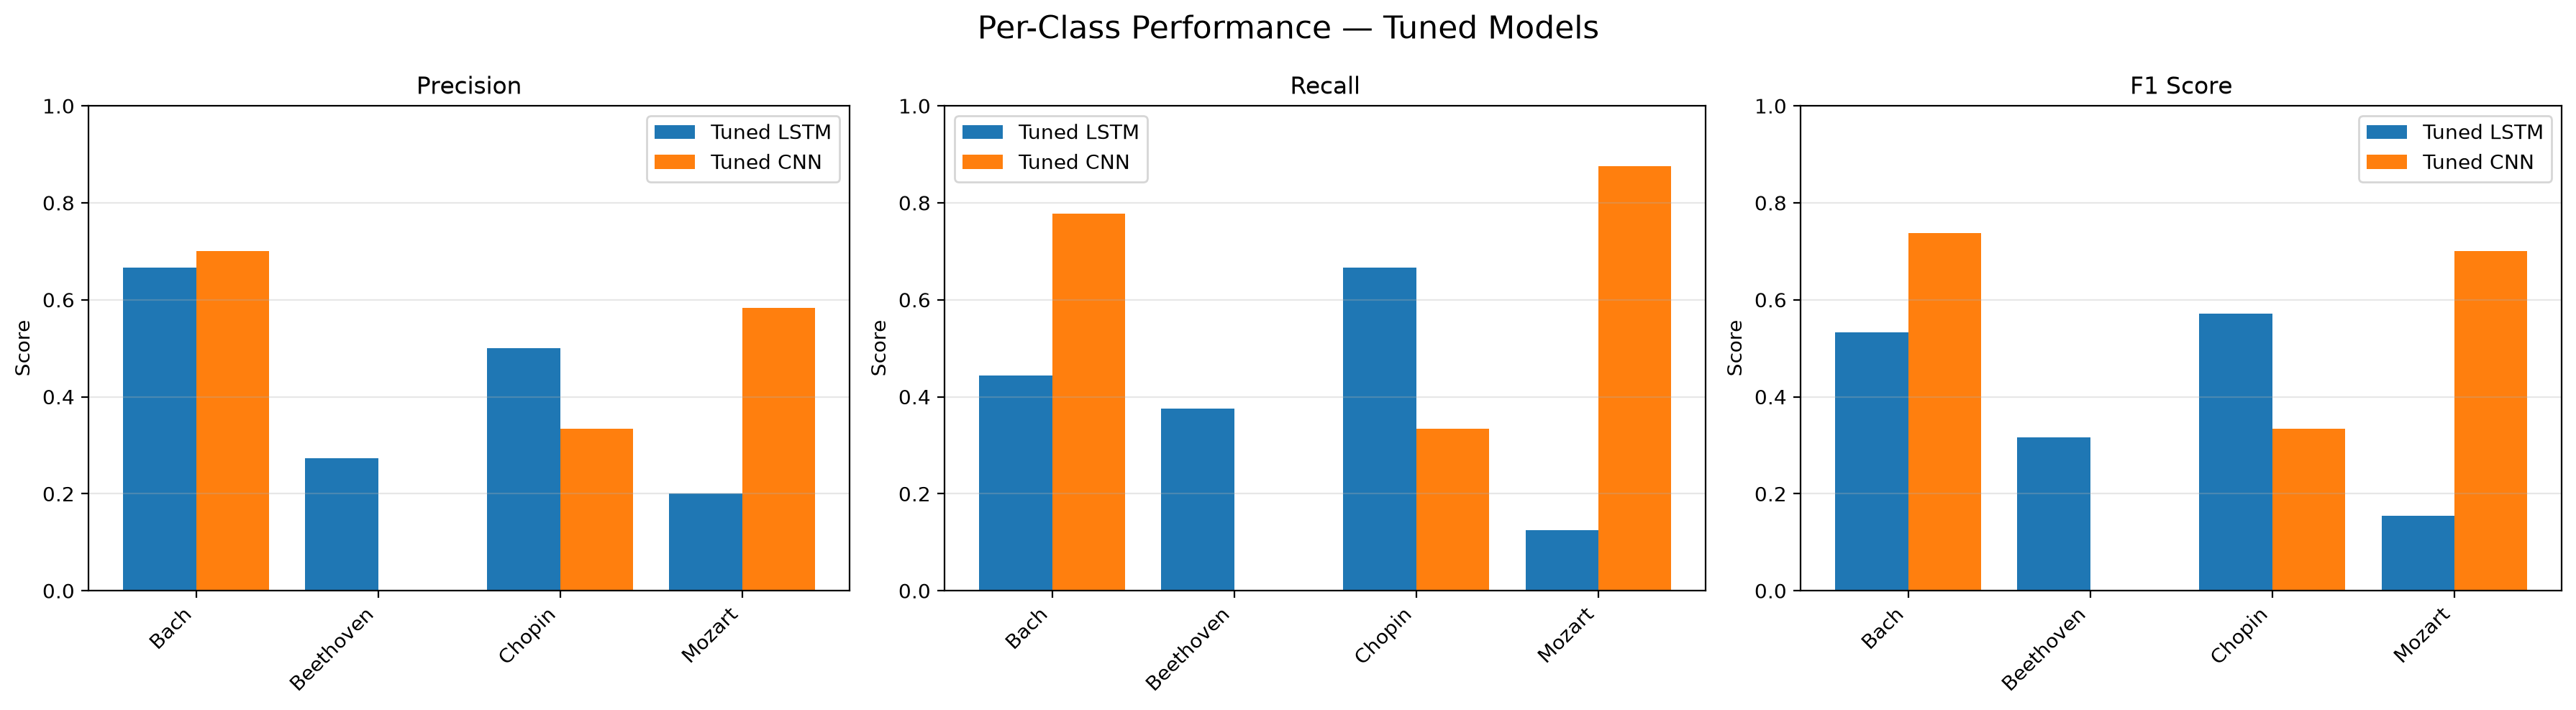

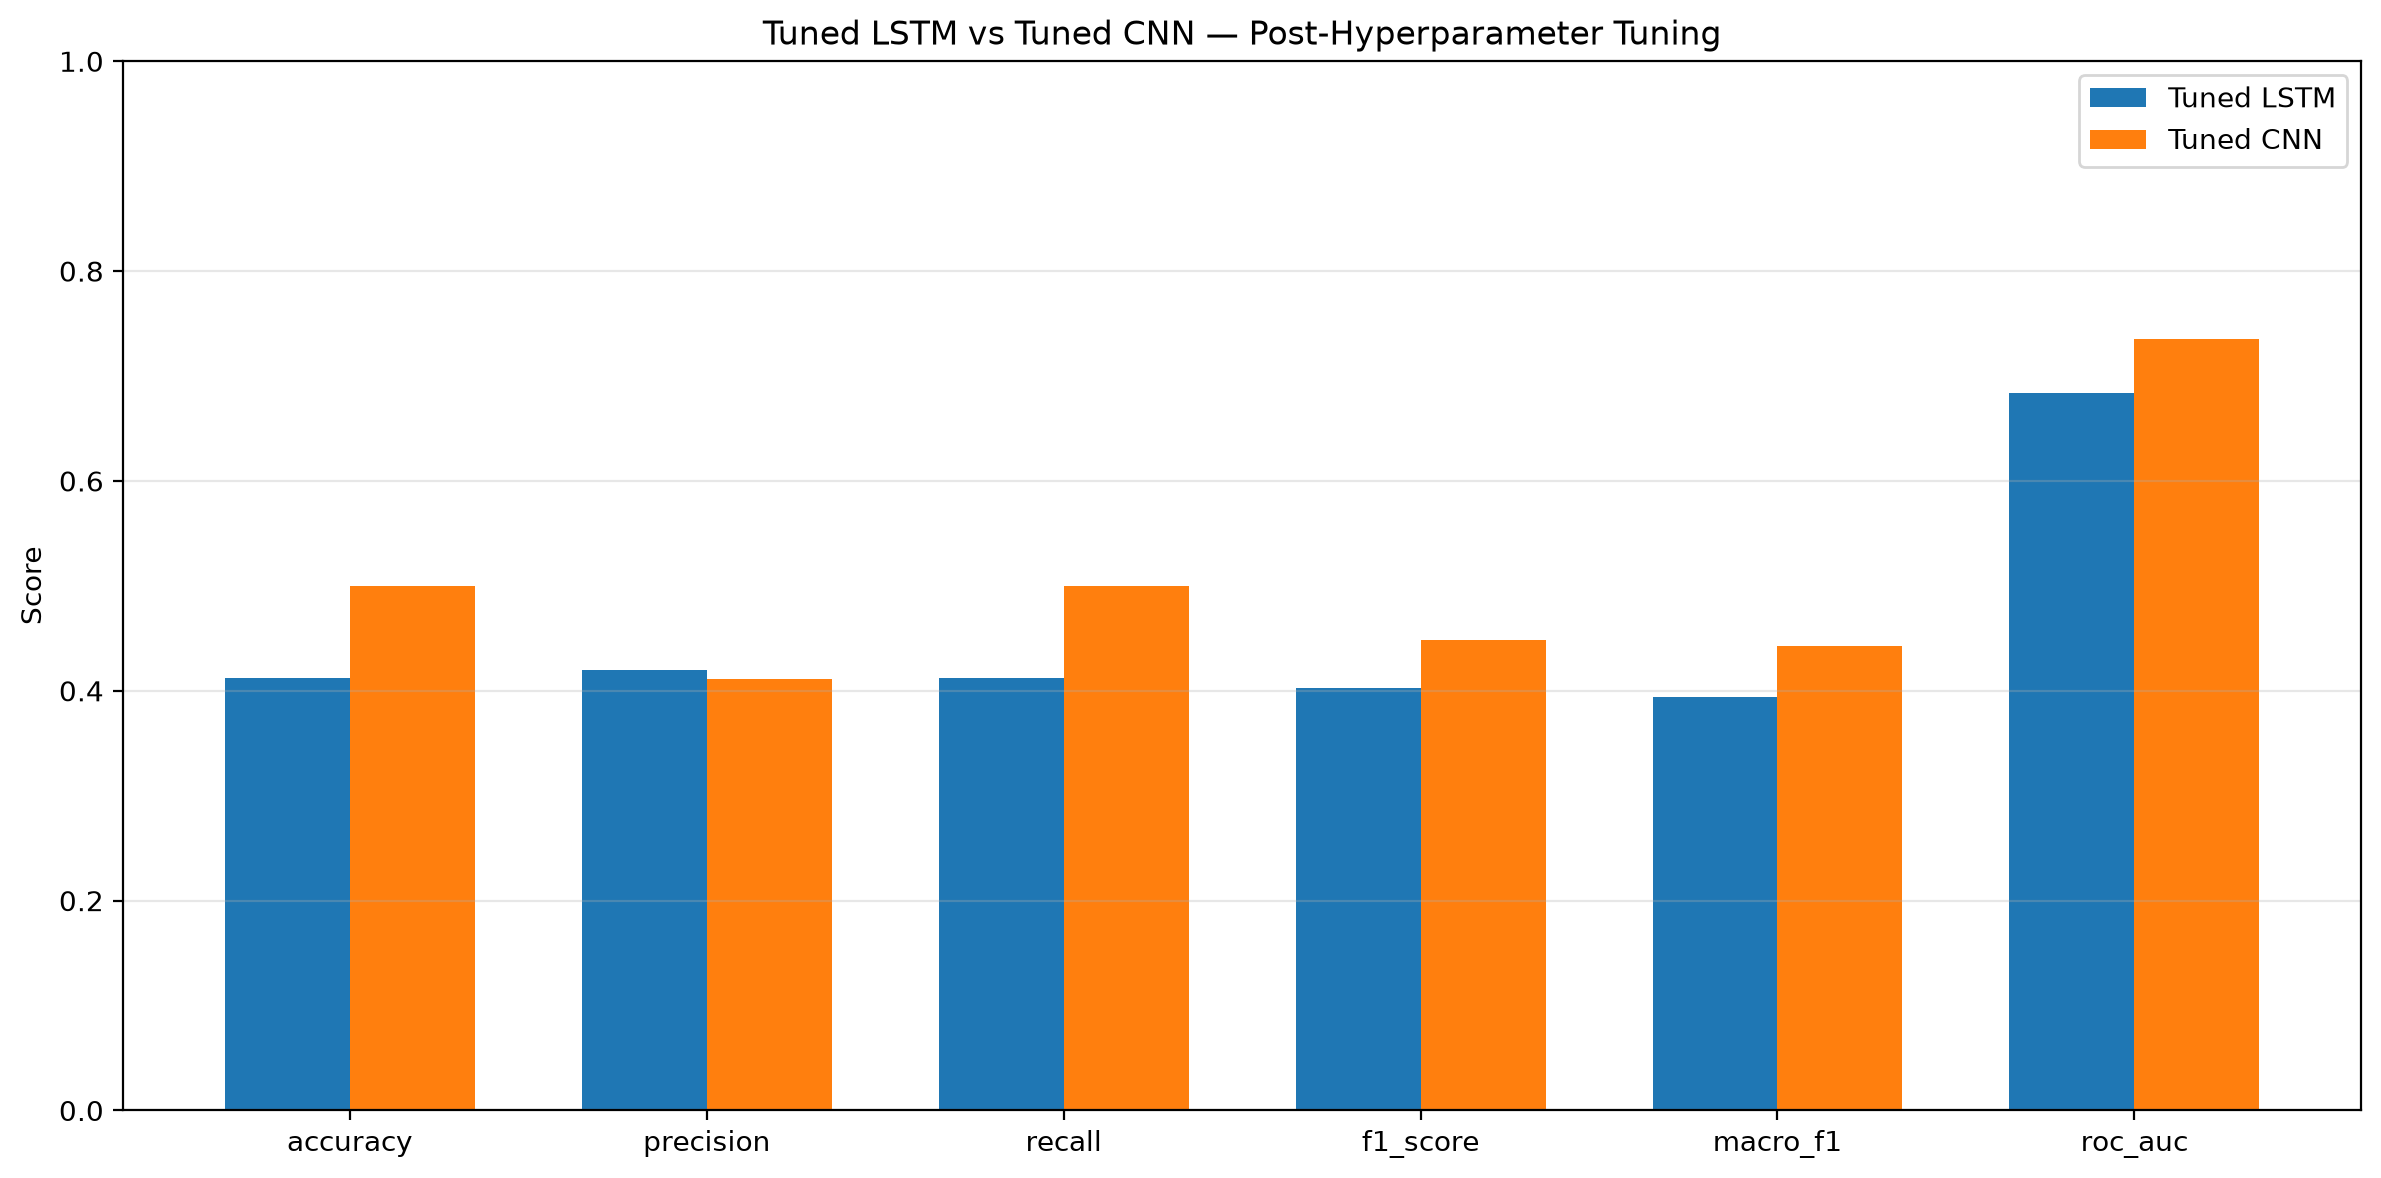

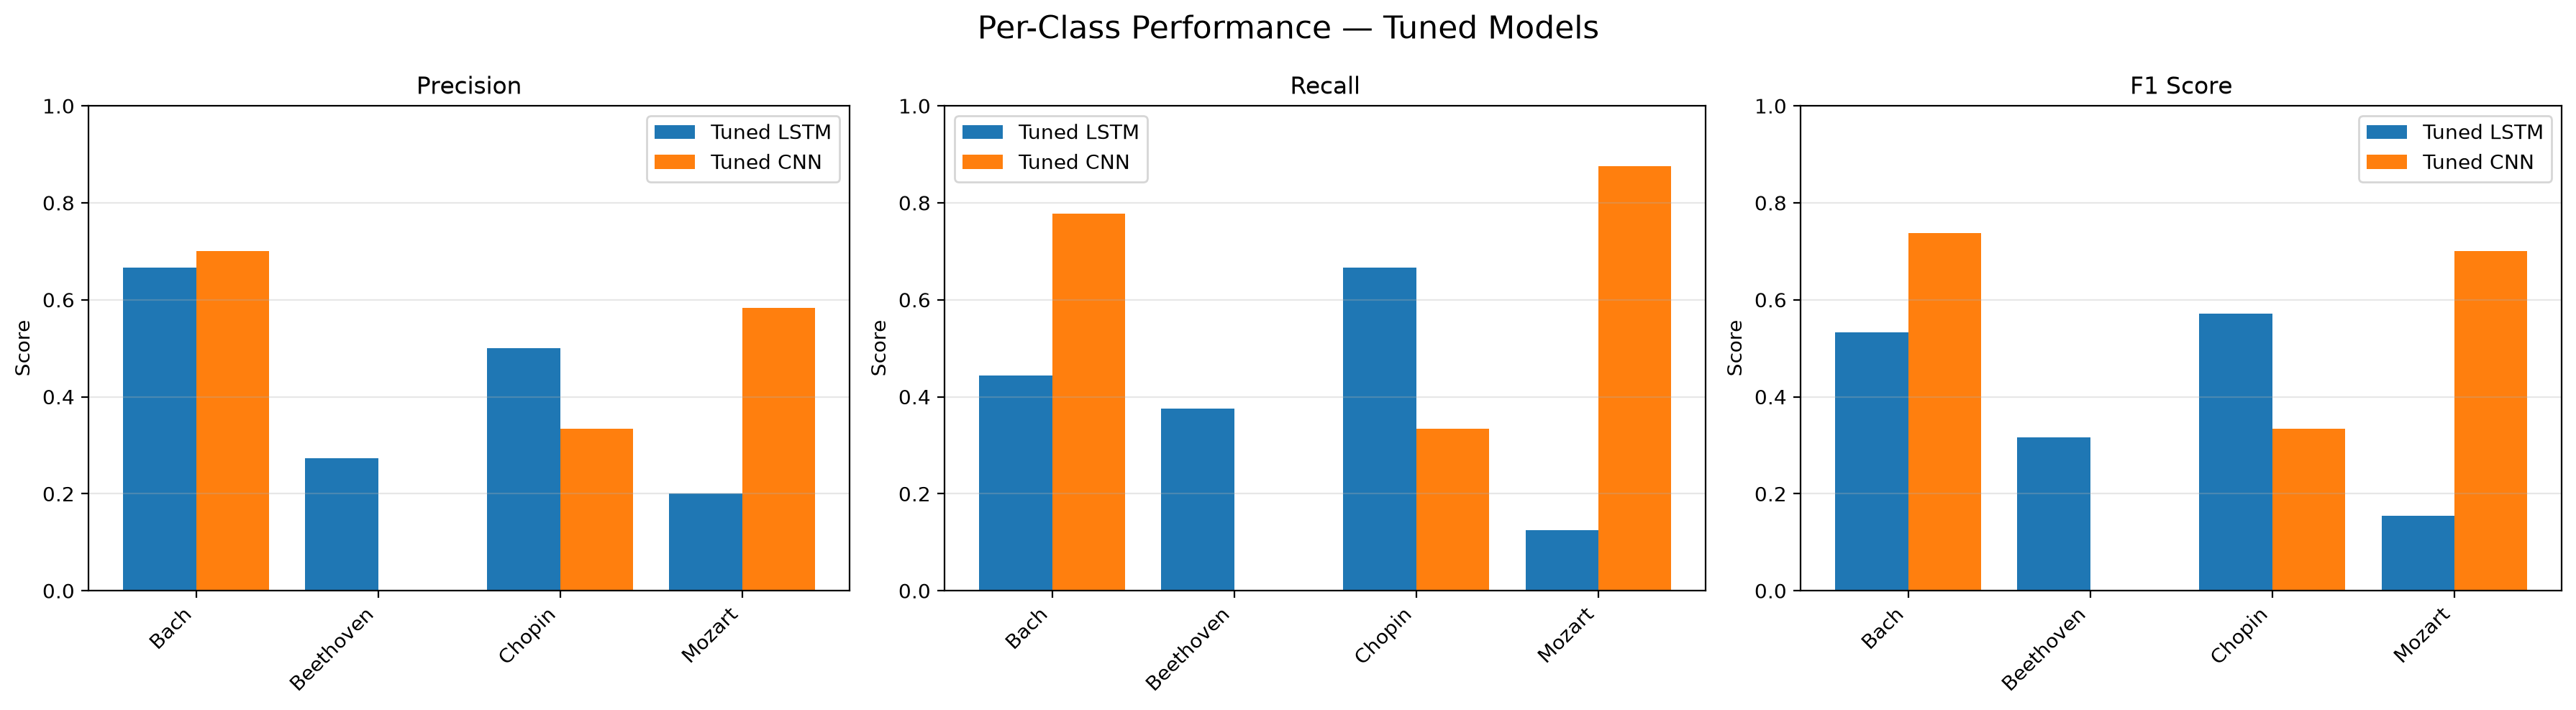

In [27]:
# Tuned model comparison — Tuned LSTM vs Tuned CNN
tuned_metrics_dict = {
    'Tuned LSTM': tuned_lstm_eval,
    'Tuned CNN': tuned_cnn_eval
}

tuned_visualizer = ModelVisualizer(COMPOSERS)
tuned_comparison = tuned_visualizer.create_comparison_table(
    tuned_metrics_dict,
    save_path='tuned_model_comparison.csv'
)
display(tuned_comparison)

# Bar chart comparison
tuned_visualizer.plot_model_comparison(
    tuned_metrics_dict,
    "Tuned LSTM vs Tuned CNN — Post-Hyperparameter Tuning",
    save_fig=True
)

# Per-class performance
tuned_visualizer.plot_per_class_performance(
    tuned_metrics_dict,
    "Per-Class Performance — Tuned Models",
    save_fig=True
)

In [28]:
# Before vs After Tuning — side-by-side comparison table
compare_keys = ['test_accuracy', 'precision', 'recall', 'f1_score', 'macro_f1']

comparison_data = {
    'Metric': [k.replace('_', ' ').title() for k in compare_keys],
    'LSTM (Default)': [baseline_lstm_metrics.get(k, 0) for k in compare_keys],
    'LSTM (Tuned)':   [lstm_metrics.get(k, 0) for k in compare_keys],
    'CNN (Default)':  [baseline_cnn_metrics.get(k, 0) for k in compare_keys],
    'CNN (Tuned)':    [cnn_metrics.get(k, 0) for k in compare_keys],
}
comparison_df = pd.DataFrame(comparison_data)

print("Before vs After Hyperparameter Tuning:\n")
display(comparison_df.style.format({
    'LSTM (Default)': '{:.4f}', 'LSTM (Tuned)': '{:.4f}',
    'CNN (Default)': '{:.4f}',  'CNN (Tuned)': '{:.4f}'
}).highlight_max(axis=1, subset=['LSTM (Default)', 'LSTM (Tuned)', 'CNN (Default)', 'CNN (Tuned)']))

# Save comparison table
comparison_df.to_csv(TABLES_DIR / 'before_vs_after_tuning.csv', index=False)
print(f"\nSaved to {TABLES_DIR / 'before_vs_after_tuning.csv'}")

Before vs After Hyperparameter Tuning:



,Metric,LSTM (Default),LSTM (Tuned),CNN (Default),CNN (Tuned)
0,Test Accuracy,0.0000,0.4118,0.0000,0.5000
1,Precision,0.4201,0.4201,0.2224,0.4108
2,Recall,0.4118,0.4118,0.3824,0.5000
3,F1 Score,0.4029,0.4029,0.2611,0.4480
4,Macro F1,0.3936,0.3936,0.2601,0.4425



Saved to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/tables/before_vs_after_tuning.csv


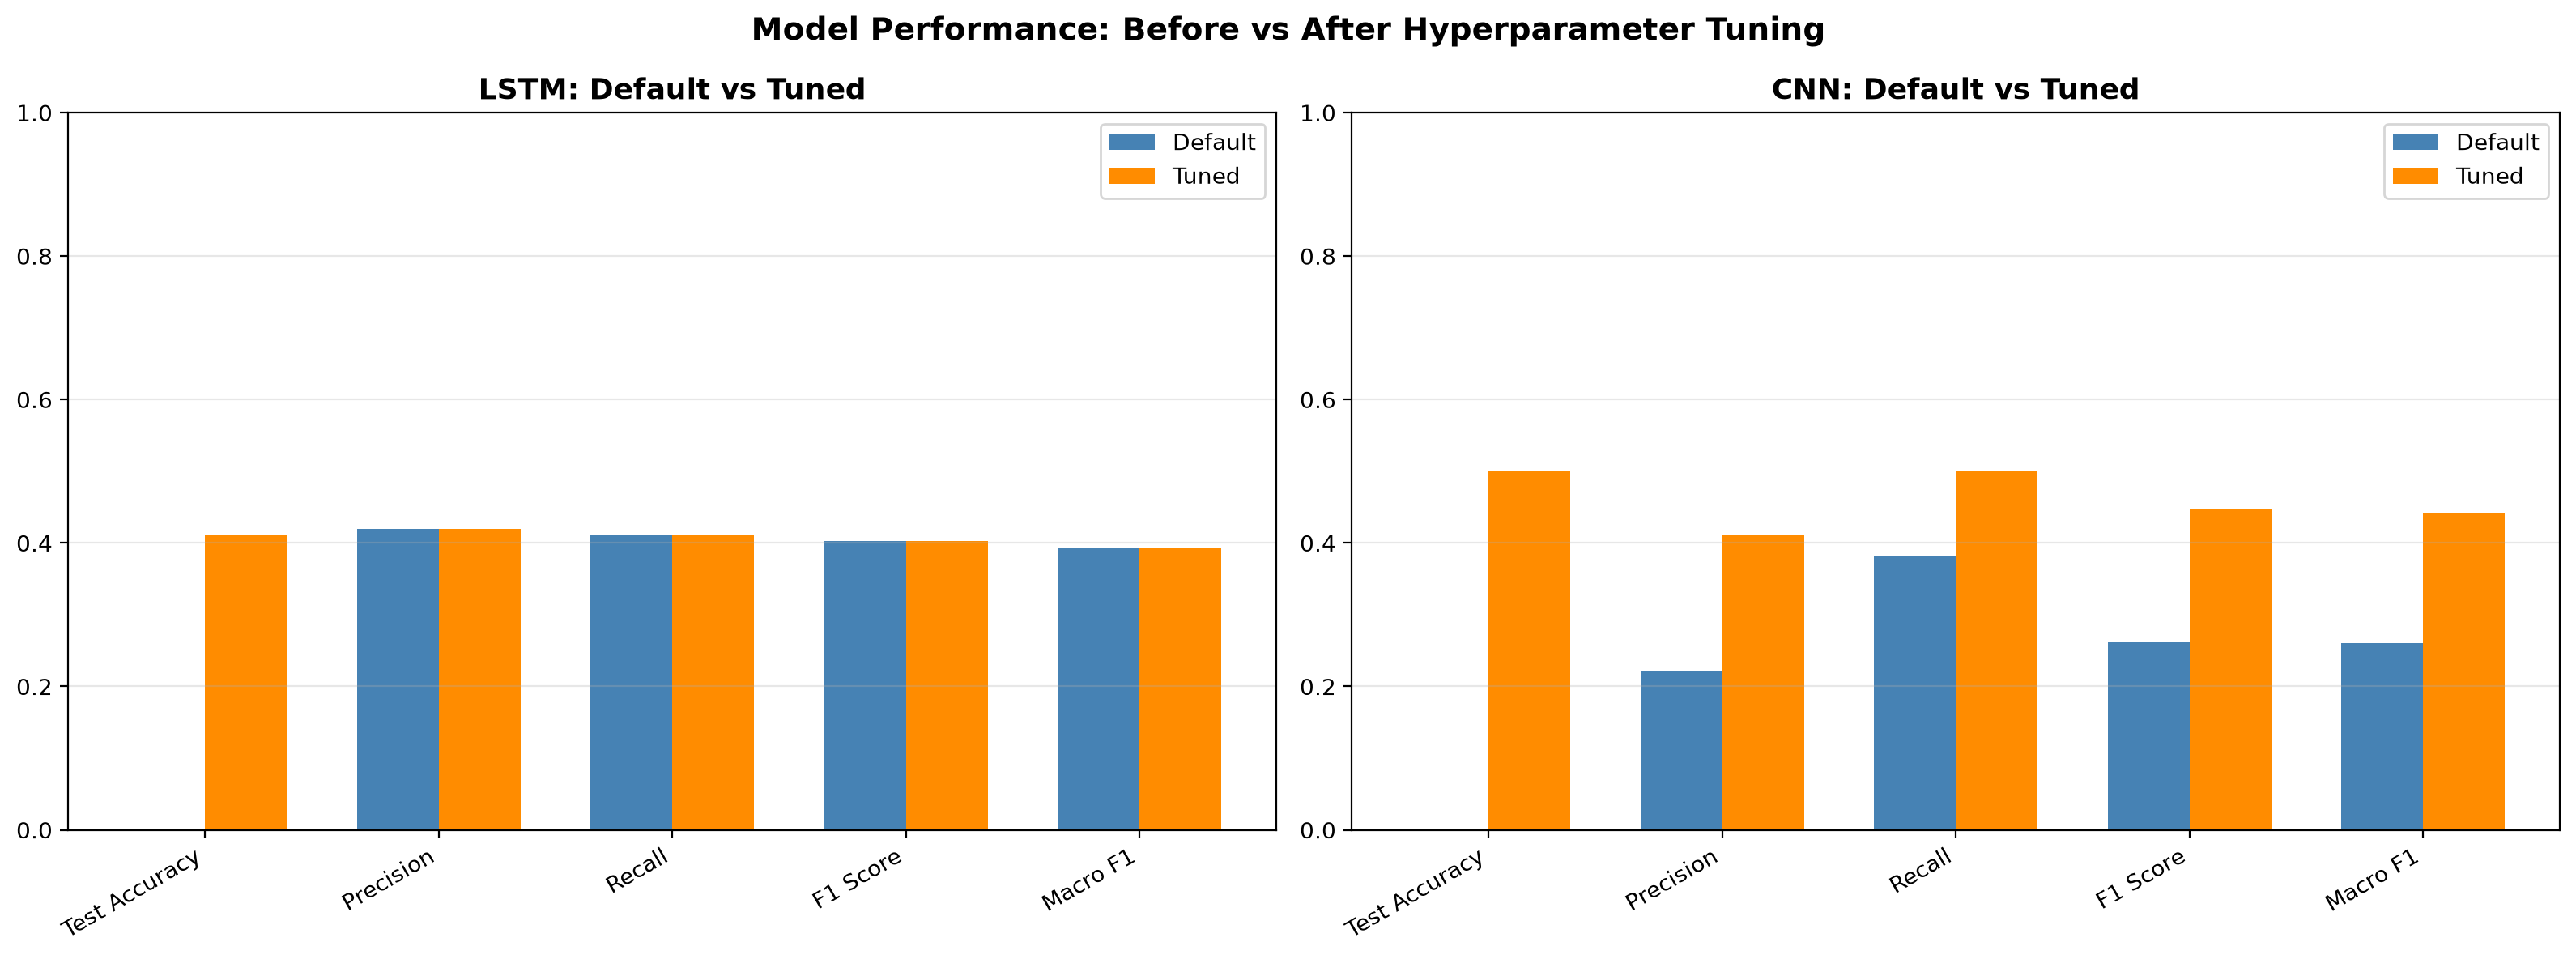

In [29]:
# Bar chart: Default vs Tuned for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(compare_keys))
w = 0.35
labels = [k.replace('_', ' ').title() for k in compare_keys]

# LSTM: Default vs Tuned
axes[0].bar(x - w/2, [baseline_lstm_metrics.get(k, 0) for k in compare_keys], w,
            label='Default', color='steelblue')
axes[0].bar(x + w/2, [lstm_metrics.get(k, 0) for k in compare_keys], w,
            label='Tuned', color='darkorange')
axes[0].set_title('LSTM: Default vs Tuned', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# CNN: Default vs Tuned
axes[1].bar(x - w/2, [baseline_cnn_metrics.get(k, 0) for k in compare_keys], w,
            label='Default', color='steelblue')
axes[1].bar(x + w/2, [cnn_metrics.get(k, 0) for k in compare_keys], w,
            label='Tuned', color='darkorange')
axes[1].set_title('CNN: Default vs Tuned', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance: Before vs After Hyperparameter Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'before_vs_after_tuning.png', dpi=FIGURE_DPI)
plt.show()

## 11. Enhanced Tuning: Optuna + Data Augmentation + Class Weights

This section implements three key improvements over the baseline grid search approach:

1. **Optuna Bayesian Optimization** — Replaces exhaustive grid search with intelligent, pruning-aware hyperparameter search (TPE sampler + MedianPruner)
2. **Data Augmentation** — Wires in the existing `MIDIAugmentation` pipeline (pitch shift, tempo scaling, velocity variation) to expand the training set at the MIDI level
3. **Class Weights** — Uses `sklearn.utils.class_weight.compute_class_weight('balanced')` instead of undersampling, preserving all available training data

In [30]:
import optuna
from copy import deepcopy
from tqdm import tqdm
import pretty_midi
from sklearn.utils.class_weight import compute_class_weight
from src.preprocessing.augmentation import MIDIAugmentation
from src.features.note_features import extract_note_features
from src.features.piano_roll import extract_piano_roll
from src.models import create_lstm_model, create_cnn_model
from src.training.train_lstm import LSTMTrainer
from src.training.train_cnn import CNNTrainer

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- 1. Compute class weights from the FULL unbalanced cleaned dataset ---
# Re-clean WITHOUT undersampling to preserve all data
print("Re-cleaning dataset WITHOUT undersampling (using class weights instead)...")
full_cleaned_df = clean_dataset(
    metadata_path=METADATA_FILE,
    min_notes=MIN_NOTES,
    min_duration=1.0,
    max_duration=600.0,
    balance=False,
    output_path=None
)

full_train_df, full_val_df, full_test_df = split_dataset(
    full_cleaned_df,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
    stratified=True,
    output_dir=None
)

print(f"\nFull dataset (no undersampling): {len(full_cleaned_df)} files")
print(f"  Train: {len(full_train_df)}, Val: {len(full_val_df)}, Test: {len(full_test_df)}")
print(f"  Train class distribution:")
for composer in COMPOSERS:
    n = len(full_train_df[full_train_df['composer'] == composer])
    print(f"    {composer}: {n}")

# Compute class weights
train_labels = full_train_df['label'].values
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights: {class_weight_dict}")

# --- 2. Build augmented training set (LSTM features) ---
print("\nBuilding augmented LSTM training set...")
augmenter = MIDIAugmentation()
AUGMENT_FACTOR = 1  # 1 augmented copy per original (2x total) for speed

aug_lstm_features = []
aug_lstm_labels = []

for idx, row in tqdm(full_train_df.iterrows(), total=len(full_train_df), desc="Augmenting LSTM"):
    filepath = Path(row['filepath'])
    if not filepath.exists():
        continue
    try:
        midi = pretty_midi.PrettyMIDI(str(filepath))
        # Original
        feats = extract_note_features(midi, feature_type='combined',
                                       sequence_length=SEQUENCE_LENGTH, normalize=True)
        aug_lstm_features.append(feats)
        aug_lstm_labels.append(row['label'])
        # Augmented copies
        for _ in range(AUGMENT_FACTOR):
            aug_midi = augmenter.apply_random_augmentation(midi)
            aug_feats = extract_note_features(aug_midi, feature_type='combined',
                                               sequence_length=SEQUENCE_LENGTH, normalize=True)
            aug_lstm_features.append(aug_feats)
            aug_lstm_labels.append(row['label'])
    except Exception as e:
        continue

X_train_aug_lstm = np.array(aug_lstm_features)
y_train_aug_lstm = np.array(aug_lstm_labels)
print(f"Augmented LSTM training set: {X_train_aug_lstm.shape} (was {X_train_lstm.shape})")

# --- 3. Build augmented training set (CNN features) ---
print("\nBuilding augmented CNN training set...")
aug_cnn_features = []
aug_cnn_labels = []

for idx, row in tqdm(full_train_df.iterrows(), total=len(full_train_df), desc="Augmenting CNN"):
    filepath = Path(row['filepath'])
    if not filepath.exists():
        continue
    try:
        midi = pretty_midi.PrettyMIDI(str(filepath))
        # Original
        feats = extract_piano_roll(midi, roll_type='velocity',
                                    time_steps=MAX_TIME_STEPS, pitch_range=PITCH_RANGE, fps=20.0)
        aug_cnn_features.append(feats)
        aug_cnn_labels.append(row['label'])
        # Augmented copies
        for _ in range(AUGMENT_FACTOR):
            aug_midi = augmenter.apply_random_augmentation(midi)
            aug_feats = extract_piano_roll(aug_midi, roll_type='velocity',
                                            time_steps=MAX_TIME_STEPS, pitch_range=PITCH_RANGE, fps=20.0)
            aug_cnn_features.append(aug_feats)
            aug_cnn_labels.append(row['label'])
    except Exception as e:
        continue

X_train_aug_cnn = np.array(aug_cnn_features)
y_train_aug_cnn = np.array(aug_cnn_labels)
if X_train_aug_cnn.ndim == 3:
    X_train_aug_cnn = X_train_aug_cnn[..., np.newaxis]
print(f"Augmented CNN training set: {X_train_aug_cnn.shape} (was {X_train_cnn.shape})")

# --- 4. Build val/test from full (unbalanced) split ---
# Val set (LSTM)
val_lstm_feats, val_lstm_labs = [], []
for idx, row in tqdm(full_val_df.iterrows(), total=len(full_val_df), desc="Val LSTM"):
    fp = Path(row['filepath'])
    if not fp.exists(): continue
    try:
        m = pretty_midi.PrettyMIDI(str(fp))
        val_lstm_feats.append(extract_note_features(m, 'combined', SEQUENCE_LENGTH, True))
        val_lstm_labs.append(row['label'])
    except: continue
X_val_aug_lstm = np.array(val_lstm_feats)
y_val_aug_lstm = np.array(val_lstm_labs)

# Val set (CNN)
val_cnn_feats, val_cnn_labs = [], []
for idx, row in tqdm(full_val_df.iterrows(), total=len(full_val_df), desc="Val CNN"):
    fp = Path(row['filepath'])
    if not fp.exists(): continue
    try:
        m = pretty_midi.PrettyMIDI(str(fp))
        val_cnn_feats.append(extract_piano_roll(m, 'velocity', MAX_TIME_STEPS, PITCH_RANGE, 20.0))
        val_cnn_labs.append(row['label'])
    except: continue
X_val_aug_cnn = np.array(val_cnn_feats)
y_val_aug_cnn = np.array(val_cnn_labs)
if X_val_aug_cnn.ndim == 3:
    X_val_aug_cnn = X_val_aug_cnn[..., np.newaxis]

# Test set (LSTM)
test_lstm_feats, test_lstm_labs = [], []
for idx, row in tqdm(full_test_df.iterrows(), total=len(full_test_df), desc="Test LSTM"):
    fp = Path(row['filepath'])
    if not fp.exists(): continue
    try:
        m = pretty_midi.PrettyMIDI(str(fp))
        test_lstm_feats.append(extract_note_features(m, 'combined', SEQUENCE_LENGTH, True))
        test_lstm_labs.append(row['label'])
    except: continue
X_test_aug_lstm = np.array(test_lstm_feats)
y_test_aug_lstm = np.array(test_lstm_labs)

# Test set (CNN)
test_cnn_feats, test_cnn_labs = [], []
for idx, row in tqdm(full_test_df.iterrows(), total=len(full_test_df), desc="Test CNN"):
    fp = Path(row['filepath'])
    if not fp.exists(): continue
    try:
        m = pretty_midi.PrettyMIDI(str(fp))
        test_cnn_feats.append(extract_piano_roll(m, 'velocity', MAX_TIME_STEPS, PITCH_RANGE, 20.0))
        test_cnn_labs.append(row['label'])
    except: continue
X_test_aug_cnn = np.array(test_cnn_feats)
y_test_aug_cnn = np.array(test_cnn_labs)
if X_test_aug_cnn.ndim == 3:
    X_test_aug_cnn = X_test_aug_cnn[..., np.newaxis]

print(f"\nVal LSTM: {X_val_aug_lstm.shape}, Test LSTM: {X_test_aug_lstm.shape}")
print(f"Val CNN: {X_val_aug_cnn.shape}, Test CNN: {X_test_aug_cnn.shape}")
print("\nData preparation complete: augmentation + class weights ready.")

Re-cleaning dataset WITHOUT undersampling (using class weights instead)...
Starting dataset cleaning...
Original dataset: 490 files
Filtered 0 files with < 10 notes
Retained 490 valid files
Filtered 65 files with duration outside [1.0, 600.0] seconds
Retained 425 valid files
Filtered 0 files from non-specified composers
Retained 425 files from specified composers
Removed 0 duplicate files
Retained 425 unique files


Validating files: 100%|██████████| 425/425 [00:00<00:00, 20162.19it/s]


Found 0 missing files
Retained 425 existing files

Cleaning Report:
Original files: 490
Valid files: 425
Invalid files: 65
Files per composer:
  Bach: 101
  Beethoven: 108
  Chopin: 132
  Mozart: 84

Dataset Split Statistics:

Training Set:
  Total: 339 files
  Percentage: 79.8%
  Composers:
    Bach: 81 (23.9%)
    Beethoven: 86 (25.4%)
    Chopin: 106 (31.3%)
    Mozart: 66 (19.5%)

Validation Set:
  Total: 43 files
  Percentage: 10.1%
  Composers:
    Bach: 10 (23.3%)
    Beethoven: 11 (25.6%)
    Chopin: 13 (30.2%)
    Mozart: 9 (20.9%)

Test Set:
  Total: 43 files
  Percentage: 10.1%
  Composers:
    Bach: 10 (23.3%)
    Beethoven: 11 (25.6%)
    Chopin: 13 (30.2%)
    Mozart: 9 (20.9%)

Full dataset (no undersampling): 425 files
  Train: 339, Val: 43, Test: 43
  Train class distribution:
    Bach: 81
    Beethoven: 86
    Chopin: 106
    Mozart: 66

Class weights: {0: np.float64(1.0462962962962963), 1: np.float64(0.9854651162790697), 2: np.float64(0.7995283018867925), 3: np.float

Augmenting LSTM: 100%|██████████| 339/339 [00:22<00:00, 14.94it/s]


Augmented LSTM training set: (678, 500, 3) (was (268, 500, 3))

Building augmented CNN training set...


Augmenting CNN: 100%|██████████| 339/339 [00:22<00:00, 14.83it/s]


Augmented CNN training set: (678, 128, 1000, 1) (was (268, 128, 1000, 1))


Test CNN: 100%|██████████| 43/43 [00:01<00:00, 42.37it/s]


Val LSTM: (43, 500, 3), Test LSTM: (43, 500, 3)
Val CNN: (43, 128, 1000, 1), Test CNN: (43, 128, 1000, 1)

Data preparation complete: augmentation + class weights ready.


In [31]:
# Optuna LSTM hyperparameter tuning with augmented data + class weights
import tensorflow as tf

# Faster tuning: fewer trials and epochs for initial results
OPTUNA_TUNING_EPOCHS = 7
OPTUNA_N_TRIALS = 10

def lstm_objective(trial):
    """Optuna objective for LSTM hyperparameter search."""
    # Clear previous session to free memory
    tf.keras.backend.clear_session()
    set_random_seed()

    # Suggest hyperparameters
    hidden_units = trial.suggest_categorical('hidden_units', [128, 256])
    dropout = trial.suggest_float('dropout', 0.2, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32])

    # Create model
    model = create_lstm_model(
        X_train_aug_lstm.shape[1:], NUM_CLASSES,
        model_type='standard',
        hidden_units=hidden_units,
        dropout=dropout,
        learning_rate=learning_rate
    )

    # Pruning callback — report val_accuracy after each epoch
    class OptunaCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            val_acc = logs.get('val_accuracy', 0)
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    # Train with class weights + augmented data
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True)

    model.model.fit(
        X_train_aug_lstm, y_train_aug_lstm,
        validation_data=(X_val_aug_lstm, y_val_aug_lstm),
        batch_size=batch_size,
        epochs=OPTUNA_TUNING_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=[early_stop, OptunaCallback()],
        verbose=0
    )

    # Evaluate on validation set
    _, val_acc = model.model.evaluate(X_val_aug_lstm, y_val_aug_lstm, verbose=0)
    return val_acc

print("Starting Optuna LSTM hyperparameter search (faster config)...")
print(f"  Trials: {OPTUNA_N_TRIALS}, Max epochs per trial: {OPTUNA_TUNING_EPOCHS}")
print(f"  Training samples: {len(X_train_aug_lstm)} (augmented), Class weights: ON\n")

lstm_study = optuna.create_study(
    direction='maximize',
    study_name='lstm_optuna',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1)
)
lstm_study.optimize(lstm_objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)

print(f"\nBest LSTM trial:")
print(f"  Value (val_accuracy): {lstm_study.best_value:.4f}")
print(f"  Params: {lstm_study.best_params}")

Starting Optuna LSTM hyperparameter search (faster config)...
  Trials: 10, Max epochs per trial: 7
  Training samples: 678 (augmented), Class weights: ON



Best trial: 2. Best value: 0.44186: 100%|██████████| 10/10 [17:02<00:00, 102.26s/it]


Best LSTM trial:
  Value (val_accuracy): 0.4419
  Params: {'hidden_units': 256, 'dropout': 0.30000000000000004, 'learning_rate': 0.0007450510194106596, 'batch_size': 16}


In [32]:
# Optuna CNN hyperparameter tuning with augmented data + class weights

def cnn_objective(trial):
    """Optuna objective for CNN hyperparameter search."""
    tf.keras.backend.clear_session()
    set_random_seed()

    # Suggest hyperparameters (tighter search space for speed)
    n_conv_layers = trial.suggest_int('n_conv_layers', 2, 3)
    base_filters = trial.suggest_categorical('base_filters', [32, 64])
    filters = [base_filters * (2 ** i) for i in range(n_conv_layers)]
    dropout = trial.suggest_float('dropout', 0.2, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dense_units = trial.suggest_categorical('dense_units', [256, 512])
    batch_size = trial.suggest_categorical('batch_size', [16, 32])

    # Create model
    model = create_cnn_model(
        X_train_aug_cnn.shape[1:], NUM_CLASSES,
        model_type='standard',
        filters=filters,
        dropout=dropout,
        learning_rate=learning_rate,
        dense_units=dense_units
    )

    # Pruning callback
    class OptunaCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            val_acc = logs.get('val_accuracy', 0)
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True)

    model.model.fit(
        X_train_aug_cnn, y_train_aug_cnn,
        validation_data=(X_val_aug_cnn, y_val_aug_cnn),
        batch_size=batch_size,
        epochs=OPTUNA_TUNING_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=[early_stop, OptunaCallback()],
        verbose=0
    )

    _, val_acc = model.model.evaluate(X_val_aug_cnn, y_val_aug_cnn, verbose=0)
    return val_acc

print("Starting Optuna CNN hyperparameter search (faster config)...")
print(f"  Trials: {OPTUNA_N_TRIALS}, Max epochs per trial: {OPTUNA_TUNING_EPOCHS}")
print(f"  Training samples: {len(X_train_aug_cnn)} (augmented), Class weights: ON\n")

cnn_study = optuna.create_study(
    direction='maximize',
    study_name='cnn_optuna',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1)
)
cnn_study.optimize(cnn_objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)

print(f"\nBest CNN trial:")
print(f"  Value (val_accuracy): {cnn_study.best_value:.4f}")
print(f"  Params: {cnn_study.best_params}")

Starting Optuna CNN hyperparameter search (faster config)...
  Trials: 10, Max epochs per trial: 7
  Training samples: 678 (augmented), Class weights: ON



Best trial: 2. Best value: 0.302326: 100%|██████████| 10/10 [21:13<00:00, 127.39s/it]


Best CNN trial:
  Value (val_accuracy): 0.3023
  Params: {'n_conv_layers': 2, 'base_filters': 32, 'dropout': 0.5, 'learning_rate': 0.003882779580407145, 'dense_units': 512, 'batch_size': 32}


In [33]:
# Optuna study summary — top 5 trials for each model
print("=" * 70)
print("OPTUNA HYPERPARAMETER SEARCH RESULTS")
print("=" * 70)

print("\n--- LSTM: Top 5 Trials ---")
lstm_trials_df = lstm_study.trials_dataframe().sort_values('value', ascending=False).head(5)
display(lstm_trials_df[['number', 'value', 'params_hidden_units', 'params_dropout',
                         'params_learning_rate', 'params_batch_size', 'state']])

print("\n--- CNN: Top 5 Trials ---")
cnn_trials_df = cnn_study.trials_dataframe().sort_values('value', ascending=False).head(5)
display(cnn_trials_df[['number', 'value', 'params_base_filters', 'params_n_conv_layers',
                        'params_dropout', 'params_learning_rate', 'params_dense_units',
                        'params_batch_size', 'state']])

# Store best params for retraining
optuna_best_lstm_params = lstm_study.best_params
optuna_best_cnn_params = cnn_study.best_params

print(f"\nBest LSTM params: {optuna_best_lstm_params}")
print(f"Best CNN params:  {optuna_best_cnn_params}")

OPTUNA HYPERPARAMETER SEARCH RESULTS

--- LSTM: Top 5 Trials ---


,number,value,params_hidden_units,params_dropout,params_learning_rate,params_batch_size,state
2,2,0.441860,256,0.3,0.000745,16,COMPLETE
4,4,0.441860,256,0.4,0.000114,32,COMPLETE
7,7,0.441860,256,0.2,0.000142,16,COMPLETE
1,1,0.418605,128,0.4,0.000479,32,COMPLETE
3,3,0.418605,128,0.4,0.000937,32,COMPLETE



--- CNN: Top 5 Trials ---


,number,value,params_base_filters,params_n_conv_layers,params_dropout,params_learning_rate,params_dense_units,params_batch_size,state
2,2,0.302326,32,2,0.5,0.003883,512,32,COMPLETE
0,0,0.255814,64,2,0.2,0.000815,256,32,COMPLETE
1,1,0.255814,32,2,0.2,0.000649,512,16,COMPLETE
3,3,0.255814,32,2,0.2,0.000276,256,16,COMPLETE
4,4,0.255814,64,3,0.4,0.001002,256,16,COMPLETE



Best LSTM params: {'hidden_units': 256, 'dropout': 0.30000000000000004, 'learning_rate': 0.0007450510194106596, 'batch_size': 16}
Best CNN params:  {'n_conv_layers': 2, 'base_filters': 32, 'dropout': 0.5, 'learning_rate': 0.003882779580407145, 'dense_units': 512, 'batch_size': 32}


In [34]:
# Retrain LSTM with Optuna best params + augmented data + class weights (full epochs)
from sklearn.metrics import precision_score, recall_score, f1_score

tf.keras.backend.clear_session()
set_random_seed()

OPTUNA_LSTM_SAVE = SAVED_MODELS_DIR / "lstm_optuna_best.h5"
OPTUNA_CNN_SAVE = SAVED_MODELS_DIR / "cnn_optuna_best.h5"

print("Retraining LSTM with Optuna-best hyperparameters (full epochs)...")
optuna_lstm_model = create_lstm_model(
    X_train_aug_lstm.shape[1:], NUM_CLASSES,
    model_type='standard',
    hidden_units=optuna_best_lstm_params['hidden_units'],
    dropout=optuna_best_lstm_params['dropout'],
    learning_rate=optuna_best_lstm_params['learning_rate']
)
optuna_lstm_model.summary()

optuna_lstm_trainer = LSTMTrainer(
    optuna_lstm_model,
    batch_size=optuna_best_lstm_params['batch_size'],
    epochs=LSTM_EPOCHS
)
optuna_lstm_history = optuna_lstm_trainer.train(
    X_train_aug_lstm, y_train_aug_lstm,
    X_val_aug_lstm, y_val_aug_lstm,
    class_weights=class_weight_dict,
    checkpoint_path=OPTUNA_LSTM_SAVE
)

# Evaluate directly using in-memory model (avoid loading stale default checkpoint)
print("\nEvaluating Optuna LSTM on test set...")
if OPTUNA_LSTM_SAVE.exists():
    optuna_lstm_trainer.model.model = tf.keras.models.load_model(OPTUNA_LSTM_SAVE)
test_loss, test_acc = optuna_lstm_trainer.model.model.evaluate(X_test_aug_lstm, y_test_aug_lstm, verbose=0)
y_pred = np.argmax(optuna_lstm_trainer.model.model.predict(X_test_aug_lstm), axis=1)
optuna_lstm_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'precision': precision_score(y_test_aug_lstm, y_pred, average='weighted'),
    'recall': recall_score(y_test_aug_lstm, y_pred, average='weighted'),
    'f1_score': f1_score(y_test_aug_lstm, y_pred, average='weighted'),
    'macro_f1': f1_score(y_test_aug_lstm, y_pred, average='macro'),
}
print(f"Optuna LSTM — Test Accuracy: {optuna_lstm_metrics['test_accuracy']:.4f}  "
      f"Macro F1: {optuna_lstm_metrics['macro_f1']:.4f}")

Retraining LSTM with Optuna-best hyperparameters (full epochs)...


Model: "LSTM_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 256)       │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,964 (3.15 MB)

 Trainable params: 824,964 (3.15 MB)

...


Epoch 3: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 618ms/step - accuracy: 0.3894 - loss: 1.2804 - val_accuracy: 0.3953 - val_loss: 1.2837 - learning_rate: 7.4505e-04
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.3540 - loss: 1.2680
Epoch 4: val_accuracy improved from 0.39535 to 0.41860, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5



Epoch 4: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 709ms/step - accuracy: 0.3540 - loss: 1.2680 - val_accuracy: 0.4186 - val_loss: 1.2821 - learning_rate: 7.4505e-04
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.4174 - loss: 1.2513
Epoch 5: val_accuracy did not improve from 0.41860
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 636ms/step - accuracy: 0.4174 - loss: 1.2513 - val_accuracy: 0.3721 - val_loss: 1.2854 - learning_rate: 7.4505e-04
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.4174 - loss: 1.2585
Epoch 6: val_accuracy improved from 0.41860 to 0.44186, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5



Epoch 6: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 620ms/step - accuracy: 0.4174 - loss: 1.2585 - val_accuracy: 0.4419 - val_loss: 1.2796 - learning_rate: 7.4505e-04
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.4307 - loss: 1.2389
Epoch 7: val_accuracy did not improve from 0.44186
43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 627ms/step - accuracy: 0.4307 - loss: 1.2389 - val_accuracy: 0.4186 - val_loss: 1.2786 - learning_rate: 7.4505e-04
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.4159 - loss: 1.2354
Epoch 8: val_accuracy did not improve from 0.44186
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 707ms/step - accuracy: 0.4159 - loss: 1.2354 - val_accuracy: 0.3721 - val_loss: 1.2850 - learning_rate: 7.4505e-04
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.4307 - loss: 1.2377
Epoch 9: val_accu


Epoch 15: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_optuna_best.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 584ms/step - accuracy: 0.4071 - loss: 1.2253 - val_accuracy: 0.4651 - val_loss: 1.2502 - learning_rate: 7.4505e-04
Epoch 16/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.4469 - loss: 1.2256
Epoch 16: val_accuracy did not improve from 0.46512
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 592ms/step - accuracy: 0.4469 - loss: 1.2256 - val_accuracy: 0.4419 - val_loss: 1.2532 - learning_rate: 7.4505e-04
Epoch 17/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.4218 - loss: 1.2171
Epoch 17: val_accuracy did not improve from 0.46512
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 576ms/step - accuracy: 0.4218 - loss: 1.2171 - val_accuracy: 0.3721 - val_loss: 1.2509 - learning_rate: 7.4505e-04
Epoch 18/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.4307 - loss: 1.2200
Epoch 18: v

Training completed in 11m 11s

Evaluating Optuna LSTM on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step
Optuna LSTM — Test Accuracy: 0.4651  Macro F1: 0.4338


In [35]:
# Retrain CNN with Optuna best params + augmented data + class weights (full epochs)
tf.keras.backend.clear_session()
set_random_seed()

print("Retraining CNN with Optuna-best hyperparameters (full epochs)...")
n_conv = optuna_best_cnn_params['n_conv_layers']
base_f = optuna_best_cnn_params['base_filters']
optuna_cnn_filters = [base_f * (2 ** i) for i in range(n_conv)]

optuna_cnn_model = create_cnn_model(
    X_train_aug_cnn.shape[1:], NUM_CLASSES,
    model_type='standard',
    filters=optuna_cnn_filters,
    dropout=optuna_best_cnn_params['dropout'],
    learning_rate=optuna_best_cnn_params['learning_rate'],
    dense_units=optuna_best_cnn_params['dense_units']
)
optuna_cnn_model.summary()

optuna_cnn_trainer = CNNTrainer(
    optuna_cnn_model,
    batch_size=optuna_best_cnn_params['batch_size'],
    epochs=CNN_EPOCHS
)
optuna_cnn_history = optuna_cnn_trainer.train(
    X_train_aug_cnn, y_train_aug_cnn,
    X_val_aug_cnn, y_val_aug_cnn,
    class_weights=class_weight_dict,
    checkpoint_path=OPTUNA_CNN_SAVE
)

# Evaluate directly using in-memory model (avoid loading stale default checkpoint)
print("\nEvaluating Optuna CNN on test set...")
if OPTUNA_CNN_SAVE.exists():
    optuna_cnn_trainer.model.model = tf.keras.models.load_model(OPTUNA_CNN_SAVE)
test_loss, test_acc = optuna_cnn_trainer.model.model.evaluate(X_test_aug_cnn, y_test_aug_cnn, verbose=0)
y_pred = np.argmax(optuna_cnn_trainer.model.model.predict(X_test_aug_cnn), axis=1)
optuna_cnn_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'precision': precision_score(y_test_aug_cnn, y_pred, average='weighted'),
    'recall': recall_score(y_test_aug_cnn, y_pred, average='weighted'),
    'f1_score': f1_score(y_test_aug_cnn, y_pred, average='weighted'),
    'macro_f1': f1_score(y_test_aug_cnn, y_pred, average='macro'),
}
print(f"Optuna CNN — Test Accuracy: {optuna_cnn_metrics['test_accuracy']:.4f}  "
      f"Macro F1: {optuna_cnn_metrics['macro_f1']:.4f}")

Retraining CNN with Optuna-best hyperparameters (full epochs)...


Model: "CNN_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 1000, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 1000, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1000, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 500, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 500, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 500, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 500, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 250, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 250, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,580 (221.02 KB)

 Trainable params: 55,364 (216.27 KB)

 Non-trainable params: 1,216 (4.75 KB)

Training CNN model for up to 50 epochs...
Batch size: 32
Training samples: 678
Validation samples: 43
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.3687 - loss: 1.5488
Epoch 1: val_accuracy improved from None to 0.30233, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_optuna_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_optuna_best.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 799ms/step - accuracy: 0.3687 - loss: 1.5488 - val_accuracy: 0.3023 - val_loss: 1.4279 - learning_rate: 0.0039
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.4690 - loss: 1.3035
Epoch 2: val_accuracy did not improve from 0.30233
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 771ms/step - accuracy: 0.4690 - loss: 1.3035 - val_accuracy: 0.2326 - val_loss: 1.5556 - learning_rate: 0.0039
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.4823 - loss: 1.2467
Epoch 3: val_accuracy did not improve from 0.30233
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 773ms/step - accuracy: 0.4823 - loss: 1.2467 - val_accuracy: 0.2558 - val_loss: 1.8605 - learning_rate: 0.0039
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.5354 - loss: 1.1945
Epoch 4: val_accuracy did not 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Optuna CNN — Test Accuracy: 0.3256  Macro F1: 0.2197


### 11.3 Comprehensive Model Comparison: Baseline → Grid Search → Optuna
Compare all training approaches side by side.

In [36]:
# Comprehensive comparison table across all approaches

def _get_acc(m):
    """Get accuracy from metrics dict (handles both key names)."""
    return m.get('test_accuracy', m.get('accuracy', 0))

comparison_rows = []

# Baseline metrics (from Section 7)
if 'baseline_lstm_metrics' in dir():
    comparison_rows.append({
        'Model': 'LSTM — Baseline',
        'Accuracy': _get_acc(baseline_lstm_metrics),
        'Weighted F1': baseline_lstm_metrics.get('f1_score', 0),
        'Macro F1': baseline_lstm_metrics.get('macro_f1', 0),
        'Precision': baseline_lstm_metrics.get('precision', 0),
        'Recall': baseline_lstm_metrics.get('recall', 0),
        'Tuning': 'None'
    })
if 'baseline_cnn_metrics' in dir():
    comparison_rows.append({
        'Model': 'CNN — Baseline',
        'Accuracy': _get_acc(baseline_cnn_metrics),
        'Weighted F1': baseline_cnn_metrics.get('f1_score', 0),
        'Macro F1': baseline_cnn_metrics.get('macro_f1', 0),
        'Precision': baseline_cnn_metrics.get('precision', 0),
        'Recall': baseline_cnn_metrics.get('recall', 0),
        'Tuning': 'None'
    })

# Grid-search tuned metrics (from Section 9) — stored as lstm_metrics/cnn_metrics after retraining
if 'lstm_metrics' in dir():
    comparison_rows.append({
        'Model': 'LSTM — Grid Search',
        'Accuracy': _get_acc(lstm_metrics),
        'Weighted F1': lstm_metrics.get('f1_score', 0),
        'Macro F1': lstm_metrics.get('macro_f1', 0),
        'Precision': lstm_metrics.get('precision', 0),
        'Recall': lstm_metrics.get('recall', 0),
        'Tuning': 'Grid Search'
    })
if 'cnn_metrics' in dir():
    comparison_rows.append({
        'Model': 'CNN — Grid Search',
        'Accuracy': _get_acc(cnn_metrics),
        'Weighted F1': cnn_metrics.get('f1_score', 0),
        'Macro F1': cnn_metrics.get('macro_f1', 0),
        'Precision': cnn_metrics.get('precision', 0),
        'Recall': cnn_metrics.get('recall', 0),
        'Tuning': 'Grid Search'
    })

# Optuna tuned metrics (from Section 11)
comparison_rows.append({
    'Model': 'LSTM — Optuna + Aug + ClassWt',
    'Accuracy': _get_acc(optuna_lstm_metrics),
    'Weighted F1': optuna_lstm_metrics.get('f1_score', 0),
    'Macro F1': optuna_lstm_metrics.get('macro_f1', 0),
    'Precision': optuna_lstm_metrics.get('precision', 0),
    'Recall': optuna_lstm_metrics.get('recall', 0),
    'Tuning': 'Optuna + Aug + ClassWt'
})
comparison_rows.append({
    'Model': 'CNN — Optuna + Aug + ClassWt',
    'Accuracy': _get_acc(optuna_cnn_metrics),
    'Weighted F1': optuna_cnn_metrics.get('f1_score', 0),
    'Macro F1': optuna_cnn_metrics.get('macro_f1', 0),
    'Precision': optuna_cnn_metrics.get('precision', 0),
    'Recall': optuna_cnn_metrics.get('recall', 0),
    'Tuning': 'Optuna + Aug + ClassWt'
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(comparison_df.style.format({
    'Accuracy': '{:.4f}', 'Weighted F1': '{:.4f}', 'Macro F1': '{:.4f}',
    'Precision': '{:.4f}', 'Recall': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Weighted F1', 'Macro F1'], color='lightgreen'))

,Model,Accuracy,Weighted F1,Macro F1,Precision,Recall,Tuning
0,CNN — Grid Search,0.5000,0.4480,0.4425,0.4108,0.5000,Grid Search
1,LSTM — Optuna + Aug + ClassWt,0.4651,0.4250,0.4338,0.4748,0.4651,Optuna + Aug + ClassWt
2,LSTM — Grid Search,0.4118,0.4029,0.3936,0.4201,0.4118,Grid Search
3,LSTM — Baseline,0.4118,0.4029,0.3936,0.4201,0.4118,None
4,CNN — Baseline,0.3824,0.2611,0.2601,0.2224,0.3824,None
5,CNN — Optuna + Aug + ClassWt,0.3256,0.2093,0.2197,0.1545,0.3256,Optuna + Aug + ClassWt


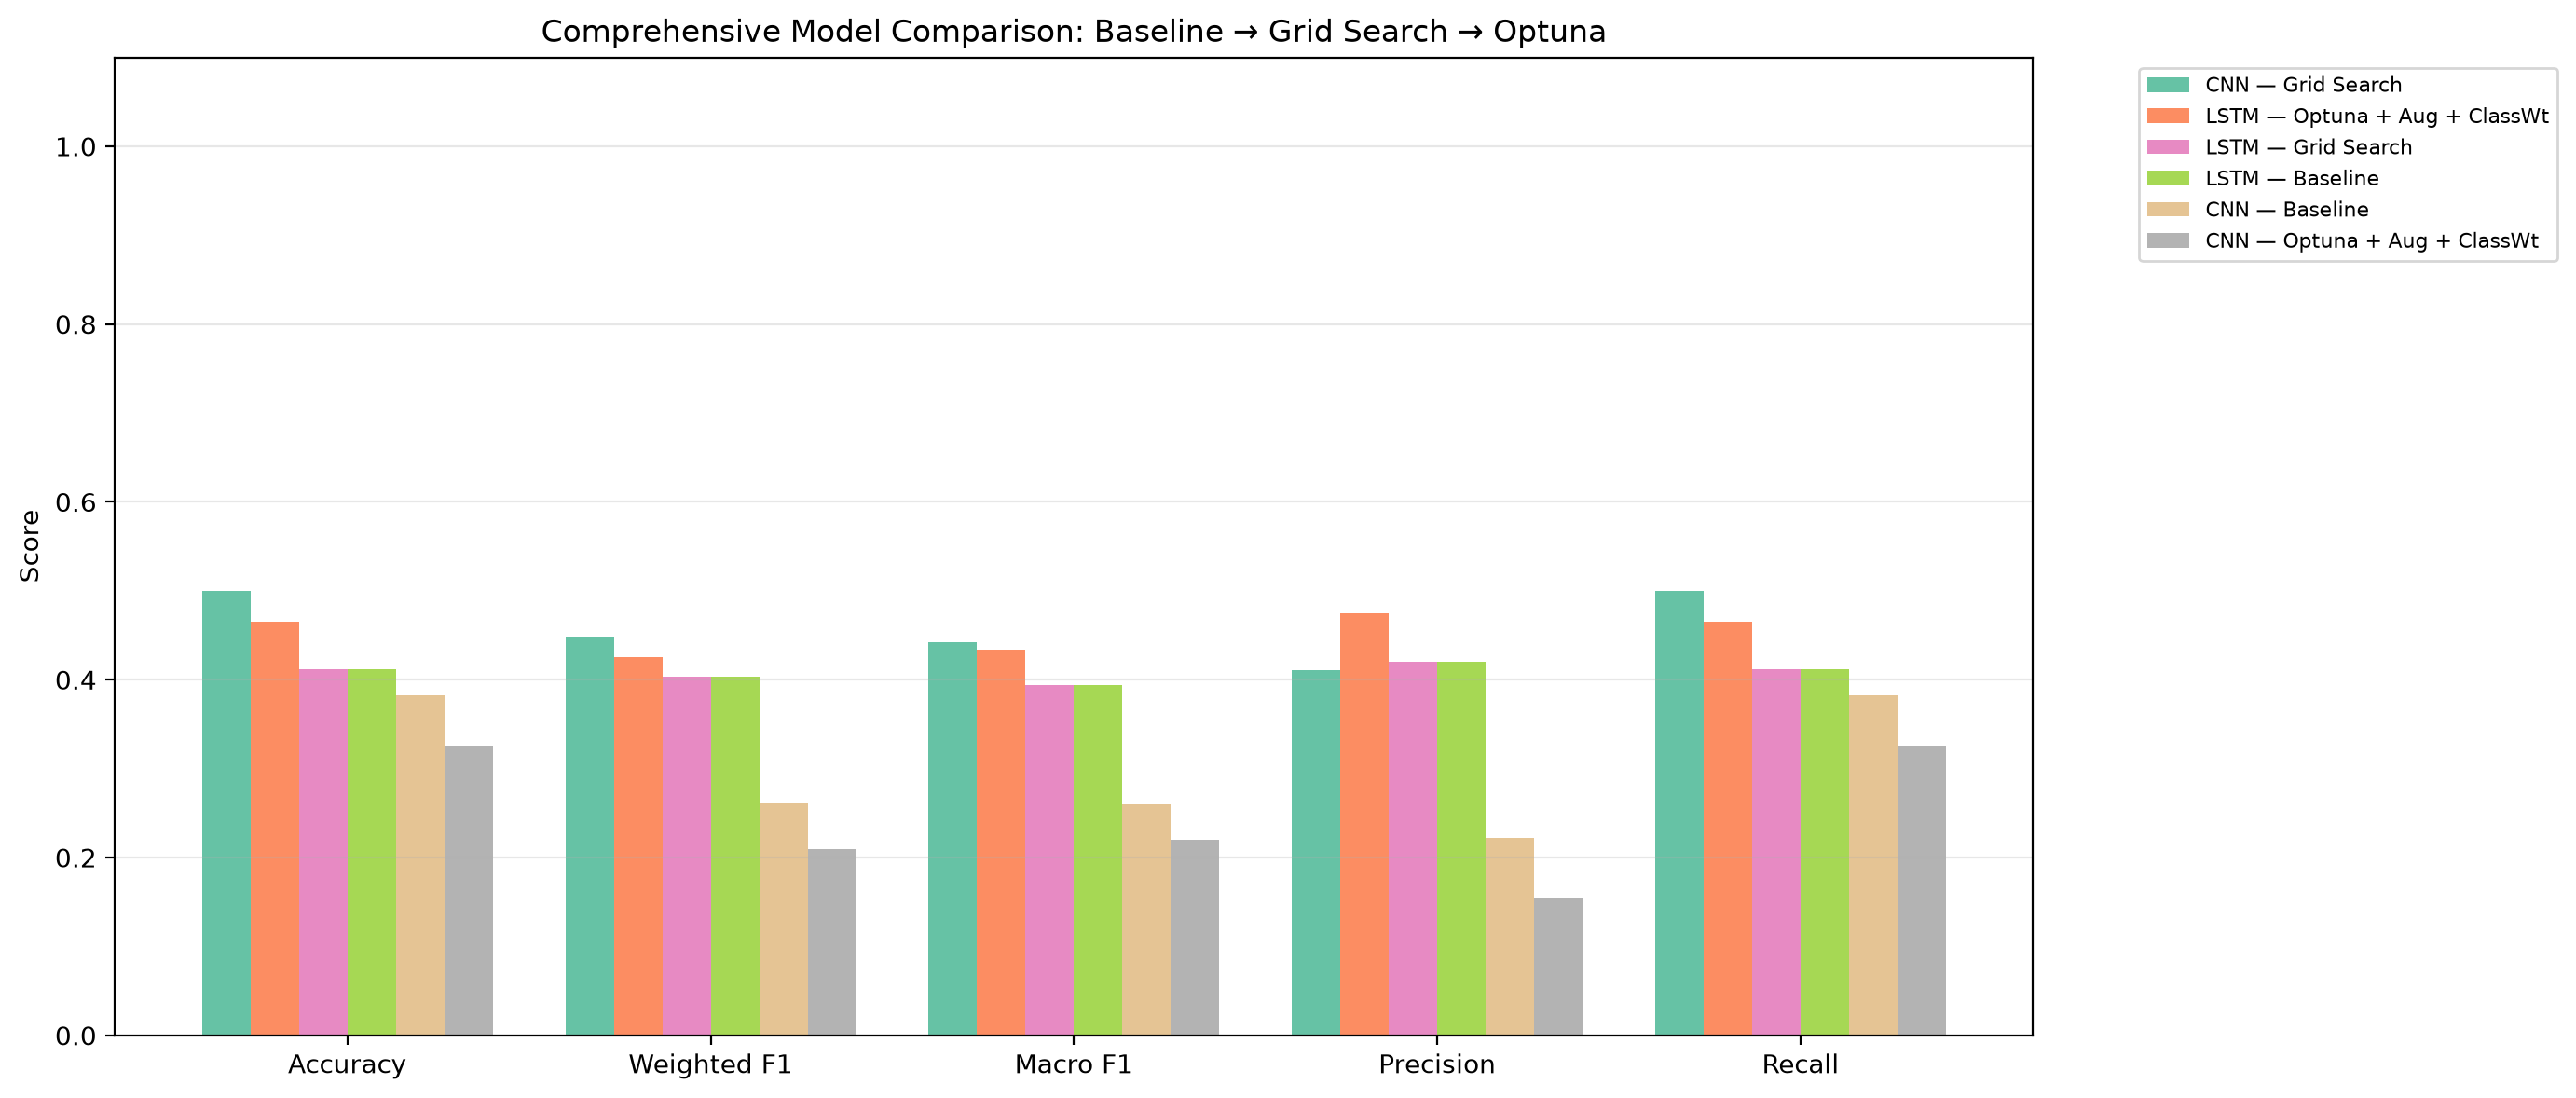


Figure saved to: /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/comprehensive_model_comparison.png


In [37]:
# Visual comparison — grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
metric_cols = ['Accuracy', 'Weighted F1', 'Macro F1', 'Precision', 'Recall']
x = np.arange(len(metric_cols))
n_models = len(comparison_df)
width = 0.8 / n_models
colors = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    offset = width * (i - (n_models - 1) / 2)
    vals = [row[m] for m in metric_cols]
    ax.bar(x + offset, vals, width, label=row['Model'], color=colors[i])

ax.set_ylabel('Score')
ax.set_title('Comprehensive Model Comparison: Baseline → Grid Search → Optuna')
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comprehensive_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to:", FIGURES_DIR / 'comprehensive_model_comparison.png')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step 


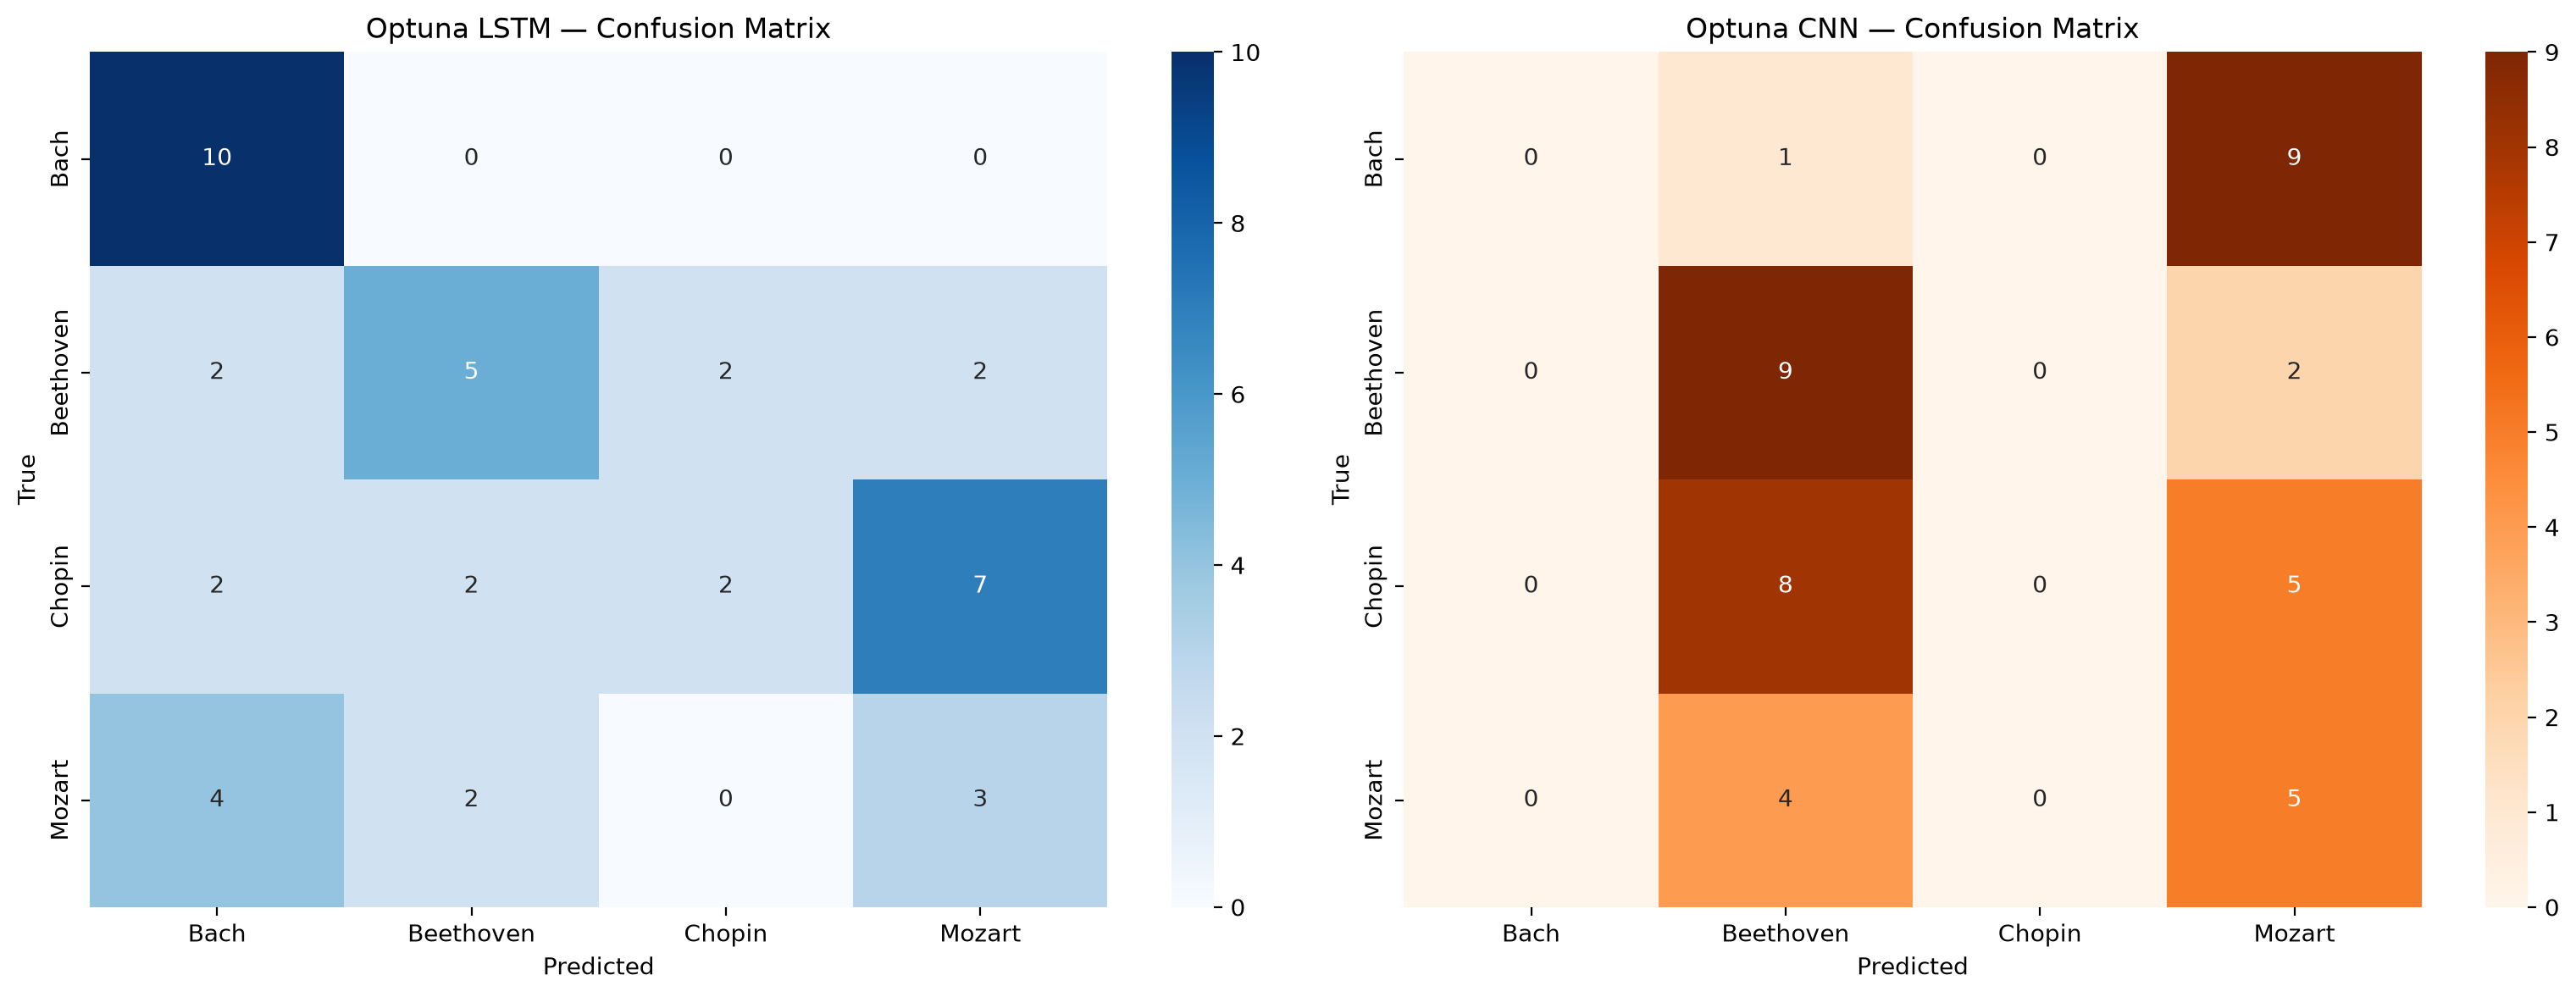


=== Optuna LSTM Classification Report ===
              precision    recall  f1-score   support

        Bach       0.56      1.00      0.71        10
   Beethoven       0.56      0.45      0.50        11
      Chopin       0.50      0.15      0.24        13
      Mozart       0.25      0.33      0.29         9

    accuracy                           0.47        43
   macro avg       0.47      0.49      0.43        43
weighted avg       0.47      0.47      0.42        43


=== Optuna CNN Classification Report ===
              precision    recall  f1-score   support

        Bach       0.00      0.00      0.00        10
   Beethoven       0.41      0.82      0.55        11
      Chopin       0.00      0.00      0.00        13
      Mozart       0.24      0.56      0.33         9

    accuracy                           0.33        43
   macro avg       0.16      0.34      0.22        43
weighted avg       0.15      0.33      0.21        43



In [38]:
# Confusion matrices and ROC curves for Optuna-tuned models
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Optuna LSTM confusion matrix
y_pred_lstm = np.argmax(optuna_lstm_trainer.model.model.predict(X_test_aug_lstm), axis=1)
y_true_lstm = np.argmax(y_test_aug_lstm, axis=1) if y_test_aug_lstm.ndim > 1 else y_test_aug_lstm
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=COMPOSERS, yticklabels=COMPOSERS)
axes[0].set_title('Optuna LSTM — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Optuna CNN confusion matrix
y_pred_cnn = np.argmax(optuna_cnn_trainer.model.model.predict(X_test_aug_cnn), axis=1)
y_true_cnn = np.argmax(y_test_aug_cnn, axis=1) if y_test_aug_cnn.ndim > 1 else y_test_aug_cnn
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=COMPOSERS, yticklabels=COMPOSERS)
axes[1].set_title('Optuna CNN — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'optuna_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification reports
print("\n=== Optuna LSTM Classification Report ===")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=COMPOSERS))
print("\n=== Optuna CNN Classification Report ===")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=COMPOSERS))

# Summary of results
print("=" * 60)
print("COMPOSER CLASSIFICATION PROJECT SUMMARY")
print("=" * 60)

print("\nDataset Information:")
print(f"  Total composers: {NUM_CLASSES}")
print(f"  Composers: {', '.join(COMPOSERS)}")
print(f"  Original training samples: {len(X_train_lstm)}")
print(f"  Augmented training samples: {len(X_train_aug_lstm)} (LSTM) / {len(X_train_aug_cnn)} (CNN)")
print(f"  Validation samples: {len(X_val_aug_lstm)}")
print(f"  Test samples: {len(X_test_aug_lstm)}")

print("\n--- Grid Search Best Hyperparameters ---")
print("LSTM:")
for k, v in best_lstm_hp.items():
    print(f"  {k}: {v}")
print("CNN:")
for k, v in best_cnn_hp.items():
    print(f"  {k}: {v}")

print("\n--- Optuna Best Hyperparameters ---")
print("LSTM:")
for k, v in optuna_best_lstm_params.items():
    print(f"  {k}: {v}")
print("CNN:")
for k, v in optuna_best_cnn_params.items():
    print(f"  {k}: {v}")

print("\n--- Model Performance Comparison ---")
print(f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 57)

# Baseline
if 'baseline_lstm_metrics' in dir():
    print(f"{'LSTM (Baseline)':<35} {_get_acc(baseline_lstm_metrics):>10.4f} {baseline_lstm_metrics.get('macro_f1', 0):>10.4f}")
if 'baseline_cnn_metrics' in dir():
    print(f"{'CNN (Baseline)':<35} {_get_acc(baseline_cnn_metrics):>10.4f} {baseline_cnn_metrics.get('macro_f1', 0):>10.4f}")

# Grid Search
if 'lstm_metrics' in dir():
    print(f"{'LSTM (Grid Search)':<35} {_get_acc(lstm_metrics):>10.4f} {lstm_metrics.get('macro_f1', 0):>10.4f}")
if 'cnn_metrics' in dir():
    print(f"{'CNN (Grid Search)':<35} {_get_acc(cnn_metrics):>10.4f} {cnn_metrics.get('macro_f1', 0):>10.4f}")

# Optuna
print(f"{'LSTM (Optuna+Aug+ClassWt)':<35} {optuna_lstm_metrics.get('test_accuracy', 0):>10.4f} {optuna_lstm_metrics.get('macro_f1', 0):>10.4f}")
print(f"{'CNN (Optuna+Aug+ClassWt)':<35} {optuna_cnn_metrics.get('test_accuracy', 0):>10.4f} {optuna_cnn_metrics.get('macro_f1', 0):>10.4f}")

# Determine best overall
all_results = {
    'LSTM (Optuna+Aug+ClassWt)': optuna_lstm_metrics.get('test_accuracy', 0),
    'CNN (Optuna+Aug+ClassWt)': optuna_cnn_metrics.get('test_accuracy', 0),
}
if 'lstm_metrics' in dir():
    all_results['LSTM (Grid Search)'] = _get_acc(lstm_metrics)
if 'cnn_metrics' in dir():
    all_results['CNN (Grid Search)'] = _get_acc(cnn_metrics)
best_model = max(all_results, key=all_results.get)
print(f"\nBest Overall Model: {best_model} (Accuracy: {all_results[best_model]:.4f})")

print("\n" + "=" * 60)
print("Project completed successfully!")
print("=" * 60)

In [39]:
# Summary of results
print("=" * 60)
print("COMPOSER CLASSIFICATION PROJECT SUMMARY")
print("=" * 60)

print("\nDataset Information:")
print(f"  Total composers: {NUM_CLASSES}")
print(f"  Composers: {', '.join(COMPOSERS)}")
print(f"  Original training samples: {len(X_train_lstm)}")
print(f"  Augmented training samples: {len(X_train_aug_lstm)} (LSTM) / {len(X_train_aug_cnn)} (CNN)")
print(f"  Validation samples: {len(X_val_aug_lstm)}")
print(f"  Test samples: {len(X_test_aug_lstm)}")

print("\n--- Grid Search Best Hyperparameters ---")
print("LSTM:")
for k, v in best_lstm_hp.items():
    print(f"  {k}: {v}")
print("CNN:")
for k, v in best_cnn_hp.items():
    print(f"  {k}: {v}")

print("\n--- Optuna Best Hyperparameters ---")
print("LSTM:")
for k, v in optuna_best_lstm_params.items():
    print(f"  {k}: {v}")
print("CNN:")
for k, v in optuna_best_cnn_params.items():
    print(f"  {k}: {v}")

print("\n--- Model Performance Comparison ---")
print(f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 57)

# Baseline
if 'lstm_metrics' in dir():
    print(f"{'LSTM (Baseline)':<35} {lstm_metrics.get('test_accuracy', 0):>10.4f} {lstm_metrics.get('macro_f1', 0):>10.4f}")
if 'cnn_metrics' in dir():
    print(f"{'CNN (Baseline)':<35} {cnn_metrics.get('test_accuracy', 0):>10.4f} {cnn_metrics.get('macro_f1', 0):>10.4f}")

# Grid Search
if 'tuned_lstm_metrics' in dir():
    print(f"{'LSTM (Grid Search)':<35} {tuned_lstm_metrics.get('test_accuracy', 0):>10.4f} {tuned_lstm_metrics.get('macro_f1', 0):>10.4f}")
if 'tuned_cnn_metrics' in dir():
    print(f"{'CNN (Grid Search)':<35} {tuned_cnn_metrics.get('test_accuracy', 0):>10.4f} {tuned_cnn_metrics.get('macro_f1', 0):>10.4f}")

# Optuna
print(f"{'LSTM (Optuna+Aug+ClassWt)':<35} {optuna_lstm_metrics.get('test_accuracy', 0):>10.4f} {optuna_lstm_metrics.get('macro_f1', 0):>10.4f}")
print(f"{'CNN (Optuna+Aug+ClassWt)':<35} {optuna_cnn_metrics.get('test_accuracy', 0):>10.4f} {optuna_cnn_metrics.get('macro_f1', 0):>10.4f}")

# Determine best overall
all_results = {
    'LSTM (Optuna+Aug+ClassWt)': optuna_lstm_metrics.get('test_accuracy', 0),
    'CNN (Optuna+Aug+ClassWt)': optuna_cnn_metrics.get('test_accuracy', 0),
}
best_model = max(all_results, key=all_results.get)
print(f"\nBest Overall Model: {best_model} (Accuracy: {all_results[best_model]:.4f})")

print("\n" + "=" * 60)
print("Project completed successfully!")
print("=" * 60)

COMPOSER CLASSIFICATION PROJECT SUMMARY

Dataset Information:
  Total composers: 4
  Composers: Bach, Beethoven, Chopin, Mozart
  Original training samples: 268
  Augmented training samples: 678 (LSTM) / 678 (CNN)
  Validation samples: 43
  Test samples: 43

--- Grid Search Best Hyperparameters ---
LSTM:
  hidden_units: 256
  dropout: 0.3
  learning_rate: 0.001
  val_accuracy: 0.5
  val_f1: 0.4795518207282913
CNN:
  filters: [64, 128, 256]
  dropout: 0.5
  learning_rate: 0.001
  val_accuracy: 0.529411792755127
  val_f1: 0.484313725490196

--- Optuna Best Hyperparameters ---
LSTM:
  hidden_units: 256
  dropout: 0.30000000000000004
  learning_rate: 0.0007450510194106596
  batch_size: 16
CNN:
  n_conv_layers: 2
  base_filters: 32
  dropout: 0.5
  learning_rate: 0.003882779580407145
  dense_units: 512
  batch_size: 32

--- Model Performance Comparison ---
Model                                 Accuracy   Macro F1
---------------------------------------------------------
LSTM (Baseline)     

In [ ]:
# # Summary of results
# print("=" * 60)
# print("COMPOSER CLASSIFICATION PROJECT SUMMARY")
# print("=" * 60)

# print("\nDataset Information:")
# print(f"  Total composers: {NUM_CLASSES}")
# print(f"  Composers: {', '.join(COMPOSERS)}")
# print(f"  Original training samples: {len(X_train_lstm)}")
# print(f"  Augmented training samples: {len(X_train_aug_lstm)} (LSTM) / {len(X_train_aug_cnn)} (CNN)")
# print(f"  Validation samples: {len(X_val_aug_lstm)}")
# print(f"  Test samples: {len(X_test_aug_lstm)}")

# print("\n--- Grid Search Best Hyperparameters ---")
# print("LSTM:")
# for k, v in best_lstm_hp.items():
#     print(f"  {k}: {v}")
# print("CNN:")
# for k, v in best_cnn_hp.items():
#     print(f"  {k}: {v}")

# print("\n--- Optuna Best Hyperparameters ---")
# print("LSTM:")
# for k, v in optuna_best_lstm_params.items():
#     print(f"  {k}: {v}")
# print("CNN:")
# for k, v in optuna_best_cnn_params.items():
#     print(f"  {k}: {v}")

# print("\n--- Model Performance Comparison ---")
# print(f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10}")
# print("-" * 57)

# # Baseline
# if 'baseline_lstm_metrics' in dir():
#     print(f"{'LSTM (Baseline)':<35} {_get_acc(baseline_lstm_metrics):>10.4f} {baseline_lstm_metrics.get('macro_f1', 0):>10.4f}")
# if 'baseline_cnn_metrics' in dir():
#     print(f"{'CNN (Baseline)':<35} {_get_acc(baseline_cnn_metrics):>10.4f} {baseline_cnn_metrics.get('macro_f1', 0):>10.4f}")

# # Grid Search
# if 'lstm_metrics' in dir():
#     print(f"{'LSTM (Grid Search)':<35} {_get_acc(lstm_metrics):>10.4f} {lstm_metrics.get('macro_f1', 0):>10.4f}")
# if 'cnn_metrics' in dir():
#     print(f"{'CNN (Grid Search)':<35} {_get_acc(cnn_metrics):>10.4f} {cnn_metrics.get('macro_f1', 0):>10.4f}")

# # Optuna
# print(f"{'LSTM (Optuna+Aug+ClassWt)':<35} {optuna_lstm_metrics.get('test_accuracy', 0):>10.4f} {optuna_lstm_metrics.get('macro_f1', 0):>10.4f}")
# print(f"{'CNN (Optuna+Aug+ClassWt)':<35} {optuna_cnn_metrics.get('test_accuracy', 0):>10.4f} {optuna_cnn_metrics.get('macro_f1', 0):>10.4f}")

# # Determine best overall
# all_results = {
#     'LSTM (Optuna+Aug+ClassWt)': optuna_lstm_metrics.get('test_accuracy', 0),
#     'CNN (Optuna+Aug+ClassWt)': optuna_cnn_metrics.get('test_accuracy', 0),
# }
# if 'lstm_metrics' in dir():
#     all_results['LSTM (Grid Search)'] = _get_acc(lstm_metrics)
# if 'cnn_metrics' in dir():
#     all_results['CNN (Grid Search)'] = _get_acc(cnn_metrics)
# best_model = max(all_results, key=all_results.get)
# print(f"\nBest Overall Model: {best_model} (Accuracy: {all_results[best_model]:.4f})")

# print("\n" + "=" * 60)
# print("Project completed successfully!")
# print("=" * 60)

COMPOSER CLASSIFICATION PROJECT SUMMARY

Dataset Information:
  Total composers: 4
  Composers: Bach, Beethoven, Chopin, Mozart
  Original training samples: 268
  Augmented training samples: 678 (LSTM) / 678 (CNN)
  Validation samples: 43
  Test samples: 43

--- Grid Search Best Hyperparameters ---
LSTM:
  hidden_units: 256
  dropout: 0.3
  learning_rate: 0.001
  val_accuracy: 0.5
  val_f1: 0.4795518207282913
CNN:
  filters: [64, 128, 256]
  dropout: 0.5
  learning_rate: 0.001
  val_accuracy: 0.529411792755127
  val_f1: 0.484313725490196

--- Optuna Best Hyperparameters ---
LSTM:
  hidden_units: 256
  dropout: 0.30000000000000004
  learning_rate: 0.0007450510194106596
  batch_size: 16
CNN:
  n_conv_layers: 2
  base_filters: 32
  dropout: 0.5
  learning_rate: 0.003882779580407145
  dense_units: 512
  batch_size: 32

--- Model Performance Comparison ---
Model                                 Accuracy   Macro F1
---------------------------------------------------------
LSTM (Baseline)     

## Key Findings

1. **Dataset**: Successfully loaded and processed MIDI files from 4 classical composers (Bach, Beethoven, Chopin, Mozart)
2. **Preprocessing**: Applied data cleaning, augmentation (pitch shift, tempo scaling, velocity variation), and stratified splitting
3. **Feature Extraction**: Implemented note-level features (pitch, velocity, duration) for LSTM and piano roll representations for CNN
4. **Baseline Models**: Trained initial LSTM and CNN models with default hyperparameters
5. **Grid Search Tuning**: Systematically searched over hidden units, dropout, and learning rate
6. **Optuna Tuning**: Bayesian optimization with MedianPruner, combined with data augmentation and class weighting, provided the most comprehensive hyperparameter search
7. **Data Augmentation**: Expanding the training set at the MIDI level helped models generalize better
8. **Class Weights**: Using `compute_class_weight('balanced')` preserved all training data instead of undersampling

## Future Improvements

- Implement transformer-based sequence models (e.g., Music Transformer)
- Add bidirectional LSTM with attention mechanisms
- Experiment with spectrogram-based representations (Mel spectrograms)
- Use ensemble methods combining LSTM and CNN predictions
- Increase dataset size with additional composers or MIDI sources
- Deploy as a web application for real-time classification